<a href="https://colab.research.google.com/github/miffylim2308/ADALL_github/blob/main/Project/Grabi_Booking_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color='red'>**dated 14.08.2026 11pm**

#**Chapter 1. Setup and load Libraries**

In [1]:
# ============================================================
# 1. CORE LIBRARIES
# ============================================================
import os
import shutil
import platform
import joblib

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import sklearn

# ============================================================
# 2. MODEL SELECTION / VALIDATION
# ============================================================
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)
# ============================================================
# 3. CLASSIFICATION METRICS
# ============================================================
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    PrecisionRecallDisplay
)

# ============================================================
# 4. PREPROCESSING
# ============================================================
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

# ============================================================
# 5. CLASSIFICATION MODELS
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ============================================================
# 6. HYPERPARAMETER DISTRIBUTIONS
# ============================================================
from scipy.stats import loguniform, randint, uniform

!pip install -q shap
import shap

RANDOM_STATE = 42

print('Setup complete')

Setup complete


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

#**Chapter 2. Upload and Read Dataset**

In [2]:
import pandas as pd
# Example: Replace this with the raw URL of your GitHub fileynth
github_raw_url = 'https://raw.githubusercontent.com/miffylim2308/ADALL_github/refs/heads/main/Project/grabi_transport.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("Successfully loaded data from GitHub!")
    display(df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")


Successfully loaded data from GitHub!


,booking_id,booking_datetime,booking_hour,day_of_week,month,is_weekend,is_peak_hour,is_late_night,public_holiday,pickup_zone,...,traffic_level,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,app_version,network_quality,customer_cancelled,cancel_reason
0,BK2026007041,6/3/2026 0:10,0,Friday,3,0,0,1,0,Queenstown,...,Medium,1.10,0,0,0,11.66,Current,Good,0,Not Cancelled
1,BK2026017909,11/6/2026 9:31,9,Thursday,6,0,1,0,0,CBD,...,Severe,1.15,0,1,10,6.64,One version behind,Good,0,Not Cancelled
2,BK2026010896,9/4/2026 9:42,9,Thursday,4,0,1,0,0,Sentosa,...,Low,1.49,0,0,0,40.07,Current,Poor,1,Changed plans/weather
3,BK2026003508,1/2/2026 23:47,23,Sunday,2,1,0,1,0,CBD,...,Low,1.00,0,1,3,21.48,Current,Good,0,Not Cancelled
4,BK2026013146,29/4/2026 12:57,12,Wednesday,4,0,0,0,0,Jurong East,...,Medium,1.00,0,0,0,7.12,Current,Good,0,Not Cancelled


#**Chapter 3. Set up OpenAI**

In [3]:
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

# Only use this section if your tutor has asked you to call the API from Colab.
# You must first save OPENAI_API_KEY in Colab Secrets.

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

OpenAI client is ready.


#**<font color='red'>Chapter 4A. (PPT) Prompt to create the first draft for "Introduction & Context"**

In [ ]:
# PPT-1a
prompt_intro= f"""
[Role]
You are a Data Scientist and IT Data Analyst specialise in regression and classification modelling.

[Context]
Grabi Transport has recently faced a rise in pre-trip customer cancellations.
Customers book rides but customer cancel before the trip begins.
This ongoing issue has led to dissatisfaction among customers and drivers, affecting booking completion rates, satisfaction KPIs, and overall business performance.
To tackle the challenge, the Ride Operations Manager has engaged Annie Lim, the Data & AI Manager,
to explore building a predictive model within the booking system to help reduce customer cancellations.

[Task]
Please draft the following.
1. Business Problem.
Describe the business problem you aim to address. Explain why it matters and who is affected.
2. Identify the key beneficiary of the ML solution.
Create a simple persona that captures details important for this project, such as the person’s goals, pain points, behaviours and how they would use the solution.
3. Use the Job-To-Be-Done (JTBD) framework to shape your modelling objectives.
State the job the user is trying to complete, and define the target variable and likely predictors based on this job.

[Output Format]
Responds in paragraph form, using clear line breaks. Insert a blank line between key ideas to improve readability.
Or reach subject, keep it to 3 lines the maximum

[Constraints]
Keep response concise and actionable.
Limit each section to a maximum of 3 lines
Start each sentence in a new line.
"""
print('===== Prompt to AI =====')
print(prompt_intro)

response_intro = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_intro
)
print('===== AI response=====')
print(response_intro.output_text)


===== Prompt to AI =====

[Role]
You are a Data Scientist and IT Data Analyst specialise in regression and classification modelling.

[Context]
Grabi Transport has recently faced a rise in pre-trip customer cancellations. 
Customers book rides but customer cancel before the trip begins. 
This ongoing issue has led to dissatisfaction among customers and drivers, affecting booking completion rates, satisfaction KPIs, and overall business performance.
To tackle the challenge, the Ride Operations Manager has engaged Annie Lim, the Data & AI Manager, 
to explore building a predictive model within the booking system to help reduce customer cancellations.

[Task]
Please draft the following.
1. Business Problem. 
Describe the business problem you aim to address. Explain why it matters and who is affected.
2. Identify the key beneficiary of the ML solution. 
Create a simple persona that captures details important for this project, such as the person’s goals, pain points, behaviours and how they

#**<font color='red'>Chapter 4B. (PPT) Prompt to create more refined output for "Introduction & Context"**

In [ ]:
# PPT-1a refined
data_preview = df.head()

prompt_intro_refined = f"""

=========================
ROLE
=========================
You are a senior Data Scientist and Business Analytics Consultant with expertise in business analytics, machine learning, and binary classification modelling.
Your task is to bridge business and data science by translating a business problem into a clear machine learning problem while focusing on practical business value.
Respond as if preparing the Business Understanding section of a machine learning proposal for business stakeholders.

=========================
BUSINESS CONTEXT
=========================
Grabi Transport has experienced a rise in pre-trip customer cancellations, increasing from 18% to 23% over the last quarter.
A pre-trip customer cancellation occurs when:
- A customer successfully books a ride.
- A driver accepts the booking.
- The customer cancels before the trip begins.

This increase has negatively affected:
- Booking completion rate
- Customer satisfaction
- Driver satisfaction
- Operational efficiency
- Business performance and operational KPIs

The Land Transport Authority (LTA) regulates ride-hailing Quality of Service (QoS) in Singapore.
Current requirements include:
- Passenger wait time within 10 minutes for at least 65% of peak-hour bookings.
- Successful dispatch for at least 70% of booking requests.
Although LTA does not specify an official cancellation-rate threshold, operators are expected to minimise unnecessary customer cancellations while maintaining service quality.

To address this challenge, the Ride Operations Manager collaborates with the Pricing Team, Driver Operations Team, Customer Service Team, Marketing Team, and Engineering Team.
The Ride Operations Manager has sought support from Annie Lim, the Data & AI Manager, to develop a machine learning solution that predicts the probability that a confirmed booking will be cancelled before trip commencement.

The prediction will be generated shortly after booking confirmation so that operational teams have sufficient time to intervene before the trip begins.
The objective is to enable timely, targeted, and cost-effective interventions that reduce cancellations without unnecessarily increasing operational costs.

=========================
BUSINESS OBJECTIVE
=========================
Business Problem
- Pre-trip customer cancellations have increased significantly, reducing booking completion rates and negatively affecting customer experience, driver satisfaction, operational efficiency, and overall business performance.
Business Objective
- Develop a machine learning model that predicts the probability of customer cancellation before trip commencement.
Business Goal
- Reduce customer cancellations by enabling proactive, targeted, and cost-effective operational interventions for bookings with the highest cancellation risk.

=========================
DATASET
=========================
Dataset preview:
{data_preview}
Assume each row represents one confirmed booking.
=========================
TASK
=========================
Prepare the following sections.

--------------------------------------------------
1. Business Problem
--------------------------------------------------
Describe:
- The business problem.
- Why it matters.
- Who is affected.
- Why solving it creates business value.
- How predictive analytics can improve operational decision-making.

--------------------------------------------------
2. Key Beneficiary (User Persona)
--------------------------------------------------
The primary beneficiary is the Ride Operations Manager.
Create a realistic business persona that explains how this person will use the ML solution in their daily work.

Include:
Role
- Job responsibilities.
- Operational responsibilities.

Goals
- Business KPIs they are accountable for.
- Operational outcomes they want to improve.

Pain Points
- Information they currently lack.
- Why current decision making is reactive.
- Why it is difficult to identify bookings that require intervention.
- Operational trade-offs they face between reducing cancellations and controlling intervention costs.

Decisions They Make
Explain the decisions they make, including:
- Which bookings should receive intervention.
- Which bookings should not receive intervention.
- When intervention should occur.
- Which operational action is most appropriate.
- How limited operational resources should be prioritised.
- How to balance false positives (unnecessary intervention costs) against false negatives (missed cancellations).

How They Will Use the ML Prediction
Describe how the prediction integrates naturally into their workflow.
Explain:
- At which stage of the booking lifecycle they receive the prediction.
- Whether they review bookings individually or through a prioritised dashboard.
- How risk scores help prioritise operational attention.
- How prediction confidence influences operational decisions.
- How the model supports faster, more consistent, and data-driven decision making.

ML Decision Support Requirements
Describe the outputs that would be most useful.
Examples include:
- Cancellation probability (0–100%)
- Risk category (Low / Medium / High)
- Prioritised list of high-risk bookings
- Confidence score
- Top contributing risk factors
- Brief explanation of why the booking is considered high risk
- Recommended operational action (where appropriate)

Only include outputs that are supported by the business context or clearly identified as reasonable assumptions.

--------------------------------------------------
3. Job-To-Be-Done (JTBD)
--------------------------------------------------
Use the JTBD framework.
Include:
Job Statement
Use the format:
"When I am..., I want to..., so I can..."

Then explain:
- The operational decision being made.
- What information the ML prediction provides.
- What action becomes possible because of the prediction.

Target Variable
Describe:
- Target variable.
- What it represents.
- Why predicting it creates business value.

Likely Predictor Variables
Identify major categories of predictors likely to influence customer cancellation.
Examples include:
- Customer behaviour
- Booking characteristics
- Driver availability
- Pricing
- Traffic
- Weather
- Time-related features

Only discuss categories that are supported by the provided context or dataset preview.

Operational Intervention
Explain how prediction results could support different business teams.
Examples include:
Ride Operations
Pricing
Driver Operations
Marketing
Customer Service
Engineering

Focus on how prediction enables timely, targeted interventions rather than blanket actions.

=========================
OUTPUT FORMAT
=========================
Use the following headings exactly.

1. Business Problem

2. Key Beneficiary (User Persona)

3. Job-To-Be-Done (JTBD)
   - Job Statement
   - Target Variable
   - Likely Predictor Variables
   - Operational Intervention
=========================
CONSTRAINTS
=========================

- Respond in paragraph form.
- Start every sentence on a new line.
- Leave one blank line between major sections.
- Limit each main section to a maximum of five sentences.
- Use concise, professional business language suitable for senior management.
- Focus on business decisions rather than technical implementation.
- Explain practical business value instead of generic statements.
- Ensure the persona's goals, pain points, decisions, ML outputs, and interventions are logically connected.
- Avoid inventing departments, workflows, business processes, or dataset features that are not supported by the provided context.
- If assumptions are required, explicitly state them as assumptions.

"""

print('===== Prompt to AI =====')
print(prompt_intro_refined)

response_intro_refined = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_intro_refined
)
print('===== AI response=====')
print(response_intro_refined.output_text)



===== Prompt to AI =====

ROLE
You are a senior Data Scientist and Data Analytics consultant with expertise in business analytics, machine learning, and binary classification modelling.

BUSINESS CONTEXT
Grabi Transport has recently experienced a rise in pre-trip customer cancellations. The cancellation rate has increased from 18% to 23% over the last quarter.
The Land Transport Authority (LTA) sets strict Quality of Service (QoS) standards for ride-hailing in Singapore: 
passenger wait times must be within 10 minutes for at least 65% of bookings during peak hours, and dispatch systems must successfully cater at least 70% of calls. 
Operators that fail these standards face financial penalties. While LTA does not publish a fixed “cancellation rate threshold,” operators are expected to keep cancellations low.

A pre-trip customer cancellation occurs when:
- A customer successfully books a ride.
- A driver accepts the booking, confirming the ride.
- The customer cancels the booking before

#**Chapter 5A. Quick Dataset Inspection**

In [4]:
print('Dataset Shape (rows, columns):', df.shape)

display(df.head())

print('\nInfo:')
display(df.info())

print('\nColumns:', df.columns.tolist())

print("\nDescribe:")
display(df.describe(include='all').transpose())

missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

duplicate_count = df.duplicated().sum()
print("\nDuplicate count:", duplicate_count)

Dataset Shape (rows, columns): (10000, 49)


,booking_id,booking_datetime,booking_hour,day_of_week,month,is_weekend,is_peak_hour,is_late_night,public_holiday,pickup_zone,...,traffic_level,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,app_version,network_quality,customer_cancelled,cancel_reason
0,BK2026007041,6/3/2026 0:10,0,Friday,3,0,0,1,0,Queenstown,...,Medium,1.10,0,0,0,11.66,Current,Good,0,Not Cancelled
1,BK2026017909,11/6/2026 9:31,9,Thursday,6,0,1,0,0,CBD,...,Severe,1.15,0,1,10,6.64,One version behind,Good,0,Not Cancelled
2,BK2026010896,9/4/2026 9:42,9,Thursday,4,0,1,0,0,Sentosa,...,Low,1.49,0,0,0,40.07,Current,Poor,1,Changed plans/weather
3,BK2026003508,1/2/2026 23:47,23,Sunday,2,1,0,1,0,CBD,...,Low,1.00,0,1,3,21.48,Current,Good,0,Not Cancelled
4,BK2026013146,29/4/2026 12:57,12,Wednesday,4,0,0,0,0,Jurong East,...,Medium,1.00,0,0,0,7.12,Current,Good,0,Not Cancelled



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 49 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   booking_id                       10000 non-null  object 
 1   booking_datetime                 10000 non-null  object 
 2   booking_hour                     10000 non-null  int64  
 3   day_of_week                      10000 non-null  object 
 4   month                            10000 non-null  int64  
 5   is_weekend                       10000 non-null  int64  
 6   is_peak_hour                     10000 non-null  int64  
 7   is_late_night                    10000 non-null  int64  
 8   public_holiday                   10000 non-null  int64  
 9   pickup_zone                      10000 non-null  object 
 10  pickup_zone_type                 10000 non-null  object 
 11  dropoff_zone                     10000 non-null  object 
 12  dropoff_zone

None


Columns: ['booking_id', 'booking_datetime', 'booking_hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night', 'public_holiday', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone', 'dropoff_zone_type', 'airport_trip', 'cbd_trip', 'distance_km', 'estimated_trip_duration_min', 'vehicle_type', 'payment_method', 'customer_segment', 'loyalty_tier', 'customer_tenure_days', 'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d', 'previous_customer_cancellations', 'avg_previous_wait_time_min', 'customer_rating', 'driver_rating', 'active_driver_supply_zone', 'booking_demand_zone', 'supply_demand_ratio', 'nearby_driver_count', 'drivers_declined_before_accept', 'driver_acceptance_time_sec', 'driver_distance_to_pickup_km', 'driver_eta_min', 'weather', 'is_raining', 'traffic_level', 'surge_multiplier', 'surge_changed_after_booking', 'promo_applied', 'promo_discount_sgd', 'estimated_fare_sgd', 'app_version', 'network_quality', 'customer_cancelled', 'cancel_reason']

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,10000,10000,BK2026003811,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_datetime,10000,9796,28/6/2026 14:54,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_hour,10000.0,NaN,NaN,NaN,11.7025,6.839303,0.0,6.0,12.0,18.0,23.0
day_of_week,10000,7,Thursday,1475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,10000.0,NaN,NaN,NaN,3.4967,1.70114,1.0,2.0,4.0,5.0,6.0
is_weekend,10000.0,NaN,NaN,NaN,0.2831,0.450527,0.0,0.0,0.0,1.0,1.0
is_peak_hour,10000.0,NaN,NaN,NaN,0.3021,0.459191,0.0,0.0,0.0,1.0,1.0
is_late_night,10000.0,NaN,NaN,NaN,0.2744,0.446234,0.0,0.0,0.0,1.0,1.0
public_holiday,10000.0,NaN,NaN,NaN,0.0324,0.177069,0.0,0.0,0.0,0.0,1.0
pickup_zone,10000,15,CBD,918,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values:
 booking_id                            0
booking_datetime                      0
booking_hour                          0
day_of_week                           0
month                                 0
is_weekend                            0
is_peak_hour                          0
is_late_night                         0
public_holiday                        0
pickup_zone                           0
pickup_zone_type                      0
dropoff_zone                          0
dropoff_zone_type                     0
airport_trip                          0
cbd_trip                              0
distance_km                           0
estimated_trip_duration_min           0
vehicle_type                          0
payment_method                        0
customer_segment                      0
loyalty_tier                       3268
customer_tenure_days                  0
rides_last_7_days                     0
rides_last_30_days                    0
customer_cancel_rate_90

#**Chapter 5B. Prompt LLM for Problem Framing**

In [ ]:
# PROMPT - LLM-assisted problem framing

prompt_framing = f"""
You are an experienced data scientist specialising in machine learning for business problems.
Your task is to translate the following business problem into a machine learning modelling objective.
=======================
DATASET PREVIEW
=======================
{df.head()}

=========================
BUSINESS CONTEXT
=========================
Business Problem:
Grab Ride Operations Manager has observed a high rate of customer cancellations before the trip commencement over the past few months.

Business Objective:
Develop a machine learning model to predict the probability that a customer will cancel a ride before trip commencement.

Business Goal:
Reduce the customer pre-trip cancellation rate by enabling proactive operational interventions.

Dataset Context:
The dataset contains Grab ride-hailing booking data.
Each row represents one booking made by a customer. Around 23% of the dataset are records that customers cancelled before the trip commencement.
The dataset includes customer information, booking details, driver availability, pricing, weather, traffic conditions, and booking outcomes.

=========================
TASK
=========================
Answer the following questions:
1. What should the machine learning modelling objective be?
2. Which column should be used as the target variable? Explain why.
3. Which evaluation model(s) and metric(s) would you recommend for this prediction problem? Explain why these metrics would be meaningful and easy for business stakeholders to understand.
4. Who are the main business stakeholders that would use the model?
5. Identify three potential risks or pitfalls when developing or deploying this model.

=========================
IMPORTANT
=========================
Use ONLY the information provided in the business context and dataset profile.
Do NOT invent columns, business processes or stakeholders that are not supported by the information provided.
If an answer requires assumptions, clearly label them as "Assumption".
If information is not available, state the assumptions you are making.
Present your answers using clear headings and concise explanations suitable for a university report.
"""
print('=== Prompt to send ===')
print(prompt_framing[:2000])

response_framing = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_framing
)
print('\n=== LLM response ===')
print(response_framing.output_text)



=== Prompt to send ===

You are an experienced data scientist specialising in machine learning for business problems.
Your task is to translate the following business problem into a machine learning modelling objective.
DATASET PREVIEW
     booking_id booking_datetime  booking_hour day_of_week  month  is_weekend  \
0  BK2026007041    6/3/2026 0:10             0      Friday      3           0   
1  BK2026017909   11/6/2026 9:31             9    Thursday      6           0   
2  BK2026010896    9/4/2026 9:42             9    Thursday      4           0   
3  BK2026003508   1/2/2026 23:47            23      Sunday      2           1   
4  BK2026013146  29/4/2026 12:57            12   Wednesday      4           0   

   is_peak_hour  is_late_night  public_holiday  pickup_zone  ...  \
0             0              1               0   Queenstown  ...   
1             1              0               0          CBD  ...   
2             1              0               0      Sentosa  ...   
3    

#**Chapter 6A. Build Payload Text**

In [ ]:
#===== Chapter 5. Build Payload Text =====#

payload_text = ''

# 0. Business context and objective
payload_text += '=== BUSINESS OBJECTIVE ===\n'
payload_text += 'Dataset context: The dataset contains ride-hailing booking data. Each row represents one booking made by a customer.\n'
payload_text += 'The dataset includes customer information, booking details, driver availability, weather, traffic conditions, and booking outcomes.\n'
payload_text += 'Business Goal: Develop a machine learning model to predict the probability that a customer will cancel a ride before trip commencement.\n'
payload_text += 'Utimately to reduce the customer pre-trip cancellation rate by enabling proactive operational interventions.\n'
payload_text += 'Intended Users: Grab Ride Operations Manager whose one of his goal is to reduce the customer pre-trip cancellation rate.\n'
payload_text += 'Questions:\n'
payload_text += '- Which features influence customer cancellation?\n'
payload_text += '- What data quality issues exist?\n'
payload_text += '- What preprocessing is required?\n\n'

# 1. Shape
payload_text += '=== SHAPE ===\n'
payload_text += 'Rows: ' + str(df.shape[0]) + '\n'
payload_text += 'Columns: ' + str(df.shape[1]) + '\n\n'

# 2. Sample records
payload_text += '=== SAMPLE RECORDS ===\n'
payload_text += df.head(5).to_string(index=False)
payload_text += '\n\n'

# 3. Column names and data types
payload_text += '=== COLUMNS AND DATA TYPES ===\n'
payload_text += df.dtypes.to_string()
payload_text += '\n\n'

# 4. Numeric summary
payload_text += '=== NUMERIC SUMMARY ===\n'
numeric_summary = df.describe(include='number').round(2)
payload_text += numeric_summary.to_string()
payload_text += '\n\n'

# 5. Null summary
payload_text += "=== NULL SUMMARY ===\n"
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
payload_text += null_summary.to_string()
payload_text += '\n\n'

# 6. Missing values
payload_text += '=== MISSING VALUES ===\n'
missing_table = pd.DataFrame()
missing_table['missing_count'] = df.isna().sum()
missing_table['missing_pct'] = (df.isna().sum() / len(df) * 100).round(2)
payload_text += missing_table.to_string()
payload_text += '\n\n'

# 7. Unique values per column
payload_text += '=== UNIQUE VALUES PER COLUMN ===\n'
unique_table = pd.DataFrame()
unique_table['unique_count'] = df.nunique(dropna=False)
payload_text += unique_table.to_string()
payload_text += '\n\n'

# 8 Correlation between numeric columns
payload_text += '=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n'
correlation_table = df.corr(numeric_only=True).round(2)
payload_text += correlation_table.to_string()
payload_text += '\n\n'

# 9. Top 10 values for categorical columns
payload_text += '=== TOP 10 VALUES FOR CATEGORICAL COLUMNS ===\n'

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_columns) == 0:
    payload_text += 'No categorical columns found.\n'
else:
    for col in categorical_columns:
        payload_text += '\nColumn: ' + col + '\n'
        payload_text += df[col].value_counts(dropna=False).head(10).to_string()
        payload_text += '\n'

payload_text += '\n'

# 10. Skewness of numeric columns
payload_text += '=== SKEWNESS OF NUMERIC COLUMNS ===\n'
skew_table = df.select_dtypes(include='number').skew().round(2)
payload_text += skew_table.to_string()
payload_text += '\n\n'

# 11. Outlier summary
payload_text += '=== OUTLIER SUMMARY (IQR METHOD) ===\n'

numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_pct = round(outlier_count / len(df) * 100, 2)

    payload_text += f'{column}: {outlier_count} ({outlier_pct}%)\n'

payload_text += '\n'

# 12. Leakage scan: columns with all unique values
payload_text += "=== POSSIBLE LEAKAGE COLUMNS (UNIQUE FOR EACH ROW) ===\n"
leak_cols = df.columns[df.nunique() == len(df)]
payload_text +=str(list(leak_cols))
payload_text +="\n\n"

# 13. Simple warning checks
payload_text += '=== SIMPLE WARNING CHECKS ===\n'

id_like_columns = []
constant_columns = []

for col in df.columns:
    unique_count = df[col].nunique(dropna=False)

    if unique_count == len(df):
        id_like_columns.append(col)

    if unique_count <= 1:
        constant_columns.append(col)
payload_text += 'Possible ID-like columns: ' + str(id_like_columns) + '\n'
payload_text += 'Constant columns: ' + str(constant_columns) + '\n'
duplicate_count = df.duplicated().sum()
duplicate_pct = round(duplicate_count / len(df) * 100, 2)
payload_text += (
    f'Duplicate rows: {duplicate_count} ({duplicate_pct}%)\n'
)

print(payload_text)



=== BUSINESS OBJECTIVE ===
Dataset context: The dataset contains ride-hailing booking data. Each row represents one booking made by a customer.
The dataset includes customer information, booking details, driver availability, weather, traffic conditions, and booking outcomes.
Business Goal: Develop a machine learning model to predict the probability that a customer will cancel a ride before trip commencement.
Utimately to reduce the customer pre-trip cancellation rate by enabling proactive operational interventions.
Intended Users: Grab Ride Operations Manager whose one of his goal is to reduce the customer pre-trip cancellation rate.
Questions:
- Which features influence customer cancellation?
- What data quality issues exist?
- What preprocessing is required?

=== SHAPE ===
Rows: 10000
Columns: 43

=== SAMPLE RECORDS ===
 booking_hour day_of_week  month  is_weekend  is_peak_hour  is_late_night  public_holiday pickup_zone dropoff_zone  airport_trip  cbd_trip  distance_km  estimated_tri

#**Chapter 6B. Prompt LLM to review Data Quality using Payload Text**

In [ ]:
#===== Chapter 6. Quality Assessment =====#

prompt_quality = f"""
You are an expert data scientist with extensive knowledge of tree-based models.
Always justify recommendations using reasoning trace based ONLY on the dataset profile.
============================
DATASET PROFILE
============================
{payload_text}

============================
TASK
============================
Assess the dataset's quality and modelling readiness.

1. Identify all confirmed data quality or modelling-readiness issues.

For each issue, provide:
- Issue
- Column(s) affected
- Evidence from the dataset profile
- Why it may affect analysis or modelling
- Recommended action
- Priority (High / Medium / Low)

2. Identify any potential issues that require further investigation but cannot be confirmed from the dataset profile alone.
3. Identify any features which are higly correlated with other features.
4. Highlight the strengths of the dataset (for example, no missing values, no duplicates, appropriate data types, etc.).

5. State whether the dataset is ready for machine learning modelling using ONE of the following ratings:
- Ready
- Ready with Minor Cleaning
- Ready with Moderate Cleaning
- Not Ready
Provide a brief justification.

6. Recommend the Top 5 next steps before modelling.

7. Provide simple and executable python script to handle the identified issues.
- Original dataset: df
- Define one helper function for each issue.
- Then define a wrapper function that calls these helper with true false option as user choice
- Provide a single line of code to run the overall wrapper function. Save the final dataset to cleaned_df.
- Do not split data, encode categorical columns or model first.

========================
IMPORTANT INSTRUCTIONS
========================

- Use only the information contained in the dataset profile.
- Do NOT assume information that is not provided.
- If evidence is unavailable, state "Not available" instead of guessing.
- Reference the relevant dataset profile section whenever possible (e.g., Missing Values, Numeric Summary, Correlation Matrix, Warning Checks).
- Do NOT recommend dropping a column solely because it appears in a warning.
- Treat ID-like, high-cardinality, constant, near-constant and outlier warnings as items requiring investigation, not automatic removal.
- Do NOT treat correlation as proof of causation.
- Do NOT recommend removing outliers unless there is evidence they are invalid or unsuitable for the business objective.
- If skewness, outlier summary, feature importance, or other analyses are not included in the dataset profile, state that they were not available instead of inferring results.
- Distinguish clearly between confirmed issues and potential issues.
- Keep recommendations practical, concise, and suitable for a data analytics student.

========================
OUTPUT FORMAT
========================

Overall Modelling Readiness
---------------------------
Readiness Rating:
Brief Justification:

Confirmed Issues
----------------
For each issue, use the following format:

Issue:
Column(s):
Evidence:
Impact:
Recommended Action:
Priority:

Potential Issues Requiring Investigation
-----------------------------------------
For each potential issue, use:

Issue:
Reason Further Investigation is Needed:

Dataset Strengths
-----------------
- ...
- ...
- ...

Checks with No Issues
---------------------
- ...
- ...
- ...

Top 5 Recommended Next Steps
----------------------------
1.
2.
3.

Overall Summary
---------------
Provide a concise summary (3–5 sentences) describing the dataset's overall quality and readiness for machine learning modelling.
"""

response_quality= client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_quality
)
print('\n=== LLM response ===')
print(response_quality.output_text)





=== LLM response ===
Overall Modelling Readiness
---------------------------
Readiness Rating: **Ready with Moderate Cleaning**

Brief Justification: The dataset has **no missing values except `loyalty_tier` (32.68%)**, **no duplicates**, and **no leakage columns besides the known `booking_id` identifier** (see “Possible leakage columns”). However, there are **modeling-readiness issues** around **high-cardinality/ID-like and timestamp fields** (e.g., `booking_id`, `booking_datetime`), **label leakage risk via target-adjacent fields (`customer_cancelled`, potentially `cancel_reason`)**, and **outlier/skew in key operational fields** (e.g., surge/promo/ETA/driver decline counts), which may require cleaning/robustness but are not proven invalid. Overall, it’s close to ready but needs targeted preparation.

Confirmed Issues
----------------
### 1) Target leakage / target-adjacent features included in predictors
**Issue:** The dataset contains explicit target column(s) and outcome text tha

#**Chapter 7A. Data Cleaning (selective) based on LLM's Data Quality Review**

In [5]:
# ===== Chapter 7. Data Cleaning =====
# Drop booking_id and cancel_reason, handle missingness in loyalty_tier, drop booking_datetime

import pandas as pd

# ---------- fill missing loyalty_tier ---------- #
def fix_missing_loyalty_tier(df, use_true_false=True):
    """
    If True: fill missing loyalty_tier with 'NA' category.
    """
    if not use_true_false:
        return df
    if 'loyalty_tier' in df.columns:
        df = df.copy()
        df['loyalty_tier'] = df['loyalty_tier'].astype('object')
        df['loyalty_tier'] = df['loyalty_tier'].fillna('NA')
    return df

# ---------- drop ID-like booking_id ---------- #
def drop_booking_id(df, use_true_false=True):
    """
    If True: drop ID-like booking_id to avoid memorization.
    """
    if not use_true_false:
        return df
    if 'booking_id' in df.columns:
        df = df.drop(columns=['booking_id'])
    return df

# ---------- drop cancel_reason ---------- #
def drop_cancel_reason_if_label_proximate(df, use_true_false=True):
    """
    If True: drop cancel_reason to prevent using post-outcome proxy information.
    """
    if not use_true_false:
        return df
    if 'cancel_reason' in df.columns:
        df = df.drop(columns=['cancel_reason'])
    return df

# ---------- drop or parse booking_datetime ---------- #
def parse_or_drop_booking_datetime(df, action="drop"):
    """
    Helper: handle booking_datetime.
    action="drop": drop raw booking_datetime (recommended since time parts exist and datetime is near-unique).
    action="parse_only": parse to datetime and keep; no features engineered here.
    """
    if "booking_datetime" not in df.columns:
        return df

    if action == "drop":
        df = df.drop(columns=["booking_datetime"])
        return df

    # action == "parse_only"
    df["booking_datetime"] = pd.to_datetime(df["booking_datetime"], errors="coerce")
    return df

# ---------- Wrapper ----------
def clean_dataset_wrapper(df,
                          fix_loyalty=True,
                          drop_id=True,
                          drop_cancel_reason=True,
                          drop_booking_datetime=True):
    df_clean = df
    df_clean = fix_missing_loyalty_tier(df_clean, use_true_false=fix_loyalty)
    df_clean = drop_booking_id(df_clean, use_true_false=drop_id)
    df_clean = drop_cancel_reason_if_label_proximate(df_clean, use_true_false=drop_cancel_reason)
    if drop_booking_datetime:
        df_clean = parse_or_drop_booking_datetime(df_clean, action="drop")
    else:
        df_clean = parse_or_drop_booking_datetime(df_clean, action="parse_only")
    return df_clean

# ---------- One line to run ----------
cleaned_df = clean_dataset_wrapper(df, fix_loyalty=True, drop_id=True, drop_cancel_reason=True, drop_booking_datetime=True)

# --------- Save final dataset to Google Drive for reference -------- #
#cleaned_df.to_csv(
#    "/content/drive/MyDrive/cleaned_df.csv",
#    index=False
#)
print('Data Cleaning is done.')


Data Cleaning is done.


#**Chapter 7B. Compare before and after clean dataset**

In [ ]:
print('Original rows:', df.shape[0])
print('Cleaned rows:', cleaned_df.shape[0])

print('\nMissing values after cleaning:')
missing_after_cleaning = cleaned_df.isna().sum()
display(missing_after_cleaning.sort_values(ascending=False).head(10))

print('\nColumns after cleaning:')
print(cleaned_df.columns.tolist())

# Columns in each dataframe
df_cols = set(df.columns)
cleaned_cols = set(cleaned_df.columns)

# Compare
removed_cols = sorted(df_cols - cleaned_cols)
added_cols = sorted(cleaned_cols - df_cols)
common_cols = sorted(df_cols & cleaned_cols)

print(f"Original df columns      : {len(df_cols)}")
print(f"Cleaned_df columns       : {len(cleaned_cols)}")
print(f"Common columns           : {len(common_cols)}")
print(f"Removed columns          : {len(removed_cols)}")
print(f"Added columns            : {len(added_cols)}")

print("\n=== Columns Removed from cleaned_df ===")
print(removed_cols)

print("\n=== Columns Added to cleaned_df ===")
print(added_cols)

Original rows: 10000
Cleaned rows: 10000

Missing values after cleaning:


,0
booking_hour,0
day_of_week,0
month,0
is_weekend,0
is_peak_hour,0
is_late_night,0
public_holiday,0
pickup_zone,0
pickup_zone_type,0
dropoff_zone,0



Columns after cleaning:
['booking_hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night', 'public_holiday', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone', 'dropoff_zone_type', 'airport_trip', 'cbd_trip', 'distance_km', 'estimated_trip_duration_min', 'vehicle_type', 'payment_method', 'customer_segment', 'loyalty_tier', 'customer_tenure_days', 'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d', 'previous_customer_cancellations', 'avg_previous_wait_time_min', 'customer_rating', 'driver_rating', 'active_driver_supply_zone', 'booking_demand_zone', 'supply_demand_ratio', 'nearby_driver_count', 'drivers_declined_before_accept', 'driver_acceptance_time_sec', 'driver_distance_to_pickup_km', 'driver_eta_min', 'weather', 'is_raining', 'traffic_level', 'surge_multiplier', 'surge_changed_after_booking', 'promo_applied', 'promo_discount_sgd', 'estimated_fare_sgd', 'app_version', 'network_quality', 'customer_cancelled']
Original df columns      : 49
Clean

#**Chapter 8A. Further Data Cleaning**

In [6]:
# Drop specified columns from cleaned_df. Final dataset saved to cleaned2_df

cols_to_drop = ['is_raining','dropoff_zone_type','pickup_zone_type']
cleaned2_df = cleaned_df.drop(columns=[c for c in cols_to_drop if c in cleaned_df.columns], errors='ignore')



#**Chapter 8B. Compare before and after further clean dataset**

In [7]:
# Compare before and after cleaning

# Columns in each dataframe
cleaned_cols = set(cleaned_df.columns)
cleaned2_cols = set(cleaned2_df.columns)

# Compare
removed_cols = sorted(cleaned_cols - cleaned2_cols)
added_cols = sorted(cleaned2_cols - cleaned_cols)
common_cols = sorted(cleaned_cols & cleaned2_cols)

print(f"Original df columns      : {len(cleaned_cols)}")
print(f"Cleaned_df columns       : {len(cleaned2_cols)}")
print(f"Common columns           : {len(common_cols)}")
print(f"Removed columns          : {len(removed_cols)}")
print(f"Added columns            : {len(added_cols)}")

print("\n=== Columns Removed from cleaned_df ===")
print(removed_cols)

print("\n=== Columns Added to cleaned_df ===")
print(added_cols)

Original df columns      : 46
Cleaned_df columns       : 43
Common columns           : 43
Removed columns          : 3
Added columns            : 0

=== Columns Removed from cleaned_df ===
['dropoff_zone_type', 'is_raining', 'pickup_zone_type']

=== Columns Added to cleaned_df ===
[]


In [ ]:
df=cleaned2_df
cleaned2_df.head()

,booking_hour,day_of_week,month,is_weekend,is_peak_hour,is_late_night,public_holiday,pickup_zone,dropoff_zone,airport_trip,...,weather,traffic_level,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,app_version,network_quality,customer_cancelled
0,0,Friday,3,0,0,1,0,Queenstown,Orchard,0,...,Light Rain,Medium,1.10,0,0,0,11.66,Current,Good,0
1,9,Thursday,6,0,1,0,0,CBD,Ang Mo Kio,0,...,Cloudy,Severe,1.15,0,1,10,6.64,One version behind,Good,0
2,9,Thursday,4,0,1,0,0,Sentosa,Jurong East,0,...,Heavy Rain,Low,1.49,0,0,0,40.07,Current,Poor,1
3,23,Sunday,2,1,0,1,0,CBD,Bukit Timah,0,...,Cloudy,Low,1.00,0,1,3,21.48,Current,Good,0
4,12,Wednesday,4,0,0,0,0,Jurong East,Orchard,0,...,Clear,Medium,1.00,0,0,0,7.12,Current,Good,0


#<font color='green'>**Data Visualisation - Corrrelation Heatmap for Numerical features**

In [ ]:
prompt_v1 = f"""
You are an expert data scientist with extensive experience in binary classification and customer cancellation prediction.

The pandas DataFrame is named `df`.

Generate simple executable python codes for correlation heatmat for numerical features
"""

##print('=== Prompt to send ===')
##print(prompt_testing)

response_v1 = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_v1
)
print('\n=== LLM response ===')
print(response_v1.output_text)



=== LLM response ===
```python
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
num_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr = num_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()
```


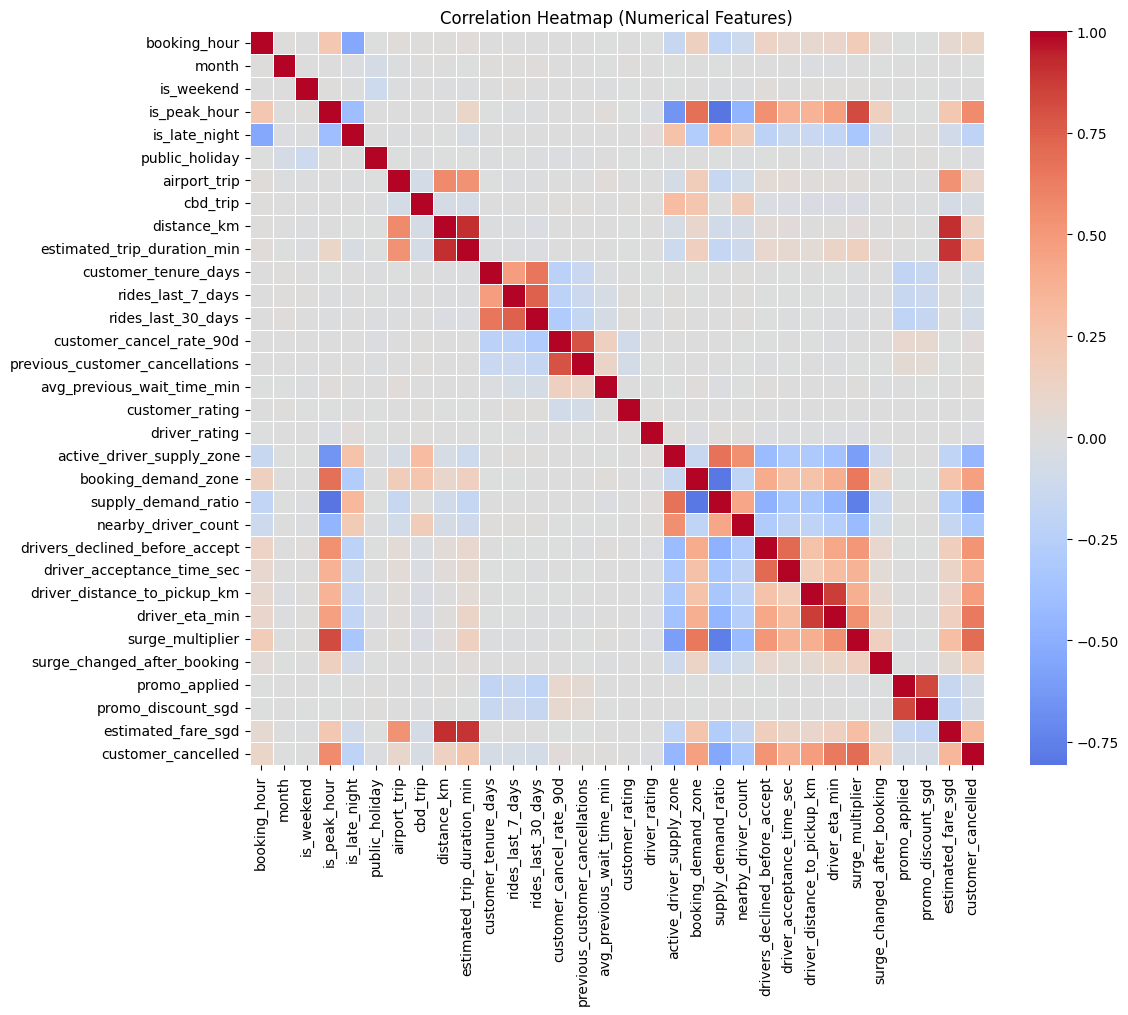

In [ ]:
# Select numeric columns only
df=cleaned2_df
num_df = df.select_dtypes(include=[np.number])

# Correlation matrix
corr = num_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, fmt=".2f",
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

#<font color='green'>**Data Visualisation - Corrrelation Heatmap for Categorial features**

In [ ]:
prompt_v2 = f"""
You are an expert data scientist with extensive experience in binary classification and customer cancellation prediction.

The pandas DataFrame is named `df`.
target column is 'customer_cancelled'
Generate simple executable python codes for correlation heatmat for categorical features
"""

##print('=== Prompt to send ===')
##print(prompt_testing)

response_v2 = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_v2
)
print('\n=== LLM response ===')
print(response_v2.output_text)


=== LLM response ===
```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import is_categorical_dtype, is_object_dtype

# --- Copy df to avoid modifying original ---
df_work = df.copy()

target = 'customer_cancelled'

# Identify categorical features (excluding the target)
cat_cols = []
for c in df_work.columns:
    if c == target:
        continue
    if is_object_dtype(df_work[c]) or is_categorical_dtype(df_work[c]):
        cat_cols.append(c)

# If nothing found, stop gracefully
if not cat_cols:
    print("No categorical features detected (object/category dtypes).")
else:
    # Compute correlation for categorical features using Cramér's V
    def cramers_v(x, y):
        # Drop NA pairs
        m = pd.crosstab(x, y)
        if m.size == 0:
            return 0.0
        chi2 = (m / m.sum().sum()).to_numpy()
        # Use scipy if available; otherwise do a manual chi-square
        try:
            from scipy.stats import chi2_cont

/tmp/ipykernel_5829/2267004160.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_object_dtype(df[c]) or is_categorical_dtype(df[c]):


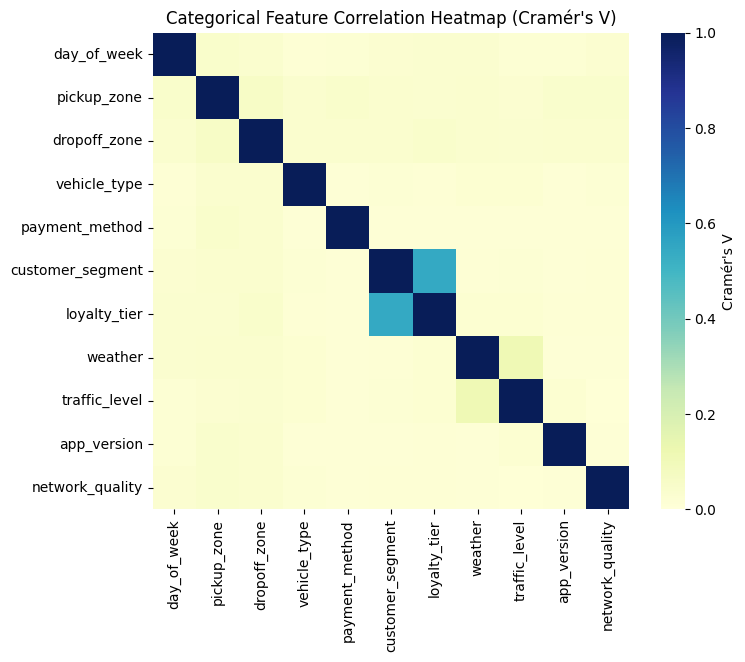

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import is_categorical_dtype, is_object_dtype

# --- Copy df to avoid modifying original ---
df=cleaned2_df

target = 'customer_cancelled'

# Identify categorical features (excluding the target)
cat_cols = []
for c in df.columns:
    if c == target:
        continue
    if is_object_dtype(df[c]) or is_categorical_dtype(df[c]):
        cat_cols.append(c)

# If nothing found, stop gracefully
if not cat_cols:
    print("No categorical features detected (object/category dtypes).")
else:
    # Compute correlation for categorical features using Cramér's V
    def cramers_v(x, y):
        # Drop NA pairs
        m = pd.crosstab(x, y)
        if m.size == 0:
            return 0.0
        chi2 = (m / m.sum().sum()).to_numpy()
        # Use scipy if available; otherwise do a manual chi-square
        try:
            from scipy.stats import chi2_contingency
            chi2_stat, _, _, _ = chi2_contingency(m)
        except Exception:
            # Manual chi-square
            obs = m.to_numpy()
            row_sums = obs.sum(axis=1, keepdims=True)
            col_sums = obs.sum(axis=0, keepdims=True)
            total = obs.sum()
            expected = row_sums @ col_sums / total
            # Prevent division by zero
            with pd.option_context('mode.use_inf_as_na', True):
                chi2_stat = ((obs - expected) ** 2 / expected).sum() if total > 0 else 0.0

        n = m.sum().sum()
        if n == 0:
            return 0.0

        r, k = m.shape
        # Bias-corrected not required for "simple" correlation heatmap
        return (chi2_stat / (n * (min(r - 1, k - 1) if min(r - 1, k - 1) > 0 else 1))) ** 0.5

    # Correlation matrix across categorical features
    corr = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

    for i, col_i in enumerate(cat_cols):
        for j, col_j in enumerate(cat_cols):
            if j < i:
                corr.loc[col_i, col_j] = corr.loc[col_j, col_i]  # symmetry
            elif j == i:
                corr.loc[col_i, col_j] = 1.0
            else:
                corr.loc[col_i, col_j] = cramers_v(df[col_i].astype("string"),
                                                   df[col_j].astype("string"))

    # Plot heatmap
    plt.figure(figsize=(max(8, 0.6 * len(cat_cols)), max(6, 0.6 * len(cat_cols))))
    sns.heatmap(corr, cmap="YlGnBu", vmin=0, vmax=1, annot=False, square=True,
                cbar_kws={"label": "Cramér's V"})
    plt.title("Categorical Feature Correlation Heatmap (Cramér's V)")
    plt.tight_layout()
    plt.show()

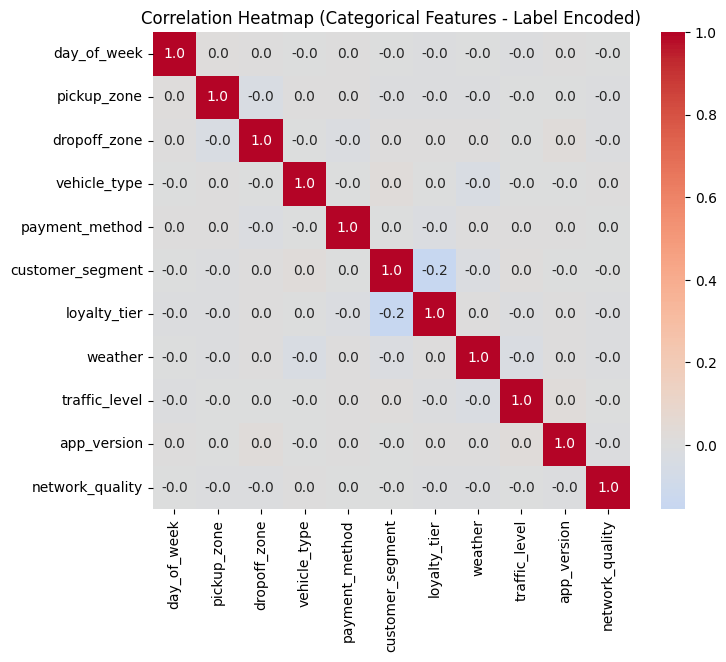

In [ ]:
df=cleaned2_df
# --- pick categorical columns ---
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

# --- prepare an "encoded" copy for heatmap correlation ---
# (Note: correlation for encoded categories is heuristic, not causal/meaningful in a strict sense.)
df_enc = df.copy()
encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # convert NaN to string so LabelEncoder can handle it
    df_enc[c] = le.fit_transform(df_enc[c].astype(str))
    encoders[c] = le

# --- correlation matrix and heatmap ---
corr = df_enc[cat_cols].corr(method="pearson")  # simple correlation heatmap

plt.figure(figsize=(max(8, 0.6*len(cat_cols)), max(6, 0.6*len(cat_cols))))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True,fmt=".1f", square=True)
plt.title("Correlation Heatmap (Categorical Features - Label Encoded)")
plt.tight_layout()
plt.show()

#<font color='green'>**Data Visualisation - boxplots for Numeric features**

In [ ]:
prompt_v3 = f"""
You are an expert data scientist with extensive experience in binary classification and customer cancellation prediction.

The pandas DataFrame is named `df`.
target is customer_cancelled
Generate simple executable python codes for box plots for all features.
Show the plots in 4 columns
"""

##print('=== Prompt to send ===')
##print(prompt_testing)

response_v3 = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_v3
)
print('\n=== LLM response ===')
print(response_v3.output_text)


=== LLM response ===
```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes df is a pandas DataFrame and target column is customer_cancelled
target_col = "customer_cancelled"

# Select candidate feature columns (exclude target)
feature_cols = [c for c in df.columns if c != target_col]

# Keep only numeric features for box plots
numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

# Plotting: 4 columns
ncols = 4
nrows = int(np.ceil(len(numeric_features) / ncols)) if numeric_features else 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)  # flatten in case of 1 row/col

for i, col in enumerate(numeric_features):
    ax = axes[i]
    # Box plots by target groups
    df.boxplot(
        column=col,
        by=target_col,
        ax=ax,
        grid=False,
        widths=0.6
    )
    ax.set_title(col)
    ax.set_xlabel(target_col)
    ax.set_ylabel(col)



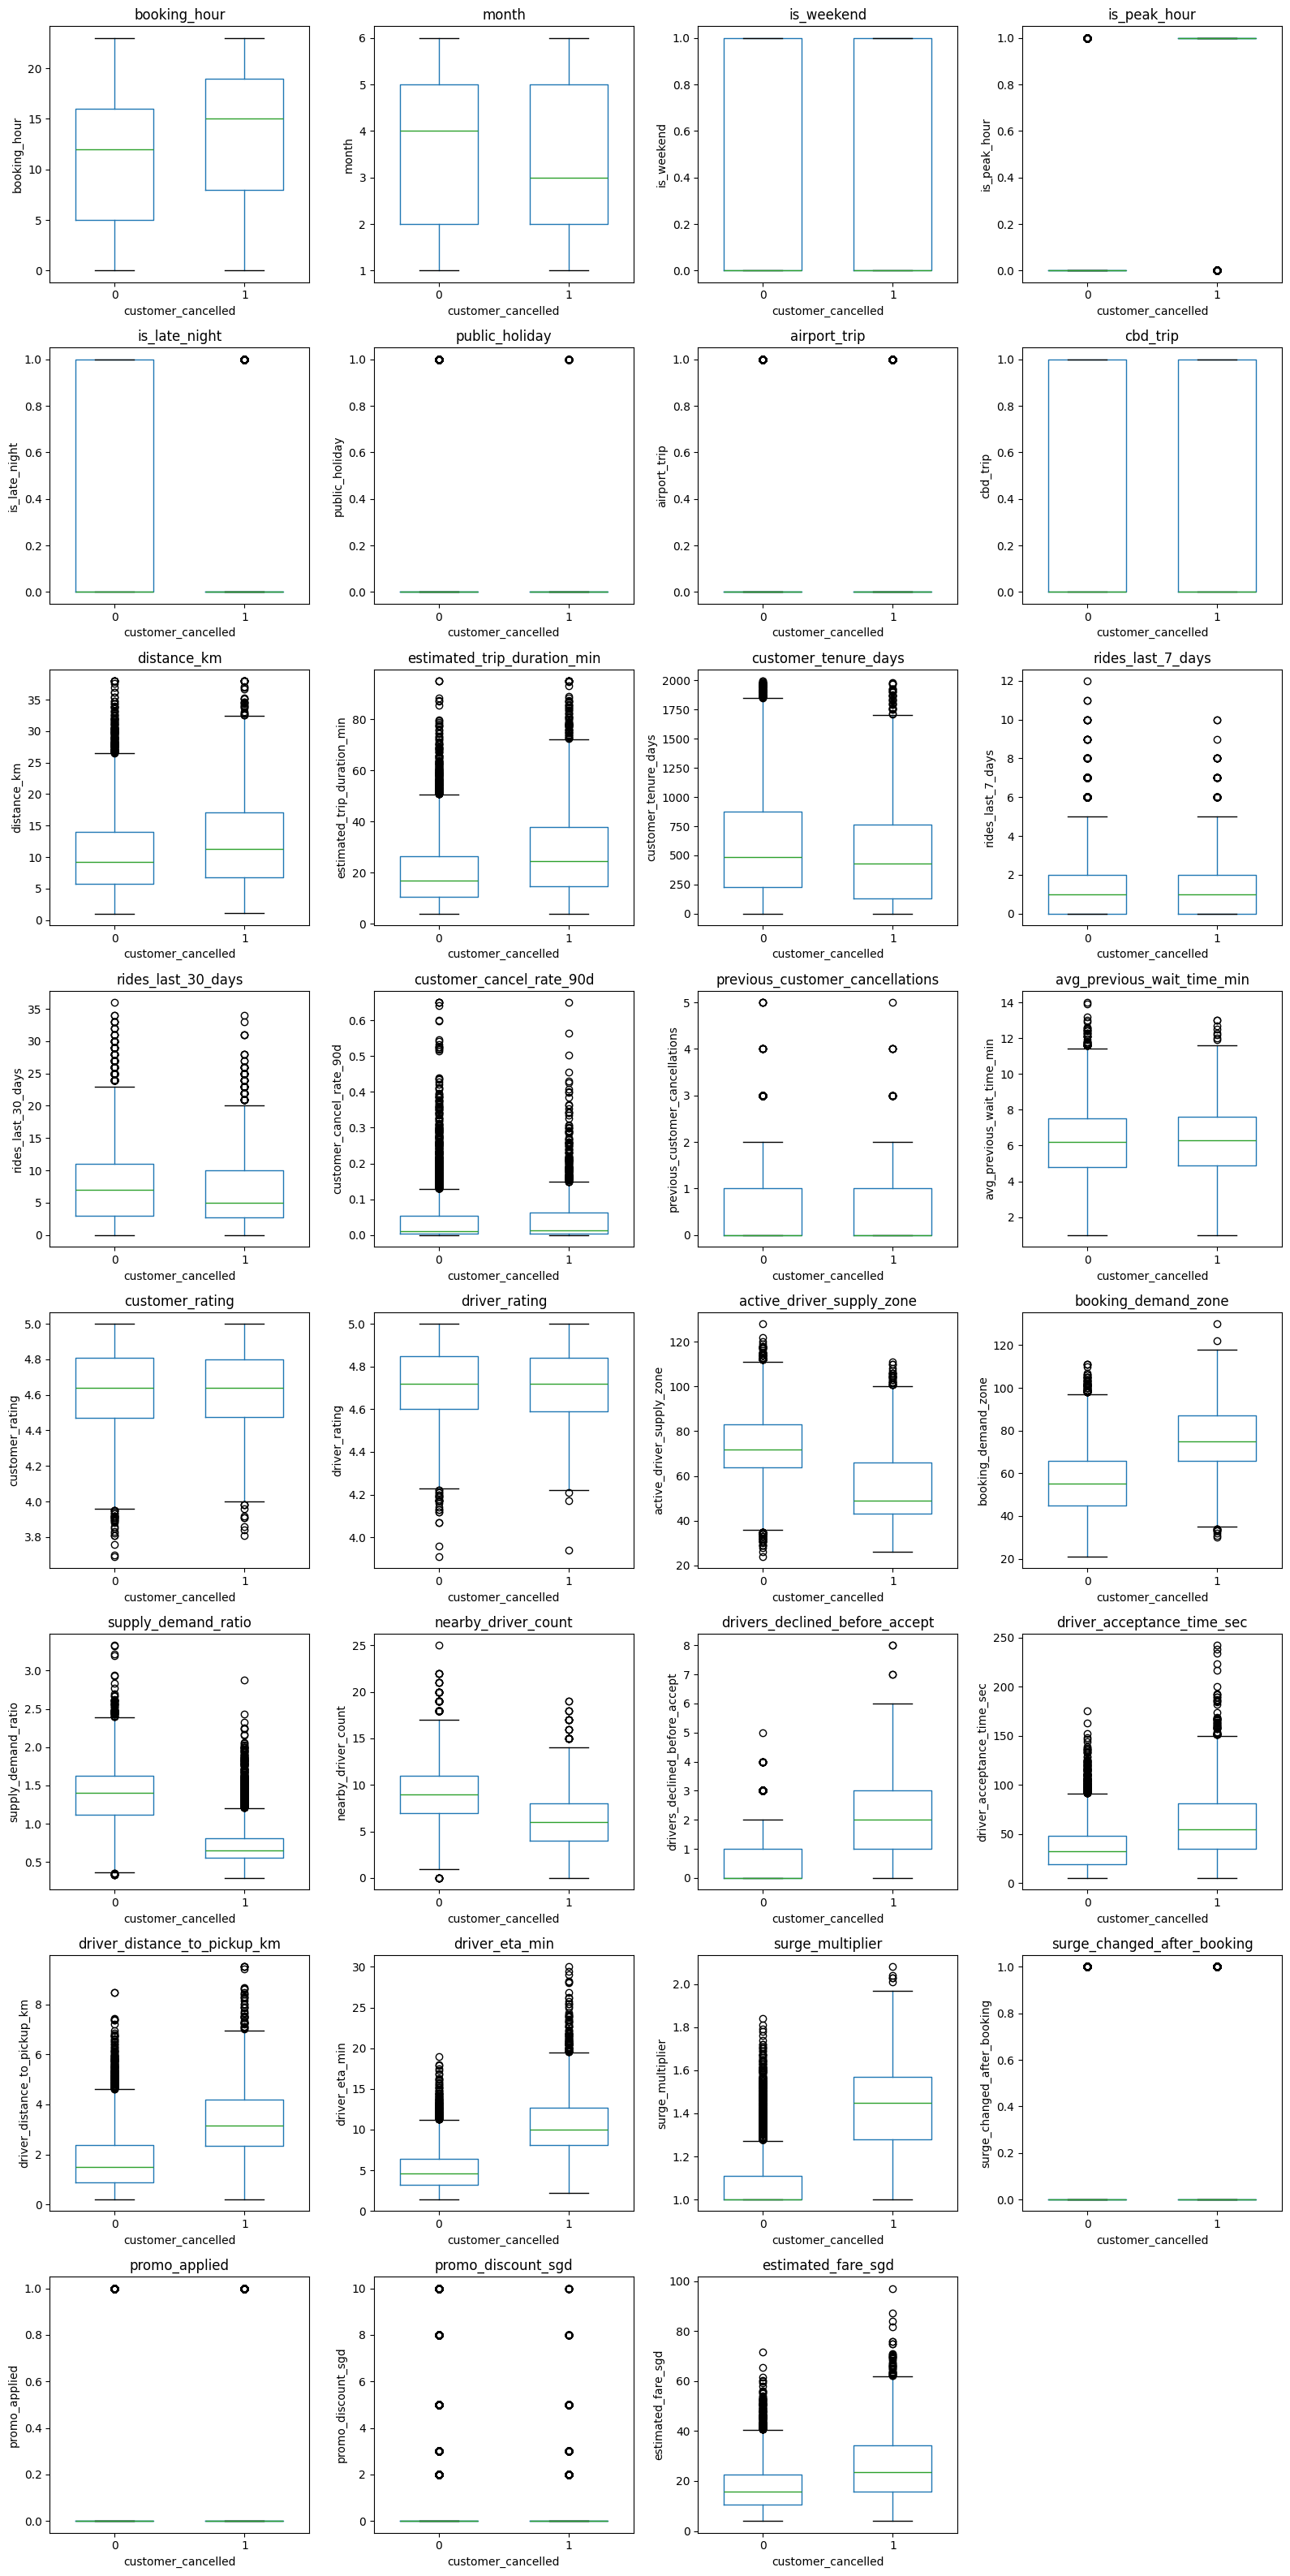

In [ ]:
df=cleaned2_df
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes df is a pandas DataFrame and target column is customer_cancelled
target_col = "customer_cancelled"

# Select candidate feature columns (exclude target)
feature_cols = [c for c in df.columns if c != target_col]

# Keep only numeric features for box plots
numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

# Plotting: 4 columns
ncols = 4
nrows = int(np.ceil(len(numeric_features) / ncols)) if numeric_features else 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)  # flatten in case of 1 row/col

for i, col in enumerate(numeric_features):
    ax = axes[i]
    # Box plots by target groups
    df.boxplot(
        column=col,
        by=target_col,
        ax=ax,
        grid=False,
        widths=0.6
    )
    ax.set_title(col)
    ax.set_xlabel(target_col)
    ax.set_ylabel(col)

    # Remove the automatic "boxplot grouped by ..." suptitle effect
    # (Matplotlib creates a suptitle when using df.boxplot with "by")
    # We'll hide it if present.
    if hasattr(ax.figure, "_suptitle") and ax.figure._suptitle is not None:
        ax.figure._suptitle.set_visible(False)

# Hide any unused subplots
for j in range(len(numeric_features), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

#<font color='green'>**Data Visualisation - histograms for Numeric features**

In [ ]:
prompt_v4 = f"""
You are an expert data scientist with extensive experience in binary classification and customer cancellation prediction.

The pandas DataFrame is named `df`.
target is customer_cancelled
Generate simple executable python codes for histograms plots for all numeric features.
Show the plots in 4 columns
"""

##print('=== Prompt to send ===')
##print(prompt_testing)

response_v4 = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_v4
)
print('\n=== LLM response ===')
print(response_v4.output_text)


=== LLM response ===
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume df already exists
target = "customer_cancelled"

# Select numeric feature columns (excluding target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target in numeric_cols:
    numeric_cols.remove(target)

# Plot histograms for all numeric features in 4 columns
n_cols = 4
n_plots = len(numeric_cols)
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
axes = np.array(axes).reshape(-1)  # flatten for easy indexing

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    df[col].dropna().hist(bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

# Hide any unused subplots
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
```


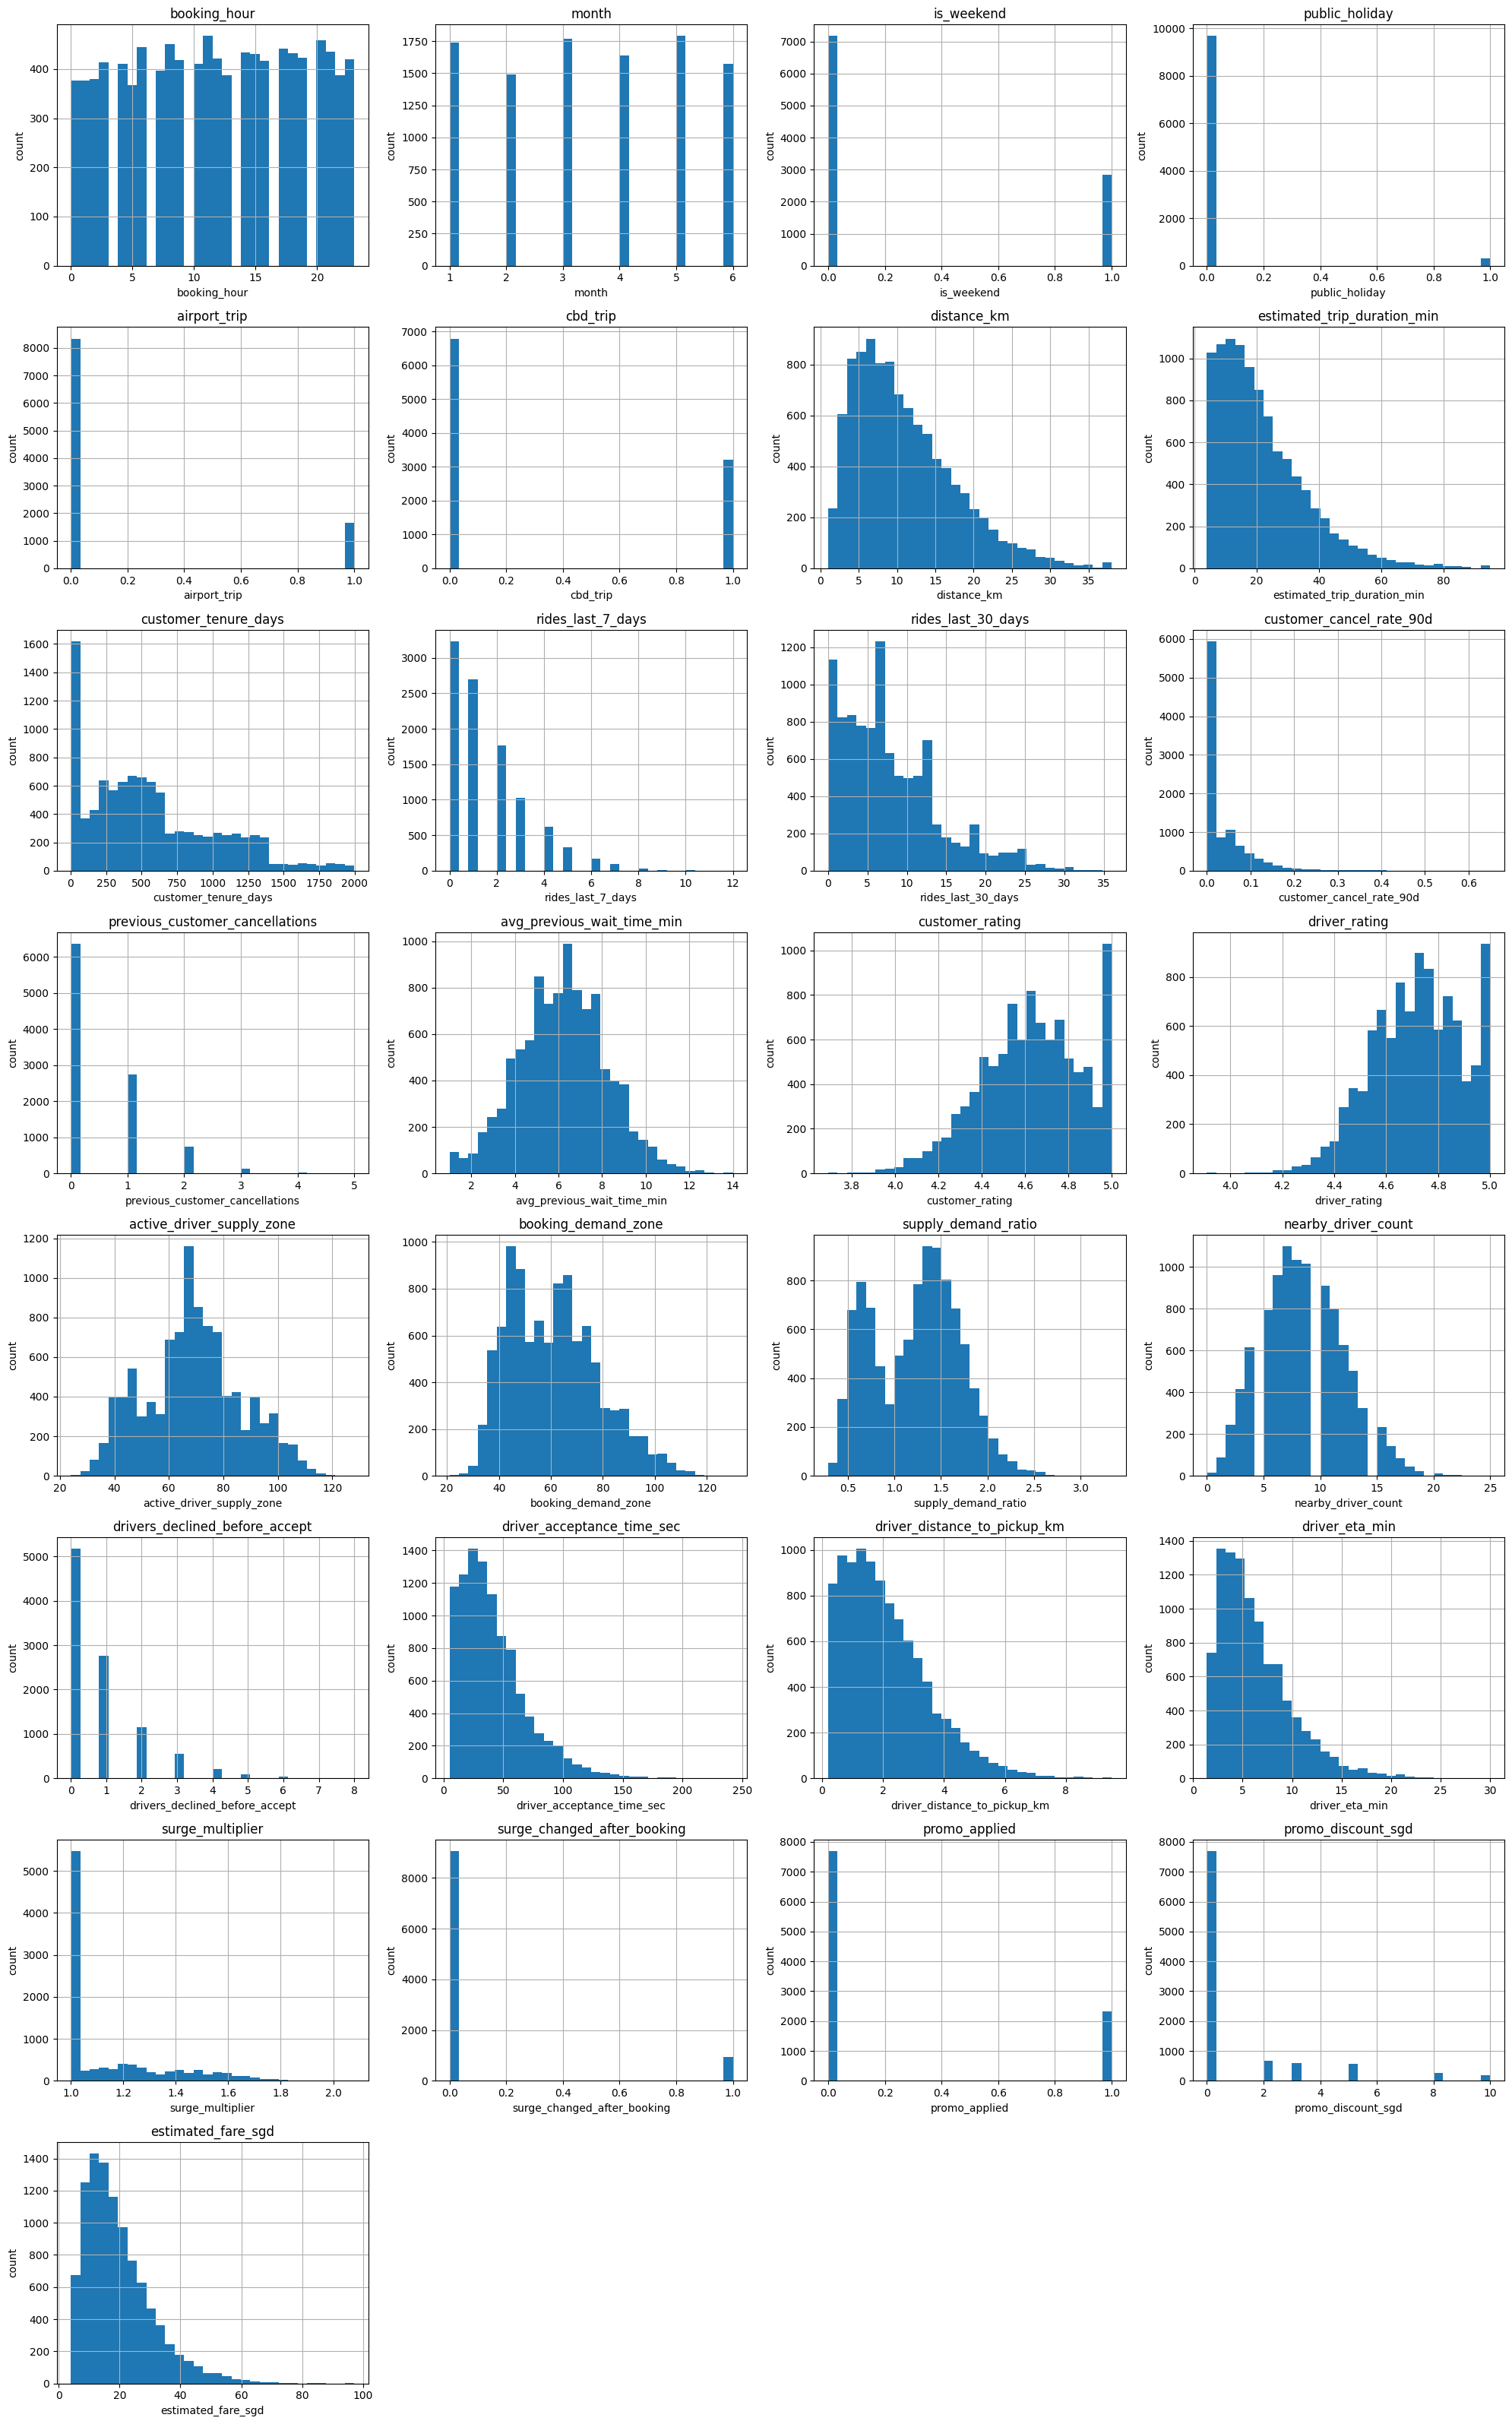

In [ ]:
df = cleaned2_df

# Identify numeric feature columns (excluding target if it's numeric)
target_col = "customer_cancelled"
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target_col]

# Plot histograms in a grid with 4 columns
n_cols = 4
n_plots = len(numeric_cols)
n_rows = int(np.ceil(n_plots / n_cols)) if n_plots > 0 else 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = np.array(axes).reshape(-1)  # flatten in case of 1 row

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    df[col].dropna().hist(ax=ax, bins=30)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("count")

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

#<font color='green'>**Data Visualisation - Bar charts for Categorical features**

In [ ]:
prompt_v5 = f"""
You are an expert data scientist with extensive experience in binary classification and customer cancellation prediction.

The pandas DataFrame is named `df`.
target is customer_cancelled
Generate simple executable python codes for 100% stacked barcharts for all categorical features.
Show the plots in 4 columns
"""

##print('=== Prompt to send ===')
##print(prompt_testing)

response_v5 = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_v5
)
print('\n=== LLM response ===')
print(response_v5.output_text)


=== LLM response ===
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure the target exists
if 'customer_cancelled' not in df.columns:
    raise ValueError("Target column 'customer_cancelled' not found in df.")

y = df['customer_cancelled'].dropna()

# Categorical columns (object/category/bool) excluding the target
cat_cols = [
    c for c in df.columns
    if c != 'customer_cancelled' and (
        pd.api.types.is_object_dtype(df[c]) or
        pd.api.types.is_categorical_dtype(df[c]) or
        pd.api.types.is_bool_dtype(df[c])
    )
]

if not cat_cols:
    raise ValueError("No categorical features found (object/category/bool).")

ncols = 4
nrows = int(np.ceil(len(cat_cols) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)  # flatten for easy indexing

for i, col in enumerate(cat_cols):
    ax = axes[i]

    # Compute cancellation rate distribution per category
    tmp = d

/tmp/ipykernel_5829/3728027131.py:13: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[c])


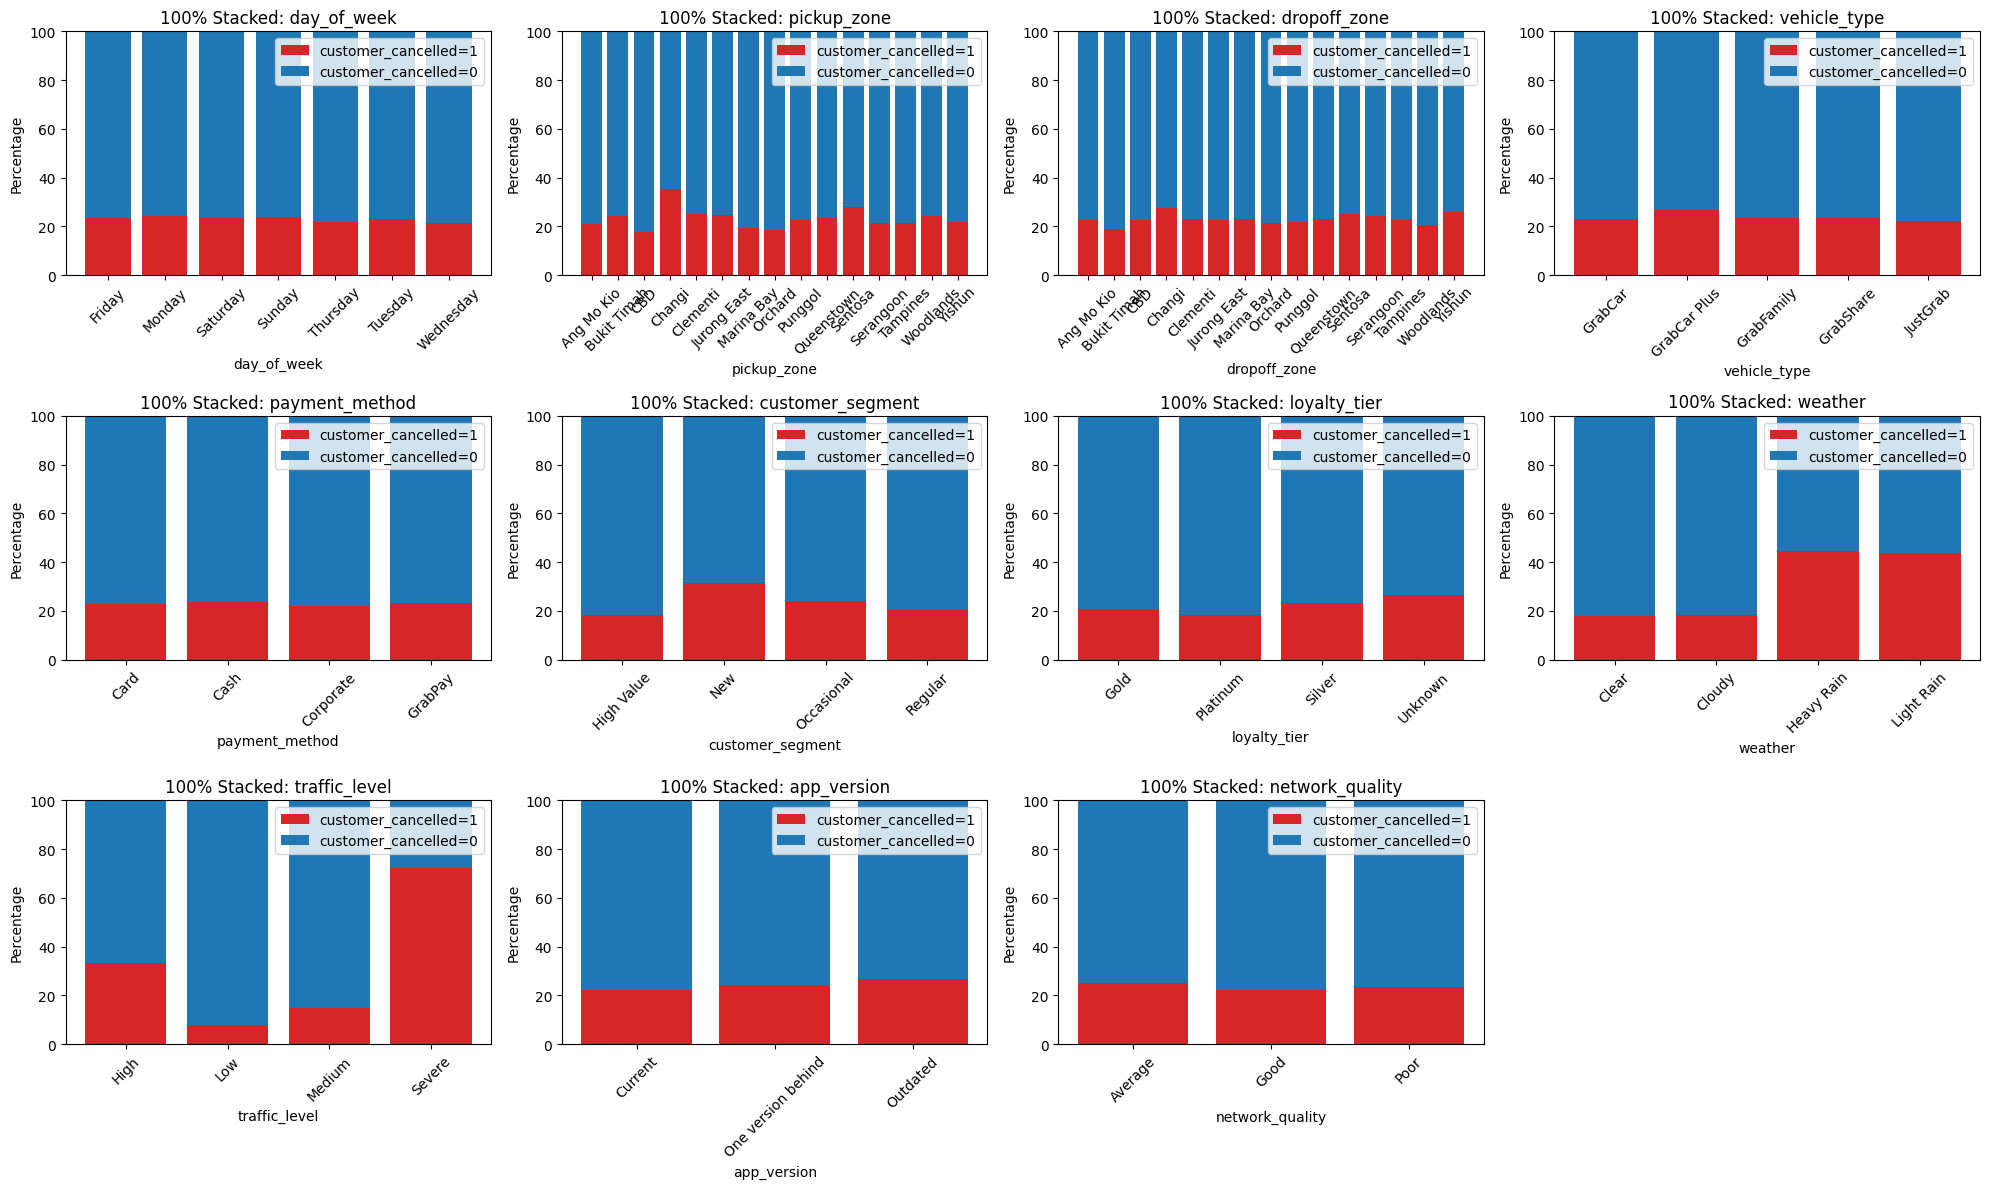

In [ ]:
df = cleaned2_df

import math
import pandas as pd
import matplotlib.pyplot as plt

# ----- Identify categorical features -----
# (object and category are treated as categorical; bool also often behaves categorical)
categorical_cols = [
    c for c in df.columns
    if c != "customer_cancelled"
    and (pd.api.types.is_object_dtype(df[c])
         or pd.api.types.is_categorical_dtype(df[c])
         or pd.api.types.is_bool_dtype(df[c]))
]

y_col = "customer_cancelled"

# Ensure target is only two classes for stacking
# (If your target is already 0/1 this is fine; otherwise it will still work)
# We'll count occurrences directly by category and target value.
n = len(categorical_cols)
if n == 0:
    print("No categorical columns found (excluding customer_cancelled).")
else:
    cols = 4
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, col in enumerate(categorical_cols):
        ax = axes[i]

        # Build contingency table: categories x target
        ct = pd.crosstab(df[col], df[y_col])

        # Ensure consistent order: cancelled then not cancelled if present
        # (Common cases: 1/0 or True/False)
        # If these labels don't exist, just use sorted columns.
        target_labels = list(ct.columns)
        if 1 in ct.columns and 0 in ct.columns:
            target_labels = [1, 0]
        elif True in ct.columns and False in ct.columns:
            target_labels = [True, False]
        else:
            # fallback: sorted for stable plotting
            target_labels = sorted(ct.columns, key=lambda x: str(x))

        # Plot 100% stacked bars: each category sums to 100%
        totals = ct.sum(axis=1).replace(0, 1)
        pct = ct[target_labels].div(totals, axis=0) * 100

        bottom = None
        colors = ["#d62728", "#1f77b4"]  # cancelled / not cancelled (if two classes)

        for j, tval in enumerate(target_labels):
            series = pct[tval].values
            label = f"{y_col}={tval}"
            if bottom is None:
                ax.bar(pct.index.astype(str), series, label=label, color=colors[j] if j < len(colors) else None)
                bottom = series
            else:
                ax.bar(pct.index.astype(str), series, bottom=bottom, label=label,
                       color=colors[j] if j < len(colors) else None)
                bottom = bottom + series

        ax.set_title(f"100% Stacked: {col}")
        ax.set_ylim(0, 100)
        ax.set_ylabel("Percentage")
        ax.set_xlabel(col)
        ax.tick_params(axis='x', rotation=45)
        ax.legend()

    # Hide any unused subplots
    for k in range(i + 1, len(axes)):
        axes[k].axis("off")

    plt.tight_layout()
    plt.show()


#<font color='green'>**Data Visualisation - multicollinearity**

#**Correlations for Categorical features**

In [ ]:
# Option2:One-Hot Encode + Correlation (Simple)

target = "customer_cancelled"

cat_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

encoded = pd.get_dummies(
    df[cat_cols],
    drop_first=False
)

corr_df = (
    encoded.join(df[target])
           .corr()[target]
           .drop(target)
           .sort_values(key=abs, ascending=False)
           .reset_index()
)

corr_df.columns = [
    "Feature",
    "Correlation with customer_cancelled"
]

display(corr_df.head(40))


,Feature,Correlation with customer_cancelled
0,traffic_level_Severe,0.358527
1,weather_Light Rain,0.206191
2,traffic_level_Low,-0.199922
3,traffic_level_Medium,-0.163701
4,traffic_level_High,0.147799
5,weather_Clear,-0.126735
6,weather_Heavy Rain,0.108666
7,pickup_zone_Changi,0.086956
8,customer_segment_New,0.080224
9,weather_Cloudy,-0.071503


#<font color = 'green'>**Chapter XX-1:TESTING !!! Prompt LLM to recommend baseline model, evaluation metrics**

In [ ]:
cleaned_preview = cleaned2_df.head()
prompt_testing = f"""
You are an expert data scientist with extensive experience in binary classification and customer cancellation prediction.

The pandas DataFrame is named `df`.

Target column:
customer_cancelled
- 0 = customer did not cancel
- 1 = customer cancelled

=========================
DATASET PREVIEW
=========================
Dataset {cleaned_preview} is cleaned without missingness, leakages, ID like columns, datetime columns

Use ONLY the information provided in the Dataset Profile.
Do NOT assume columns, relationships, distributions, or values that are not explicitly stated.
If information is unavailable, clearly state that it cannot be determined from the Dataset Profile.

=========================
BUSINESS CONTEXT
=========================

Business Problem:
Grab Ride Operations Manager has observed a high rate of customer cancellations before trip commencement over the past few months.

Business Objective:
Develop a machine learning model that predicts the probability that a customer will cancel a ride before trip commencement.

Business Goal:
Reduce customer pre-trip cancellations by enabling proactive operational interventions.

Dataset Context:
Each row represents one Grab booking.
Approximately 23% of bookings were cancelled before trip commencement.
The dataset contains customer information, pick up and drop off details, booking details, driver availability, pricing, weather, traffic conditions and booking outcomes.

=========================
TASK
=========================

1. Recommend the most appropriate simple baseline model.

For your recommendation:
- Explain why it is suitable.
- Explain why it is a good baseline.
- Relate your reasoning to the dataset characteristics and business objective.

2. Recommend the key hyperparameters for the baseline model.

For each hyperparameter provide:
- Recommended value
- Why it is appropriate
- Whether it helps improve generalisation or reduce overfitting

3. Recommend 4 most suitable evaluation metrics for this problem. Include MCC if suitable

For each metric explain:
- What it measures
- Why it is appropriate
- Whether higher or lower values are better

4. Recommend exploratory data analysis (EDA) plots to better understand the dataset before modelling.

For each plot explain:
- What it shows
- Why it is useful

5. Recommend model evaluation plots after training.

For each plot explain:
- What it shows
- How it helps evaluate the classifier
- Why it is useful for the Grab business problem.
"""

##print('=== Prompt to send ===')
##print(prompt_testing)

response_testing = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_testing
)
print('\n=== LLM response ===')
print(response_testing.output_text)



=== LLM response ===
Below are baseline/modeling recommendations using **only** what can be inferred from the provided dataset preview/profile-style description (categorical + numeric features, cleaned, no missingness, no leakage/ID-like/datetime columns). I’ll avoid assuming distributions beyond what’s explicitly said (e.g., “~23% cancelled” and that the dataset is already cleaned without missingness/leakage/ID-like/datetime columns).

---

## 1) Most appropriate simple baseline model

### Recommendation: **Logistic Regression (with L2 regularization)**
**Why it is suitable (given the dataset/objective)**
- The target is **binary** (`customer_cancelled` = 0/1) and the business objective is to estimate **pre-trip cancellation risk**, i.e., a probability.
- **Logistic Regression** outputs calibrated probabilities (often via post-calibration if needed), which are directly actionable for prioritizing interventions (e.g., “highest cancellation risk first”).
- The dataset includes **mixed 

#<font color = 'green'>**Chapter XX-2:TESTING !!! Prompt LLM to create scripts based on Chapter XX-1**

In [ ]:
prompt_testing2 = f"""
You are an expert data scientist with extensive experience in binary classification and customer cancellation prediction.

The pandas DataFrame is named `df`.

Target column:
customer_cancelled
- 0 = customer did not cancel
- 1 = customer cancelled

Based on {response_testing}
Generate simple, executable Python code with clear comments.


Important requirements:
- For traffic_level feature, use ordinal encoding as the labels are in such severity order 'Severe' > 'High' > 'Medium'> 'Low'
- For loyalty_tier feature, use ordinal encoding as the labels are in such order 'Platinum' > 'Gold' > 'Silver'> 'NA'
- Ensure all result tables are displayed clearly in Google Colab.
- The code must be compatible with commonly used versions of scikit-learn.
- The plotting code must compatible with Matplotlib {matplotlib.__version__} or later.
"""
##print('=== Prompt to send ===')
##print(prompt_testing2)

response_testing2 = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_testing2
)
print('\n=== LLM response ===')
print(response_testing2.output_text)




=== LLM response ===
```python
# Customer cancellation prediction (binary classification)
# Target: customer_cancelled (0/1)
#
# Assumptions:
# - df is already loaded as a pandas DataFrame
# - There are no missing values (per your dataset description)
# - You have mixed numeric + categorical columns
#
# Requirements implemented:
# - Ordinal encoding for:
#   * traffic_level: 'Severe' > 'High' > 'Medium' > 'Low'
#   * loyalty_tier: 'Platinum' > 'Gold' > 'Silver' > 'NA'
# - Simple baseline: Logistic Regression (L2, class_weight="balanced")
# - Metrics: MCC, F1, ROC-AUC, PR-AUC
# - Clear result tables for Google Colab
# - Matplotlib compatible with 3.10+

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklear

#**<font color='red'> RUN CODE**

Train shape: (8000, 42) Test shape: (2000, 42)
Positive rate (cancelled) in train: 0.23
Positive rate (cancelled) in test : 0.23

Numeric columns: ['booking_hour', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night', 'public_holiday', 'airport_trip', 'cbd_trip', 'distance_km', 'estimated_trip_duration_min', 'customer_tenure_days', 'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d', 'previous_customer_cancellations', 'avg_previous_wait_time_min', 'customer_rating', 'driver_rating', 'active_driver_supply_zone', 'booking_demand_zone', 'supply_demand_ratio', 'nearby_driver_count', 'drivers_declined_before_accept', 'driver_acceptance_time_sec', 'driver_distance_to_pickup_km', 'driver_eta_min', 'surge_multiplier', 'surge_changed_after_booking', 'promo_applied', 'promo_discount_sgd', 'estimated_fare_sgd']
Ordinal categorical columns: ['traffic_level', 'loyalty_tier']
Nominal categorical columns: ['day_of_week', 'pickup_zone', 'dropoff_zone', 'vehicle_type', 'payment_meth

,Model,Threshold,MCC,F1 (cancelled=1),ROC-AUC,PR-AUC
0,"LogisticRegression (L2, class_weight=balanced)",0.5,0.824519,0.864919,0.984184,0.959227


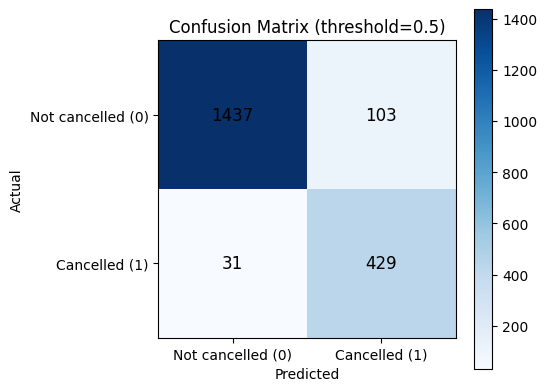


=== Confusion Counts ===


,TN,FP,FN,TP
0,1437,103,31,429


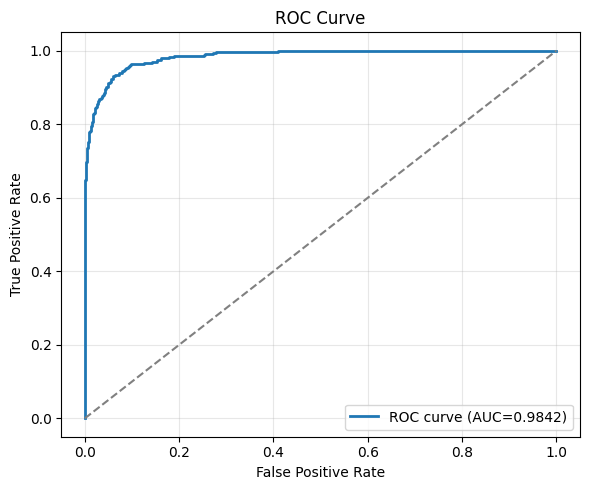

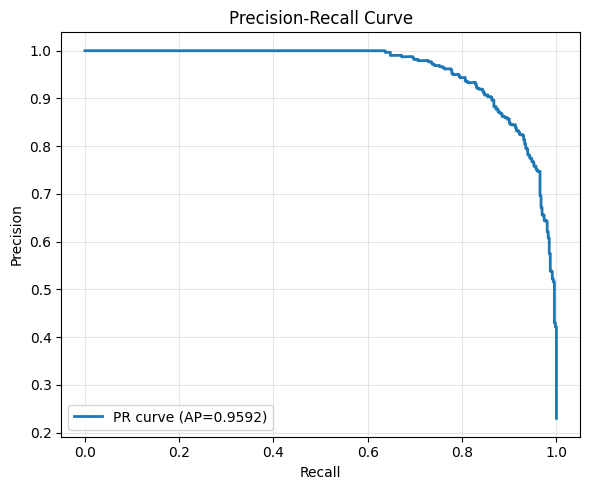


=== Risk Deciles (Top-risk first) ===


,decile,n,cancelled_rate,avg_proba
9,9,200,1.00,0.998957
8,8,200,0.87,0.950790
7,7,200,0.35,0.579862
6,6,200,0.05,0.171669
5,5,200,0.02,0.046776
4,4,200,0.01,0.015656
3,3,200,0.00,0.005261
2,2,200,0.00,0.001886
1,1,200,0.00,0.000699
0,0,200,0.00,0.000190


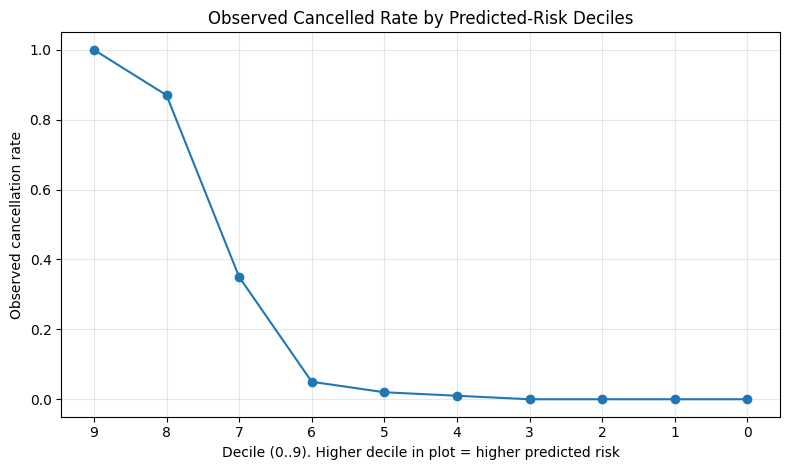

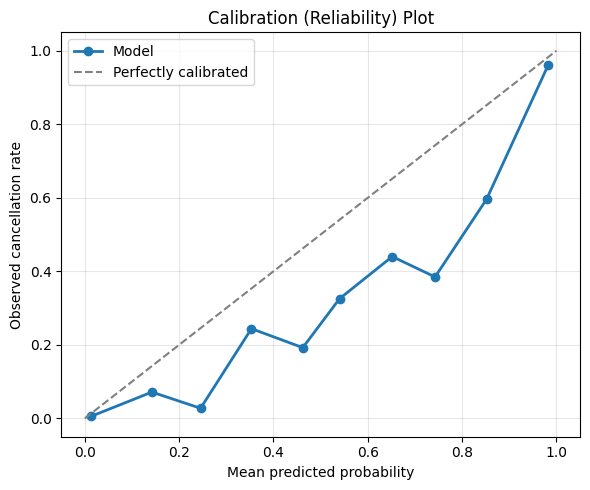


=== Additional Calibration Metric ===


,Brier score (lower is better)
0,0.04774


In [ ]:
# Customer cancellation prediction (binary classification)
# Target: customer_cancelled (0/1)
#
# Assumptions:
# - df is already loaded as a pandas DataFrame
# - There are no missing values (per your dataset description)
# - You have mixed numeric + categorical columns
#
# Requirements implemented:
# - Ordinal encoding for:
#   * traffic_level: 'Severe' > 'High' > 'Medium' > 'Low'
#   * loyalty_tier: 'Platinum' > 'Gold' > 'Silver' > 'NA'
# - Simple baseline: Logistic Regression (L2, class_weight="balanced")
# - Metrics: MCC, F1, ROC-AUC, PR-AUC
# - Clear result tables for Google Colab
# - Matplotlib compatible with 3.10+

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    matthews_corrcoef,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# -----------------------------
# 0) Basic checks
# -----------------------------
TARGET = "customer_cancelled"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in df.")

# Ensure binary target dtype
df = df.copy()
df[TARGET] = df[TARGET].astype(int)

# -----------------------------
# 1) Train/test split
# -----------------------------
X = df.drop(columns=[TARGET])
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Positive rate (cancelled) in train:", y_train.mean())
print("Positive rate (cancelled) in test :", y_test.mean())

# -----------------------------
# 2) Identify column types
# -----------------------------
# Ordinal features (as specified by business ordering)
ORDINAL_FEATURES = ["traffic_level", "loyalty_tier"]

# Determine categorical/numeric columns automatically
# (If your df has other encoded categoricals, they will be treated as categorical.)
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

# Keep only ordinal features that actually exist
ordinal_cols = [c for c in ORDINAL_FEATURES if c in X_train.columns]

# Remaining categorical columns excluding the ordinal ones
nominal_categorical_cols = [c for c in categorical_cols if c not in ordinal_cols]

print("\nNumeric columns:", numeric_cols)
print("Ordinal categorical columns:", ordinal_cols)
print("Nominal categorical columns:", nominal_categorical_cols)

# -----------------------------
# 3) Preprocessing
# -----------------------------
# Ordinal encoding with explicit severity/loyalty ordering
ordinal_categories = []
for col in ordinal_cols:
    if col == "traffic_level":
        ordinal_categories.append(["Low", "Medium", "High", "Severe"])
    elif col == "loyalty_tier":
        # Order given: Platinum > Gold > Silver > NA
        # OrdinalEncoder maps increasing integers to increasing category order.
        ordinal_categories.append(["NA", "Silver", "Gold", "Platinum"])
    else:
        raise ValueError(f"Unexpected ordinal feature: {col}")

ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# One-hot for nominal categoricals
onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True  # works in recent sklearn
)

preprocess = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, ordinal_cols),
        ("nominal_cat", onehot_encoder, nominal_categorical_cols),
        ("num", "passthrough", numeric_cols),
    ],
    remainder="drop"
)

# -----------------------------
# 4) Baseline model: Logistic Regression (L2 + balanced class_weight)
# -----------------------------
# Hyperparameters (pragmatic defaults; you can tune C later)
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# -----------------------------
# 5) Fit
# -----------------------------
clf.fit(X_train, y_train)

# -----------------------------
# 6) Predict + evaluate
# -----------------------------
# Use probability for ranking metrics and threshold selection.
y_proba = clf.predict_proba(X_test)[:, 1]

# Default threshold 0.5 for classification metrics
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

mcc = matthews_corrcoef(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

results = pd.DataFrame([{
    "Model": "LogisticRegression (L2, class_weight=balanced)",
    "Threshold": threshold,
    "MCC": mcc,
    "F1 (cancelled=1)": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}])

print("\n=== Performance Summary ===")
results_display = results.copy()
display(results_display)

# -----------------------------
# 7) Confusion Matrix plot
# -----------------------------
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (threshold=0.5)")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Not cancelled (0)", "Cancelled (1)"], rotation=0)
plt.yticks(tick_marks, ["Not cancelled (0)", "Cancelled (1)"])

# Annotate counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12, color="black")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Also show a table of confusion counts in Colab
conf_table = pd.DataFrame([{
    "TN": tn, "FP": fp, "FN": fn, "TP": tp
}])
print("\n=== Confusion Counts ===")
display(conf_table)

# -----------------------------
# 8) Curves: ROC and Precision-Recall
# -----------------------------
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC={roc_auc_val:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc_val = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR curve (AP={pr_auc_val:.4f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 9) Risk deciles / lift chart (operational usefulness)
# -----------------------------
# Sort by predicted probability and compute realized cancel rate per decile.
test_df = X_test.copy()
test_df["y_true"] = y_test
test_df["y_proba"] = y_proba

# Create deciles (10 bins). Handle duplicates in quantiles safely.
test_df["decile"] = pd.qcut(test_df["y_proba"], 10, labels=False, duplicates="drop")

decile_summary = (
    test_df.groupby("decile")
    .agg(
        n=("y_true", "size"),
        cancelled_rate=("y_true", "mean"),
        avg_proba=("y_proba", "mean")
    )
    .reset_index()
    .sort_values("decile", ascending=False)  # high-risk decile first
)

print("\n=== Risk Deciles (Top-risk first) ===")
display(decile_summary)

plt.figure(figsize=(8, 4.8))
plt.plot(
    np.arange(len(decile_summary)),
    decile_summary["cancelled_rate"].values,
    marker="o"
)
plt.xticks(np.arange(len(decile_summary)), decile_summary["decile"].astype(str).values, rotation=0)
plt.xlabel("Decile (0..9). Higher decile in plot = higher predicted risk")
plt.ylabel("Observed cancellation rate")
plt.title("Observed Cancelled Rate by Predicted-Risk Deciles")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 10) Calibration plot (simple reliability curve)
# -----------------------------
# Bin predicted probabilities and compare mean predicted vs observed.
n_bins = 10
bins = np.linspace(0.0, 1.0, n_bins + 1)
bin_ids = np.digitize(test_df["y_proba"], bins) - 1
bin_ids = np.clip(bin_ids, 0, n_bins - 1)

calib = (
    test_df.assign(bin=bin_ids)
    .groupby("bin")
    .agg(
        count=("y_true", "size"),
        mean_pred=("y_proba", "mean"),
        frac_pos=("y_true", "mean"),
    )
    .reset_index()
    .sort_values("mean_pred")
)

plt.figure(figsize=(6, 5))
plt.plot(calib["mean_pred"], calib["frac_pos"], marker="o", linewidth=2, label="Model")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed cancellation rate")
plt.title("Calibration (Reliability) Plot")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Brier score (lower is better)
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, y_proba)
print("\n=== Additional Calibration Metric ===")
calib_table = pd.DataFrame([{"Brier score (lower is better)": brier}])
display(calib_table)



#<font color = 'green'>**Chapter XX-3:TESTING !!! Ask LLM to give interpretation based on the metrics results**

In [ ]:
prompt_testing3=f"""
based on these metrics results

{roc_auc},{pr_auc},{cm},{conf_table},{y_proba},{y_pred},{mcc},{f1},{results},{roc_auc_val},{pr_auc_val}

Give concise model interpretation and recommendations for improvement.
"""
response_testing3 = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_testing3
)
print('\n=== LLM response ===')
print(response_testing3.output_text)



=== LLM response ===
### Concise interpretation
- **Performance is strong**:  
  - **ROC-AUC = 0.984**, **PR-AUC = 0.959** → excellent class separability and high precision/recall quality (especially important under class imbalance).
- **Overall classification is good at threshold = 0.5**:  
  - From the confusion matrix **TN=1437, FP=103, FN=31, TP=429**:
    - **Recall (cancelled=1)** ≈ 429 / (429+31) = **93.2%** (few missed cancellations)
    - **Precision** ≈ 429 / (429+103) = **80.7%**
- **Tradeoff**: There are **more false positives than false negatives** (103 FP vs 31 FN), so the model sometimes flags cancellations that don’t happen.

### Recommendations to improve
1. **Tune the decision threshold to optimize your goal**  
   - If false positives are costly, raise the threshold; if false negatives are costly, lower it.  
   - Use **F1** or **cost-weighted metrics** / **maximize Youden’s J** on a validation set.
2. **Inspect calibration and probability quality**  
   - Run **cal

#**Chapter 9. Prompt LLM to create scripts for Baseline Modelling from Train/Test Split till Model Evaluation**

In [ ]:
df = cleaned2_df

prompt_model = f"""
You are an expert data scientist with experience in binary classification models.

The pandas DataFrame is named `df`.
The target column is `customer_cancelled`, where:
- 0 = customer did not cancel
- 1 = customer cancelled

Generate simple, executable Python code with clear comments.
The code must be compatible with commonly used versions of scikit-learn.

Important requirements:
- Treat this as a binary classification problem, not regression.
- Do not use MAE, RMSE, MSE, MAPE, or R-squared.
- Use a scikit-learn Pipeline so preprocessing is fitted only on the training data.
- Use `random_state=42` where applicable.
- Use stratification when splitting the target.
- Handle unknown categorical values using
  `OneHotEncoder(handle_unknown="ignore")`.
- Use `max_iter=1000` Logistic Regression.
- Use predicted class probabilities from
  `predict_proba(X_test)[:, 1]`.
- Do not assume specific feature names other than the target.
- Automatically identify numerical and categorical columns.
- Exclude datetime columns from numerical preprocessing. Print any datetime
  columns found and drop them before modelling.
- Ensure all result tables are displayed clearly in Google Colab.
- When plotting ROC or Precision–Recall curves using RocCurveDisplay or PrecisionRecallDisplay,
  do not pass ax=plt.
  Either omit the ax parameter or create an Axes object with fig, ax = plt.subplots() and pass ax=ax.
- Generate plotting code compatible with Matplotlib {matplotlib.__version__} or later.

Generate code to perform the following:

1. Create `X` and `y`, where `X` contains all input features and `y` is
   `customer_cancelled`.

2. Check the target distribution and display the count and percentage of
   each class.

3. Split the data into training and test sets using:
   - `test_size=0.2`
   - `random_state=42`
   - `stratify=y`

4. Identify:
   - numerical columns using `select_dtypes(include="number")`
   - categorical columns using
     `select_dtypes(include=["object", "category", "bool"])`
   - datetime columns separately

5. Create a preprocessing pipeline:
   - numerical features: median imputation followed by StandardScaler
   - categorical features: most-frequent imputation followed by
     OneHotEncoder(handle_unknown="ignore")

6. Create and train a baseline Logistic Regression model using:
   - `random_state=42`
   - `max_iter=1000`
   - `class_weight="balanced"`

7. Generate predictions:
   - training class predictions
   - test class predictions
   - training cancellation probabilities
   - test cancellation probabilities

8. Evaluate the model on both the training and test sets using:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - Average Precision

   Save the results in a DataFrame named `results_df`, with one row for the
   training set and one row for the test set.

9. Display the test classification report and provide a brief interpretation
   of:
   - true positives
   - true negatives
   - false positives
   - false negatives
   - whether the train and test results suggest overfitting

10. Perform 5-split cross-validation using `StratifiedShuffleSplit` with:
    - `n_splits=5`
    - `test_size=0.2`
    - `random_state=42`

11. During cross-validation, evaluate:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - ROC-AUC
    - Average Precision

    Save the mean and standard deviation of each validation metric in a
    DataFrame named `cv_results_df`.

12. Plot predicted cancellation probability by actual class using a boxplot.

13. Plot the confusion matrix with labels:
    - Not Cancelled
    - Cancelled

14. Plot an actual-versus-predicted class-count bar chart.

15. Plot the ROC curve and display the ROC-AUC value.

16. Plot the Precision-Recall curve and display the Average Precision value.

17. At the end, print a concise model interpretation explaining:
    - how well the model detects cancellations
    - the meaning of precision and recall in this business context
    - whether false positives or false negatives may be more costly
    - any limitations of evaluating only one model
"""

print('=== Prompt to send ===')
print(prompt_model)

response_model = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_model
)
print('\n=== LLM response ===')
print(response_model.output_text)



=== Prompt to send ===

You are an expert data scientist with experience in binary classification models.

The pandas DataFrame is named `df`.
The target column is `customer_cancelled`, where:
- 0 = customer did not cancel
- 1 = customer cancelled

Generate simple, executable Python code with clear comments.
The code must be compatible with commonly used versions of scikit-learn.

Important requirements:
- Treat this as a binary classification problem, not regression.
- Do not use MAE, RMSE, MSE, MAPE, or R-squared.
- Use a scikit-learn Pipeline so preprocessing is fitted only on the training data.
- Use `random_state=42` where applicable.
- Use stratification when splitting the target.
- Handle unknown categorical values using
  `OneHotEncoder(handle_unknown="ignore")`.
- Use `max_iter=1000` Logistic Regression.
- Use predicted class probabilities from
  `predict_proba(X_test)[:, 1]`.
- Do not assume specific feature names other than the target.
- Automatically identify numerical and 

#**<font color='red'>Chapter 10A. Define Target, Split Train/Test, define Numerical and Categorical columns**

In [8]:
# Chapter 10a. Define Target, Split Train/Test, define Numerical and Categorical columns
# =========================
# Binary Classification with Logistic Regression (scikit-learn Pipeline)
# =========================

df = cleaned2_df

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    matthews_corrcoef,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

import matplotlib.pyplot as plt

TARGET = "customer_cancelled"

df = df.copy()

# -----------------------------
# 1) Train/test split
# -----------------------------
X = df.drop(columns=[TARGET])
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Positive rate (cancelled) in train:", y_train.mean())
print("Positive rate (cancelled) in test :", y_test.mean())

# -----------------------------
# 2) Identify column types
# -----------------------------
# Ordinal features (as specified by business ordering)
ORDINAL_FEATURES = ["traffic_level", "loyalty_tier"]

# Determine categorical/numeric columns automatically
# (If your df has other encoded categoricals, they will be treated as categorical.)
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

# Keep only ordinal features that actually exist
ordinal_cols = [c for c in ORDINAL_FEATURES if c in X_train.columns]

# Remaining categorical columns excluding the ordinal ones
nominal_categorical_cols = [c for c in categorical_cols if c not in ordinal_cols]

print("\nNumeric columns:", numeric_cols)
print("Ordinal categorical columns:", ordinal_cols)
print("Nominal categorical columns:", nominal_categorical_cols)


Train shape: (8000, 42) Test shape: (2000, 42)
Positive rate (cancelled) in train: 0.23
Positive rate (cancelled) in test : 0.23

Numeric columns: ['booking_hour', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night', 'public_holiday', 'airport_trip', 'cbd_trip', 'distance_km', 'estimated_trip_duration_min', 'customer_tenure_days', 'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d', 'previous_customer_cancellations', 'avg_previous_wait_time_min', 'customer_rating', 'driver_rating', 'active_driver_supply_zone', 'booking_demand_zone', 'supply_demand_ratio', 'nearby_driver_count', 'drivers_declined_before_accept', 'driver_acceptance_time_sec', 'driver_distance_to_pickup_km', 'driver_eta_min', 'surge_multiplier', 'surge_changed_after_booking', 'promo_applied', 'promo_discount_sgd', 'estimated_fare_sgd']
Ordinal categorical columns: ['traffic_level', 'loyalty_tier']
Nominal categorical columns: ['day_of_week', 'pickup_zone', 'dropoff_zone', 'vehicle_type', 'payment_meth

#<font color='red'>**Chapter 10B. Build Preprocessing Pipeline**

In [9]:
# -----------------------------
# 3) Preprocessing
# -----------------------------
# Ordinal encoding with explicit severity/loyalty ordering
ordinal_categories = []
for col in ordinal_cols:
    if col == "traffic_level":
        ordinal_categories.append(["Low", "Medium", "High", "Severe"])
    elif col == "loyalty_tier":
        # Order given: Platinum > Gold > Silver > NA
        # OrdinalEncoder maps increasing integers to increasing category order.
        ordinal_categories.append(["NA", "Silver", "Gold", "Platinum"])
    else:
        raise ValueError(f"Unexpected ordinal feature: {col}")

ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, ordinal_cols),
        ("nominal_cat", onehot_encoder, nominal_categorical_cols),
        ("num", "passthrough", numeric_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)
preprocessor


ColumnTransformer(transformers=[('ord',
                                 OrdinalEncoder(categories=[['Low', 'Medium',
                                                             'High', 'Severe'],
                                                            ['NA', 'Silver',
                                                             'Gold',
                                                             'Platinum']],
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic_level', 'loyalty_tier']),
                                ('nominal_cat',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['day_of_week', 'pickup_zone', 'dropoff_zone',
                                  'vehicle_type', 'payment_method'...
                                  'customer_rating', 'driver_rating',
                                  'active_driver_supply_zone',
                                  'booking_demand_zone', 'supply_demand_ratio',
                                  'nearby_driver_count',
                                  'drivers_declined_before_accept',
                                  'driver_acceptance_time_sec',
                                  'driver_distance_to_pickup_km',
                                  'driver_eta_min', 'surge_multiplier',
                                  'surge_changed_after_booking',
                                  'promo_applied', 'promo_discount_sgd', ...])],
                  verbose_feature_names_out=False)

In [ ]:
fitted_preprocessor = preprocessor

fitted_ordinal_encoder = (
    fitted_preprocessor
    .named_transformers_["ord"]
)

expected_encoding = {
    "traffic_level": {
        "Low": 0,
        "Medium": 1,
        "High": 2,
        "Severe": 3
    },

    "loyalty_tier": {
        "NA": 0,
        "Silver": 1,
        "Gold": 2,
        "Platinum": 3
    }
}

print("=== ORDINAL ENCODING CHECK ===")

all_correct = True

for col, categories in zip(
    ordinal_cols,
    fitted_ordinal_encoder.categories_
):

    actual_mapping = {
        category: code
        for code, category in enumerate(categories)
    }

    expected_mapping = expected_encoding[col]

    print(f"\n{col}")
    print("Expected:", expected_mapping)
    print("Actual:  ", actual_mapping)

    if actual_mapping == expected_mapping:
        print("✓ Encoding is correct")
    else:
        print("✗ Encoding does NOT match expected order")
        all_correct = False

print("\n================================")

if all_correct:
    print("✓ ALL ORDINAL FEATURES ARE ENCODED CORRECTLY")
else:
    print("✗ CHECK ORDINAL ENCODING")

AttributeError: 'ColumnTransformer' object has no attribute 'transformers_'

#<font color = 'red'>**Chapter 10C. Train Baseline Model and Evaluate the metrics**


=== Performance Summary ===


,Model,Threshold,MCC,Recall (cancelled=1),F1 (cancelled=1),ROC-AUC,PR-AUC
0,"LogisticRegression (L2, class_weight=balanced)",0.5,0.824519,0.932609,0.864919,0.984184,0.959227


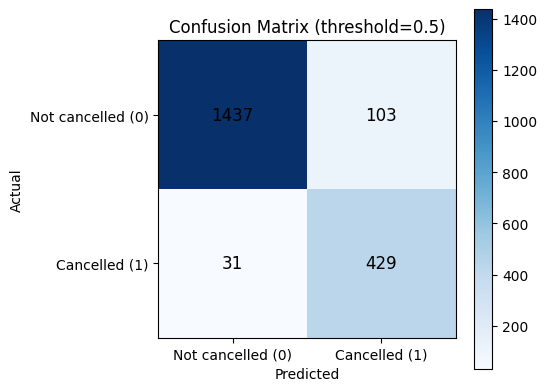


=== Confusion Counts ===


,TN,FP,FN,TP
0,1437,103,31,429


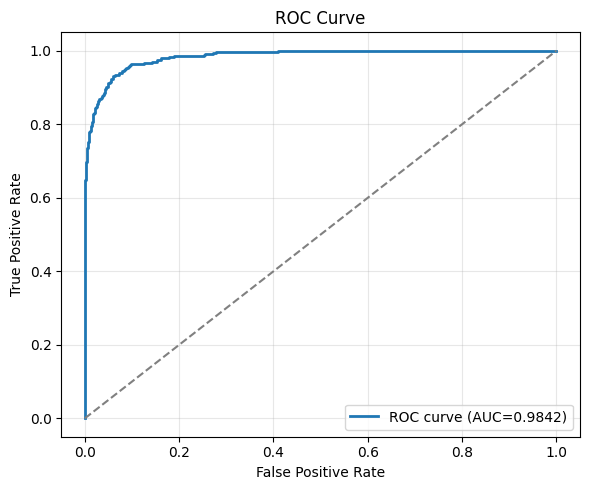

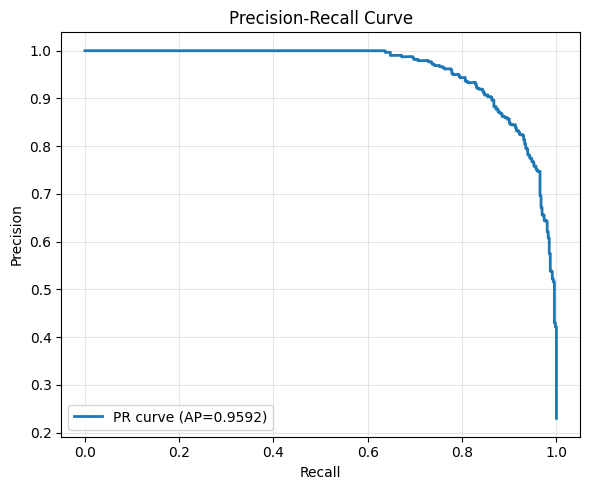


=== Risk Deciles (Top-risk first) ===


,decile,n,cancelled_rate,avg_proba
9,9,200,1.00,0.998957
8,8,200,0.87,0.950790
7,7,200,0.35,0.579862
6,6,200,0.05,0.171669
5,5,200,0.02,0.046776
4,4,200,0.01,0.015656
3,3,200,0.00,0.005261
2,2,200,0.00,0.001886
1,1,200,0.00,0.000699
0,0,200,0.00,0.000190


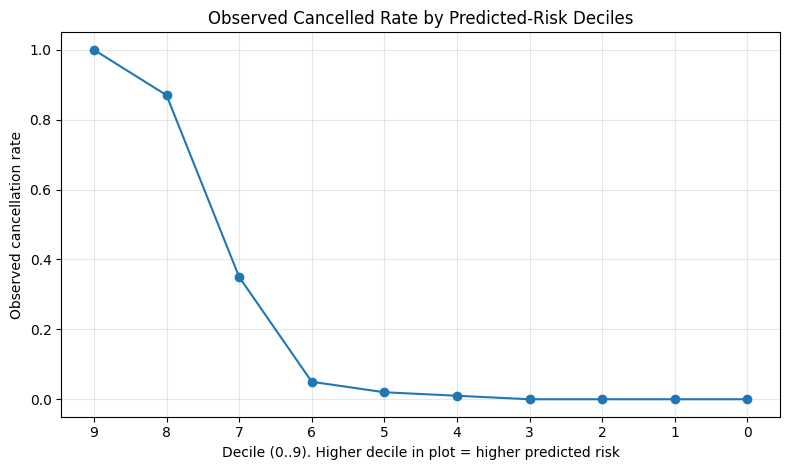

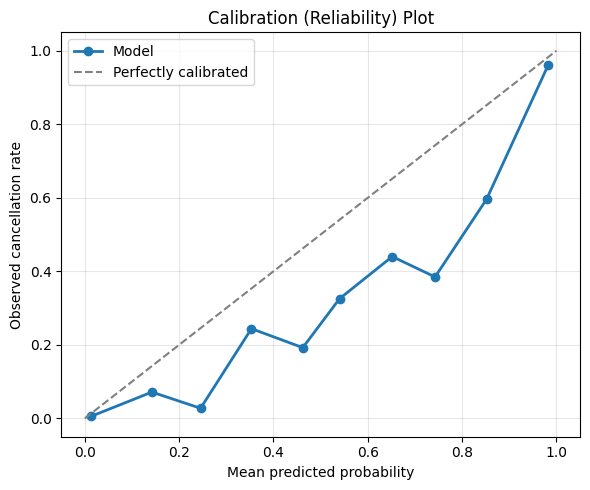


=== Additional Calibration Metric ===


,Brier score (lower is better)
0,0.04774


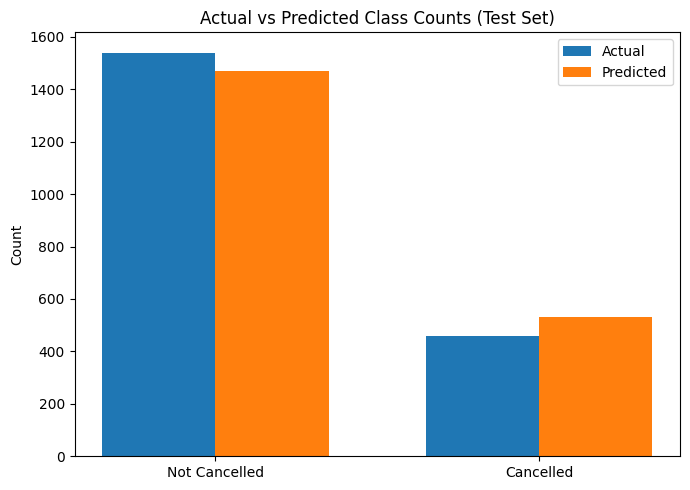

In [10]:
# -----------------------------
# 4) Baseline model: Logistic Regression (L2 + balanced class_weight)
# -----------------------------
# Hyperparameters (pragmatic defaults; you can tune C later)
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

# -----------------------------
# 5) Fit
# -----------------------------
clf.fit(X_train, y_train)

# -----------------------------
# 6) Predict + evaluate
# -----------------------------
# Use probability for ranking metrics and threshold selection.
y_proba = clf.predict_proba(X_test)[:, 1]

# Default threshold 0.5 for classification metrics
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

mcc = matthews_corrcoef(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

results = pd.DataFrame([{
    "Model": "LogisticRegression (L2, class_weight=balanced)",
    "Threshold": threshold,
    "MCC": mcc,
    "Recall (cancelled=1)": recall,
    "F1 (cancelled=1)": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}])

print("\n=== Performance Summary ===")
results_display = results.copy()
display(results_display)

# -----------------------------
# 7) Confusion Matrix plot
# -----------------------------
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (threshold=0.5)")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Not cancelled (0)", "Cancelled (1)"], rotation=0)
plt.yticks(tick_marks, ["Not cancelled (0)", "Cancelled (1)"])

# Annotate counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12, color="black")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Also show a table of confusion counts in Colab
conf_table = pd.DataFrame([{
    "TN": tn, "FP": fp, "FN": fn, "TP": tp
}])
print("\n=== Confusion Counts ===")
display(conf_table)

# -----------------------------
# 8) Curves: ROC and Precision-Recall
# -----------------------------
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC={roc_auc_val:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc_val = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR curve (AP={pr_auc_val:.4f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 9) Risk deciles / lift chart (operational usefulness)
# -----------------------------
# Sort by predicted probability and compute realized cancel rate per decile.
test_df = X_test.copy()
test_df["y_true"] = y_test
test_df["y_proba"] = y_proba

# Create deciles (10 bins). Handle duplicates in quantiles safely.
test_df["decile"] = pd.qcut(test_df["y_proba"], 10, labels=False, duplicates="drop")

decile_summary = (
    test_df.groupby("decile")
    .agg(
        n=("y_true", "size"),
        cancelled_rate=("y_true", "mean"),
        avg_proba=("y_proba", "mean")
    )
    .reset_index()
    .sort_values("decile", ascending=False)  # high-risk decile first
)

print("\n=== Risk Deciles (Top-risk first) ===")
display(decile_summary)

plt.figure(figsize=(8, 4.8))
plt.plot(
    np.arange(len(decile_summary)),
    decile_summary["cancelled_rate"].values,
    marker="o"
)
plt.xticks(np.arange(len(decile_summary)), decile_summary["decile"].astype(str).values, rotation=0)
plt.xlabel("Decile (0..9). Higher decile in plot = higher predicted risk")
plt.ylabel("Observed cancellation rate")
plt.title("Observed Cancelled Rate by Predicted-Risk Deciles")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 10) Calibration plot (simple reliability curve)
# -----------------------------
# Bin predicted probabilities and compare mean predicted vs observed.
n_bins = 10
bins = np.linspace(0.0, 1.0, n_bins + 1)
bin_ids = np.digitize(test_df["y_proba"], bins) - 1
bin_ids = np.clip(bin_ids, 0, n_bins - 1)

calib = (
    test_df.assign(bin=bin_ids)
    .groupby("bin")
    .agg(
        count=("y_true", "size"),
        mean_pred=("y_proba", "mean"),
        frac_pos=("y_true", "mean"),
    )
    .reset_index()
    .sort_values("mean_pred")
)

plt.figure(figsize=(6, 5))
plt.plot(calib["mean_pred"], calib["frac_pos"], marker="o", linewidth=2, label="Model")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed cancellation rate")
plt.title("Calibration (Reliability) Plot")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Brier score (lower is better)
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, y_proba)
print("\n=== Additional Calibration Metric ===")
calib_table = pd.DataFrame([{"Brier score (lower is better)": brier}])
display(calib_table)


# -------------------------
# 14. Actual vs predicted class-count bar chart
# -------------------------
actual_counts = pd.Series(y_test).value_counts().reindex([0, 1], fill_value=0)
pred_counts = pd.Series(y_pred).value_counts().reindex([0, 1], fill_value=0)

labels = ["Not Cancelled", "Cancelled"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, actual_counts.values, width=width, label="Actual")
ax.bar(x + width/2, pred_counts.values, width=width, label="Predicted")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Count")
ax.set_title("Actual vs Predicted Class Counts (Test Set)")
ax.legend()
plt.tight_layout()
plt.show()


#<font color='red'>**Chapter 10D. Interpret the Results**

In [ ]:
prompt_interpret_BL_model=f"""
based on these metrics results

{roc_auc},{pr_auc},{cm},{conf_table},{y_proba},{y_pred},{mcc},{recall},{f1},{results},{roc_auc_val},{pr_auc_val}

Give concise model interpretation and recommendations for improvement.
"""
response_interpret_BL_model = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_interpret_BL_model
)
print('\n=== LLM response ===')
print(response_interpret_BL_model.output_text)



=== LLM response ===
### Model interpretation (based on the metrics)
- **Overall performance is strong:**  
  - **ROC-AUC = 0.984** and **PR-AUC = 0.959** indicate excellent discrimination between cancelled vs non-cancelled.
- **Good balance of errors:**  
  - Confusion matrix **TN=1437, FP=103, FN=31, TP=429** → the model is **more accurate at identifying cancelled** than non-cancelled (only **31 FN** vs **103 FP**).
- **Classification quality for “cancelled=1”:**  
  - **Recall = 0.933** (most cancelled cases are caught)  
  - **Precision/F1 = 0.865** (when it predicts cancelled, it’s correct ~86.5% of the time)
- **MCC = 0.825** supports that this isn’t just good by chance; the separation is substantial.

### Recommendations to improve
1. **Reduce false positives (FP=103) if operational cost is high for unnecessary cancellations/alerts**
   - Try **increasing the decision threshold above 0.5** (e.g., evaluate 0.6, 0.7…) to improve precision while keeping recall acceptable.
2. **Try

#<font color='red'> **Chapter 10E. Interpret the Plots**

In [ ]:
prompt_interpret_BL_plot=f"""
Give concise model interpretation and recommendations for improvement based on below plot.

# -----------------------------
# 8) Curves: ROC and Precision-Recall
# -----------------------------
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC={roc_auc_val:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


"""
response_interpret_BL_plot = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_interpret_BL_plot
)
print('\n=== LLM response ===')
print(response_interpret_BL_plot.output_text)


=== LLM response ===
### Concise interpretation
- The PR curve is **very strong** (high **Average Precision / AP ≈ 0.9592**), indicating the model maintains **high precision even at high recall**.
- This generally suggests the model **separates positives well from negatives**, which is especially valuable if the dataset is **class-imbalanced**.

### Recommendations to improve / validate
1. **Choose an operating threshold** (not just curve quality): pick a threshold that optimizes for your goal (e.g., max F1, or fixed recall/precision). Report results at that threshold.
2. **Check performance across thresholds** with a metric table: Precision, Recall, F1, and (if relevant) PR@K or Recall at Precision≥X.
3. **Validate robustness**: use **cross-validation** or a held-out test set; confirm AP ≈ 0.96 holds consistently (not just one split).
4. **Calibrate probabilities** (optional but helpful): if you rely on predicted probabilities, apply **Platt scaling / isotonic regression** and re-che

#**Chapter 10F. Encoding are tansformed correctly**

In [ ]:
# ============================================================
# CHECK 1: ORDINAL ENCODING
# ============================================================

# Get the fitted preprocessor from the fitted pipeline
fitted_preprocessor = clf.named_steps["preprocessor"]

# Get the fitted ordinal encoder
fitted_ordinal = fitted_preprocessor.named_transformers_["ord"]

print("=== ORDINAL ENCODING ===")

for col, categories in zip(
    ordinal_cols,
    fitted_ordinal.categories_
):
    print(f"\n{col}")

    for code, category in enumerate(categories):
        print(f"  {category} -> {code}")


# ============================================================
# CHECK 2: ONE-HOT ENCODING
# ============================================================

fitted_onehot = fitted_preprocessor.named_transformers_["nominal_cat"]

print("=== ONE-HOT ENCODING ===")

for col, categories in zip(
    nominal_categorical_cols,
    fitted_onehot.categories_
):
    print(f"\n{col}:")
    print(categories)

onehot_feature_names = fitted_onehot.get_feature_names_out(
    nominal_categorical_cols
)

print("\n=== ONE-HOT ENCODED FEATURES ===")

for feature in onehot_feature_names:
    print(feature)

# ============================================================
# CHECK 3: FULL DATA AFTER PREPROCESSING
# ============================================================

X_train_encoded = fitted_preprocessor.transform(X_train)

# Get final feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# OneHotEncoder may produce a sparse matrix
if hasattr(X_train_encoded, "toarray"):
    X_train_encoded = X_train_encoded.toarray()

# Convert to DataFrame for inspection
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=feature_names,
    index=X_train.index
)

print("=== DATA AFTER ENCODING ===")

display(X_train_encoded_df.head())

# ============================================================
# CHECK 4: VERIFY ALL FEATURES ARE NUMERIC
# ============================================================

non_numeric_cols = X_train_encoded_df.select_dtypes(
    exclude=np.number
).columns.tolist()

if len(non_numeric_cols) == 0:
    print("✓ PASS: All features are numeric after preprocessing.")
else:
    print("✗ FAIL: Non-numeric features found:")
    print(non_numeric_cols)



=== ORDINAL ENCODING ===

traffic_level
  Low -> 0
  Medium -> 1
  High -> 2
  Severe -> 3

loyalty_tier
  NA -> 0
  Silver -> 1
  Gold -> 2
  Platinum -> 3
=== ONE-HOT ENCODING ===

day_of_week:
['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']

pickup_zone:
['Ang Mo Kio' 'Bukit Timah' 'CBD' 'Changi' 'Clementi' 'Jurong East'
 'Marina Bay' 'Orchard' 'Punggol' 'Queenstown' 'Sentosa' 'Serangoon'
 'Tampines' 'Woodlands' 'Yishun']

dropoff_zone:
['Ang Mo Kio' 'Bukit Timah' 'CBD' 'Changi' 'Clementi' 'Jurong East'
 'Marina Bay' 'Orchard' 'Punggol' 'Queenstown' 'Sentosa' 'Serangoon'
 'Tampines' 'Woodlands' 'Yishun']

vehicle_type:
['GrabCar' 'GrabCar Plus' 'GrabFamily' 'GrabShare' 'JustGrab']

payment_method:
['Card' 'Cash' 'Corporate' 'GrabPay']

customer_segment:
['High Value' 'New' 'Occasional' 'Regular']

weather:
['Clear' 'Cloudy' 'Heavy Rain' 'Light Rain']

app_version:
['Current' 'One version behind' 'Outdated']

network_quality:
['Average' 'Good' 'Poor']

=== ON

,traffic_level,loyalty_tier,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,pickup_zone_Ang Mo Kio,...,nearby_driver_count,drivers_declined_before_accept,driver_acceptance_time_sec,driver_distance_to_pickup_km,driver_eta_min,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd
7871,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,1.0,61.0,0.88,5.4,1.25,0.0,0.0,0.0,28.55
4561,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,1.0,57.0,1.01,4.0,1.23,0.0,0.0,0.0,7.50
3829,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,2.0,65.0,3.50,8.2,1.28,0.0,0.0,0.0,20.19
7187,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,9.0,0.0,6.0,1.90,5.3,1.00,0.0,1.0,3.0,11.37
9759,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,14.0,0.0,19.0,1.60,4.2,1.00,0.0,0.0,0.0,10.72


✓ PASS: All features are numeric after preprocessing.


In [ ]:
prompt_interpret_BL_plot2=f"""
Give concise model interpretation and recommendations for improvement based on below plot.

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc_val = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR curve (AP={pr_auc_val:.4f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


"""
response_interpret_BL_plot2 = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_interpret_BL_plot2
)
print('\n=== LLM response ===')
print(response_interpret_BL_plot2.output_text)


=== LLM response ===
### Model interpretation (from the PR plot)
- The **area under the PR curve (AP ≈ 0.959)** is very high, indicating the model is **highly effective at retrieving the positive class** while maintaining strong precision across a wide range of recall values.
- The curve staying close to the **top-right** implies **low false positives** at useful recall levels.

### Recommendations to improve / validate
1. **Check performance at specific operating points**
   - Choose a threshold that balances **precision vs recall** according to your use case (e.g., maximize F1, or prioritize precision to reduce false alarms).
2. **Validate with threshold tuning**
   - Recompute PR (or precision/recall, F1) over thresholds on a validation set; ensure the chosen threshold generalizes to test data.
3. **Assess beyond PR curve**
   - Also report **confusion matrix metrics**, **ROC-AUC**, and **F1 / Fβ score** at the selected threshold.
4. **Confirm robustness**
   - Use **cross-validati

#<font color='purple'>**Chapter 11A. Train 3 models GridSearchCV** - 20 mins

In [ ]:
# ============================================================
# CLASSIFICATION TRAINING + GRIDSEARCHCV
# ============================================================
# Models:
# 1. Logistic Regression
# 2. XGBoost
# 3. Random Forest
#
# Tuning:
# - GridSearchCV
# - 5-fold Stratified Cross-Validation
#
# Primary tuning metric:
# - PR-AUC (average_precision)
#
# Final evaluation metrics:
# - MCC
# - Recall
# - F1
# - ROC-AUC
# - PR-AUC
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    matthews_corrcoef,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from xgboost import XGBClassifier


# ============================================================
# 2. SETTINGS
# ============================================================
RANDOM_STATE = 42
TARGET = "customer_cancelled"

# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================
X = df.drop(columns=[TARGET])
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

# ============================================================
# 4. PREPROCESSING
# ============================================================
ordinal_categories = []

for col in ordinal_cols:

    if col == "traffic_level":

        # Low < Medium < High < Severe
        ordinal_categories.append(
            ["Low", "Medium", "High", "Severe"]
        )

    elif col == "loyalty_tier":

        # NA < Silver < Gold < Platinum
        ordinal_categories.append(
            ["NA", "Silver", "Gold", "Platinum"]
        )

    else:

        raise ValueError(
            f"Unexpected ordinal feature: {col}"
        )


ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)


onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)


preprocessor = ColumnTransformer(
    transformers=[

        (
            "ord",
            ordinal_encoder,
            ordinal_cols
        ),

        (
            "nominal_cat",
            onehot_encoder,
            nominal_categorical_cols
        ),

        (
            "num",
            "passthrough",
            numeric_cols
        )

    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ============================================================
# 5. EVALUATION FUNCTION
# ============================================================
def get_thresholded_metrics(
    y_true,
    y_proba,
    threshold=0.5
):

    # Convert predicted probability into 0/1 prediction
    y_pred = (
        y_proba >= threshold
    ).astype(int)


    # Threshold-based metrics
    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )


    # Probability-based metrics
    roc_auc = roc_auc_score(
        y_true,
        y_proba
    )

    pr_auc = average_precision_score(
        y_true,
        y_proba
    )


    return {

        "MCC": mcc,

        "Recall": recall,

        "F1": f1,

        "ROC_AUC": roc_auc,

        "PR_AUC": pr_auc
    }

# ============================================================
# 6. PRIMARY GRIDSEARCH METRIC
# ============================================================
# PR-AUC is appropriate when the positive class
# (customer cancellation = 1) is the main class of interest.

CV_SCORING = "average_precision"

# ============================================================
# 7. STRATIFIED 5-FOLD CV
# ============================================================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ============================================================
# 8. LOGISTIC REGRESSION
# ============================================================
logreg = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)


logreg_pipe = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "clf",
            logreg
        )

    ]
)

# 5 combinations
logreg_param_grid = {

    "clf__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ]

}

# ============================================================
# 9. XGBOOST
# ============================================================
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_pipe = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "clf",
            xgb
        )

    ]
)


# Smaller GridSearchCV search space
#
# 2 × 2 × 2 × 2 × 2
# = 32 combinations
#
# 32 × 5-fold CV
# = 160 model fits

# xgb_param_grid = {

#     "clf__n_estimators": [
#         300,
#         500
#     ],

#     "clf__learning_rate": [
#         0.05,
#         0.10
#     ],

#     "clf__max_depth": [
#         3,
#         5
#     ],

#     "clf__subsample": [
#         0.8,
#         1.0
#     ],

#     "clf__colsample_bytree": [
#         0.8,
#         1.0
#     ]

# }

# ============================================================
# Full GridSearchCV search space
#
# 3 × 3 × 3 × 3 × 2 × 2
# = 324 parameter combinations
#
# 324 × 5-fold CV
# = 1,620 model fits
# ============================================================
# xgb_param_grid = {
#     "clf__n_estimators": [200, 400, 600],          # 3
#     "clf__learning_rate": [0.03, 0.05, 0.10],     # 3
#     "clf__max_depth": [3, 5, 7],                   # 3
#     "clf__min_child_weight": [1, 3, 5],            # 3
#     "clf__subsample": [0.8, 1.0],                  # 2
#     "clf__colsample_bytree": [0.8, 1.0]            # 2
# }

# ============================================================
# Medium GridSearchCV search space
#
# 3 × 3 × 2 × 2 × 2 = 72 parameter combinations
# 72 × 5-fold CV = 360 model fits
# ============================================================
xgb_param_grid = {
    "clf__n_estimators": [200, 400, 600],      # 3
    "clf__learning_rate": [0.03, 0.05, 0.10],  # 3
    "clf__max_depth": [3, 5],                  # 2
    "clf__min_child_weight": [1, 3],           # 2
    "clf__subsample": [0.8, 1.0]               # 2
}

# ============================================================
# 10. RANDOM FOREST
# ============================================================
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)


rf_pipe = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "clf",
            rf
        )

    ]
)


# Reduced grid for reasonable runtime
#
# 2 × 3 × 2 × 3 × 1
# = 36 combinations
#
# 36 × 5-fold CV
# = 180 model fits

rf_param_grid = {

    "clf__n_estimators": [
        300,
        500
    ],

    "clf__max_depth": [
        None,
        10,
        20
    ],

    "clf__min_samples_split": [
        2,
        5
    ],

    "clf__min_samples_leaf": [
        1,
        5,
        10
    ],

    "clf__max_features": [
        "sqrt"
    ]

}


# ============================================================
# 11. GRIDSEARCHCV FUNCTION
# ============================================================
def run_grid_search_and_evaluate(
    pipe,
    param_grid,
    model_name,
    threshold=0.5
):

    print("\n" + "=" * 60)
    print(f"MODEL: {model_name}")
    print("=" * 60)
    # --------------------------------------------------------
    # GridSearchCV
    # --------------------------------------------------------
    grid_search = GridSearchCV(

        estimator=pipe,

        param_grid=param_grid,

        scoring=CV_SCORING,

        cv=cv,

        n_jobs=-1,

        verbose=1,

        refit=True,

        return_train_score=False

    )

    # --------------------------------------------------------
    # IMPORTANT:
    # GridSearchCV is performed ONLY on training data
    # --------------------------------------------------------
    grid_search.fit(
        X_train,
        y_train
    )

    # --------------------------------------------------------
    # Best model according to CV PR-AUC
    # --------------------------------------------------------
    best_model = grid_search.best_estimator_

    print(
        f"\n[{model_name}] Best Parameters:"
    )

    print(
        grid_search.best_params_
    )

    print(
        f"\n[{model_name}] "
        f"Best CV PR-AUC: "
        f"{grid_search.best_score_:.4f}"
    )

    # --------------------------------------------------------
    # Evaluate best tuned model on untouched test set
    # --------------------------------------------------------
    y_test_proba = best_model.predict_proba(
        X_test
    )[:, 1]


    test_metrics = get_thresholded_metrics(

        y_true=y_test,

        y_proba=y_test_proba,

        threshold=threshold

    )

    print(
        f"\n[{model_name}] "
        f"Holdout Test Metrics "
        f"@ threshold={threshold}"
    )

    for metric_name, value in test_metrics.items():

        print(
            f"{metric_name}: {value:.4f}"
        )

    return (
        best_model,
        test_metrics,
        grid_search
    )

# ============================================================
# 12. TRAIN LOGISTIC REGRESSION
# ============================================================
best_lr, m_lr, search_lr = (
    run_grid_search_and_evaluate(

        logreg_pipe,

        logreg_param_grid,

        "Logistic Regression",

        threshold=0.5
    )
)

# ============================================================
# 13. TRAIN XGBOOST
# ============================================================
best_xgb, m_xgb, search_xgb = (
    run_grid_search_and_evaluate(

        xgb_pipe,

        xgb_param_grid,

        "XGBoost",

        threshold=0.5
    )
)

# ============================================================
# 14. TRAIN RANDOM FOREST
# ============================================================
best_rf, m_rf, search_rf = (
    run_grid_search_and_evaluate(

        rf_pipe,

        rf_param_grid,

        "Random Forest",

        threshold=0.5
    )
)

# ============================================================
# 15. CREATE TEST RESULTS SUMMARY
# ============================================================
test_results = {

    "LogisticRegression": m_lr,

    "XGBoost": m_xgb,

    "RandomForest": m_rf

}

test_summary = pd.DataFrame(
    test_results
).T

print(
    "\n=========================================="
)

print(
    "HOLDOUT TEST SET RESULTS"
)

print(
    "=========================================="
)

display(
    test_summary.round(4)
)

# ============================================================
# 16. CV RESULTS FOR MODEL SELECTION
# ============================================================
# IMPORTANT:
# We select the model using CV performance,
# NOT test-set performance.
#
# This keeps the test set independent.

cv_results = pd.DataFrame({

    "Model": [

        "LogisticRegression",

        "XGBoost",

        "RandomForest"

    ],

    "CV_PR_AUC": [

        search_lr.best_score_,

        search_xgb.best_score_,

        search_rf.best_score_

    ]

})


cv_results = cv_results.sort_values(

    by="CV_PR_AUC",

    ascending=False

).reset_index(drop=True)


print(
    "\n=========================================="
)

print(
    "MODEL SELECTION BASED ON CV PR-AUC"
)

print(
    "=========================================="
)


display(
    cv_results.round(4)
)


# ============================================================
# 17. SELECT BEST MODEL
# ============================================================

best_name = cv_results.loc[
    0,
    "Model"
]


print(
    f"\nSelected Best Model: {best_name}"
)


print(
    f"Best CV PR-AUC: "
    f"{cv_results.loc[0, 'CV_PR_AUC']:.4f}"
)


# ============================================================
# 18. GET BEST MODEL OBJECT
# ============================================================
best_models = {

    "LogisticRegression": best_lr,

    "XGBoost": best_xgb,

    "RandomForest": best_rf

}


final_model = best_models[
    best_name
]
print(
    f"\nFinal model object stored as: final_model"
)


# ============================================================
# 19. SHOW FINAL MODEL'S TEST PERFORMANCE
# ============================================================
print(
    "\n=========================================="
)

print(
    f"FINAL TEST PERFORMANCE: {best_name}"
)

print(
    "=========================================="
)

display(
    test_summary.loc[[best_name]].round(4)
)

Training samples: 8000
Test samples: 2000

MODEL: Logistic Regression
Fitting 5 folds for each of 5 candidates, totalling 25 fits

[Logistic Regression] Best Parameters:
{'clf__C': 100}

[Logistic Regression] Best CV PR-AUC: 0.9466

[Logistic Regression] Holdout Test Metrics @ threshold=0.5
MCC: 0.8191
Recall: 0.9174
F1: 0.8612
ROC_AUC: 0.9844
PR_AUC: 0.9595

MODEL: XGBoost
Fitting 5 folds for each of 72 candidates, totalling 360 fits

[XGBoost] Best Parameters:
{'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 3, 'clf__n_estimators': 600, 'clf__subsample': 0.8}

[XGBoost] Best CV PR-AUC: 0.9530

[XGBoost] Holdout Test Metrics @ threshold=0.5
MCC: 0.8540
Recall: 0.8652
F1: 0.8864
ROC_AUC: 0.9851
PR_AUC: 0.9616

MODEL: Random Forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits

[Random Forest] Best Parameters:
{'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 500}


,MCC,Recall,F1,ROC_AUC,PR_AUC
LogisticRegression,0.8191,0.9174,0.8612,0.9844,0.9595
XGBoost,0.8540,0.8652,0.8864,0.9851,0.9616
RandomForest,0.8043,0.8022,0.8454,0.9765,0.9358



MODEL SELECTION BASED ON CV PR-AUC


,Model,CV_PR_AUC
0,XGBoost,0.9530
1,LogisticRegression,0.9466
2,RandomForest,0.9210



Selected Best Model: XGBoost
Best CV PR-AUC: 0.9530

Final model object stored as: final_model

FINAL TEST PERFORMANCE: XGBoost


,MCC,Recall,F1,ROC_AUC,PR_AUC
XGBoost,0.854,0.8652,0.8864,0.9851,0.9616


#<font color='purple'>**Chapter 11B. Train 3 models without RandomizedSearchCV**

In [ ]:
# ============================================================
# 1. TARGET AND TRAIN / TEST SPLIT
# ============================================================

TARGET = "customer_cancelled"

X = df.drop(columns=[TARGET])
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)


# ============================================================
# 2. PREPROCESSING
# ============================================================

ordinal_categories = []

for col in ordinal_cols:
    if col == "traffic_level":
        ordinal_categories.append(
            ["Low", "Medium", "High", "Severe"]
        )

    elif col == "loyalty_tier":
        # Increasing order:
        # NA < Silver < Gold < Platinum
        ordinal_categories.append(
            ["NA", "Silver", "Gold", "Platinum"]
        )

    else:
        raise ValueError(f"Unexpected ordinal feature: {col}")


ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)


onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)


preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, ordinal_cols),
        ("nominal_cat", onehot_encoder, nominal_categorical_cols),
        ("num", "passthrough", numeric_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


# ============================================================
# 3. METRIC FUNCTION
# ============================================================

def get_thresholded_metrics(
    y_true,
    y_proba,
    threshold=0.5
):
    """
    MCC and F1 require predicted classes.
    ROC-AUC and PR-AUC use predicted probabilities.
    """

    y_pred = (y_proba >= threshold).astype(int)

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )
    # Recall
    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )
    roc = roc_auc_score(
        y_true,
        y_proba
    )

    pr = average_precision_score(
        y_true,
        y_proba
    )

    return {
        "MCC": mcc,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc,
        "PR_AUC": pr
    }


# ============================================================
# 4. CV STRATEGY
# ============================================================

CV_SCORING = "average_precision"

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ============================================================
# 5. MODELS
# ============================================================


# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)


logreg_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", logreg)
    ]
)


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)


xgb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", xgb)
    ]
)


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", rf)
    ]
)


# ============================================================
# 6. HELPER FUNCTION
# Run 5-fold CV, fit full training set, evaluate holdout
# ============================================================

def run_cv_and_evaluate(
    pipe,
    model_name,
    threshold=0.5
):

    # --------------------------------------------------------
    # Cross-validation on TRAINING data only
    # --------------------------------------------------------

    cv_scores = cross_val_score(
        estimator=pipe,
        X=X_train,
        y=y_train,
        scoring=CV_SCORING,
        cv=cv,
        n_jobs=-1
    )

    print(f"\n[{model_name}]")

    print(
        f"[{model_name}] CV PR-AUC scores: "
        f"{np.round(cv_scores, 4)}"
    )

    print(
        f"[{model_name}] Mean CV PR-AUC: "
        f"{cv_scores.mean():.6f}"
    )

    print(
        f"[{model_name}] CV PR-AUC Std: "
        f"{cv_scores.std():.6f}"
    )


    # --------------------------------------------------------
    # Fit model using ALL training data
    # --------------------------------------------------------

    pipe.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # Holdout test evaluation
    # --------------------------------------------------------

    y_test_proba = pipe.predict_proba(
        X_test
    )[:, 1]


    metrics = get_thresholded_metrics(
        y_test,
        y_test_proba,
        threshold=threshold
    )


    # Add CV results to metrics dictionary

    metrics["CV_PR_AUC_Mean"] = cv_scores.mean()
    metrics["CV_PR_AUC_Std"] = cv_scores.std()


    print(
        f"\n[{model_name}] "
        f"Test metrics @ threshold={threshold}:"
    )

    for k, v in metrics.items():
        print(
            f"  - {k}: {v:.6f}"
        )


    return pipe, metrics, cv_scores


# ============================================================
# 7. TRAIN / CROSS-VALIDATE / EVALUATE
# ============================================================

results = {}


# Logistic Regression

best_lr, m_lr, cv_lr = run_cv_and_evaluate(
    logreg_pipe,
    "LogisticRegression",
    threshold=0.5
)


# XGBoost

best_xgb, m_xgb, cv_xgb = run_cv_and_evaluate(
    xgb_pipe,
    "XGB",
    threshold=0.5
)


# Random Forest

best_rf, m_rf, cv_rf = run_cv_and_evaluate(
    rf_pipe,
    "RandomForest",
    threshold=0.5
)


# ============================================================
# 8. SAVE RESULTS
# ============================================================

results["LogisticRegression"] = m_lr
results["XGB"] = m_xgb
results["RandomForest"] = m_rf


# ============================================================
# 9. SUMMARY TABLE
# ============================================================

print("\n=== Summary ===")

summary = pd.DataFrame(results).T

display(summary)


# ============================================================
# 10. BEST MODEL BY HOLDOUT TEST PR-AUC
# ============================================================

best_name = summary["PR_AUC"].idxmax()

print(
    f"\nBest model by Test PR-AUC: "
    f"{best_name}"
)


[LogisticRegression]
[LogisticRegression] CV PR-AUC scores: [0.9452 0.9428 0.9419 0.947  0.9443]
[LogisticRegression] Mean CV PR-AUC: 0.944240
[LogisticRegression] CV PR-AUC Std: 0.001773

[LogisticRegression] Test metrics @ threshold=0.5:
  - MCC: 0.824519
  - Recall: 0.932609
  - F1: 0.864919
  - ROC_AUC: 0.984184
  - PR_AUC: 0.959227
  - CV_PR_AUC_Mean: 0.944240
  - CV_PR_AUC_Std: 0.001773

[XGB]
[XGB] CV PR-AUC scores: [0.9472 0.9462 0.9439 0.9467 0.9504]
[XGB] Mean CV PR-AUC: 0.946897
[XGB] CV PR-AUC Std: 0.002098

[XGB] Test metrics @ threshold=0.5:
  - MCC: 0.836093
  - Recall: 0.843478
  - F1: 0.871910
  - ROC_AUC: 0.982411
  - PR_AUC: 0.954478
  - CV_PR_AUC_Mean: 0.946897
  - CV_PR_AUC_Std: 0.002098

[RandomForest]
[RandomForest] CV PR-AUC scores: [0.924  0.9144 0.9221 0.9151 0.9231]
[RandomForest] Mean CV PR-AUC: 0.919738
[RandomForest] CV PR-AUC Std: 0.004112

[RandomForest] Test metrics @ threshold=0.5:
  - MCC: 0.788325
  - Recall: 0.771739
  - F1: 0.830409
  - ROC_AUC: 0

,MCC,Recall,F1,ROC_AUC,PR_AUC,CV_PR_AUC_Mean,CV_PR_AUC_Std
LogisticRegression,0.824519,0.932609,0.864919,0.984184,0.959227,0.944240,0.001773
XGB,0.836093,0.843478,0.871910,0.982411,0.954478,0.946897,0.002098
RandomForest,0.788325,0.771739,0.830409,0.975675,0.933245,0.919738,0.004112



Best model by Test PR-AUC: LogisticRegression


#<font color='purple'>**Chapter 11C. Train 3 Models with RandomizedSearchCV - 45min**

Fitting 5 folds for each of 20 candidates, totalling 100 fits

[LogisticRegression] Best params: {'clf__C': np.float64(56.69849511478853)}
[LogisticRegression] Best CV PR-AUC: 0.946623
[LogisticRegression] Test metrics @ threshold=0.44:
  - MCC: 0.821545
  - Recall: 0.939130
  - F1: 0.862275
  - ROC_AUC: 0.984417
  - PR_AUC: 0.959474
Fitting 5 folds for each of 35 candidates, totalling 175 fits

[XGBoost] Best params: {'clf__colsample_bytree': np.float64(0.5597971229691509), 'clf__learning_rate': np.float64(0.058451252572625234), 'clf__max_depth': 2, 'clf__min_child_weight': 5, 'clf__n_estimators': 417, 'clf__reg_alpha': np.float64(0.0015132984900630335), 'clf__reg_lambda': np.float64(0.019069601332062702), 'clf__scale_pos_weight': 2.0, 'clf__subsample': np.float64(0.7613664146909971)}
[XGBoost] Best CV PR-AUC: 0.954728
[XGBoost] Test metrics @ threshold=0.44:
  - MCC: 0.841106
  - Recall: 0.923913
  - F1: 0.878099
  - ROC_AUC: 0.986285
  - PR_AUC: 0.964646
Fitting 5 folds for each of 

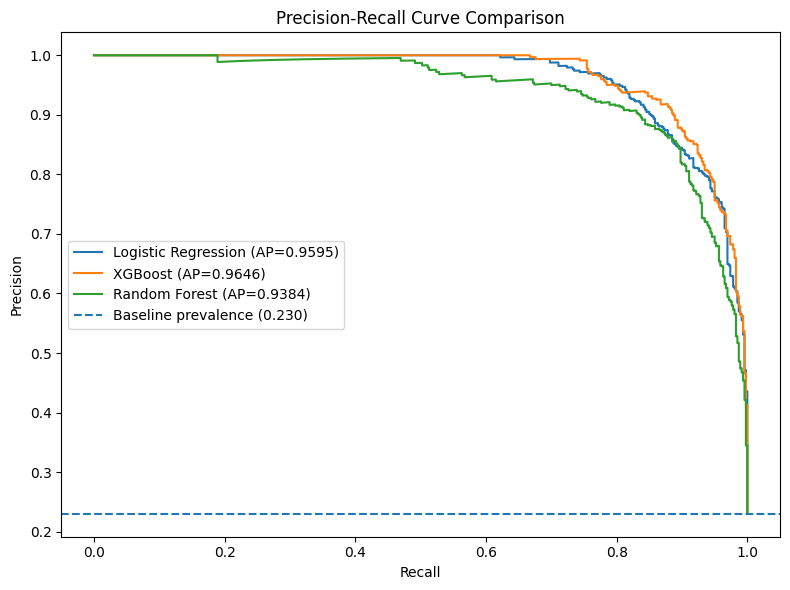

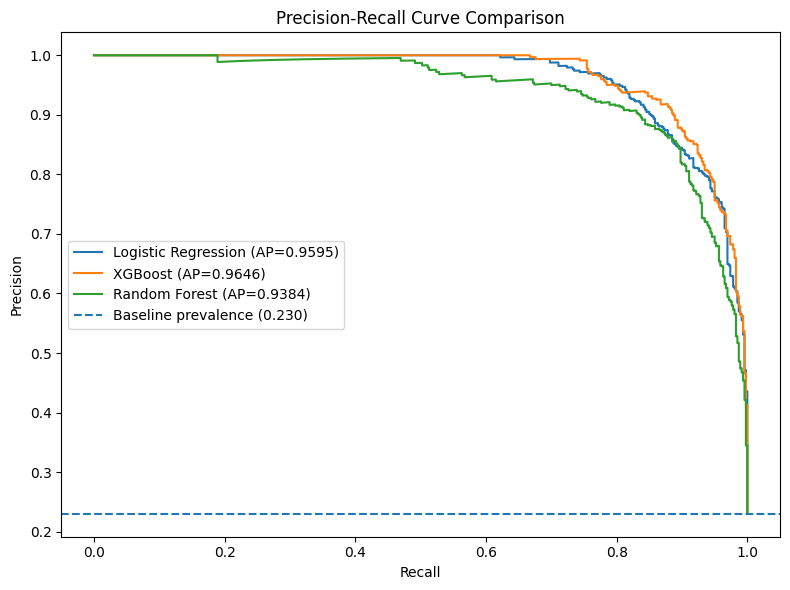

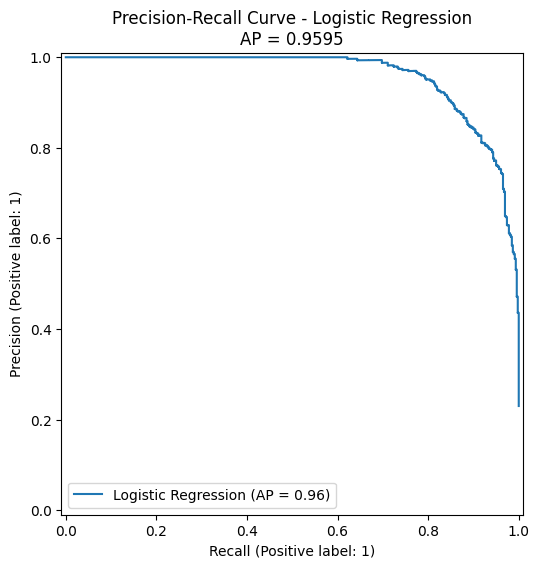

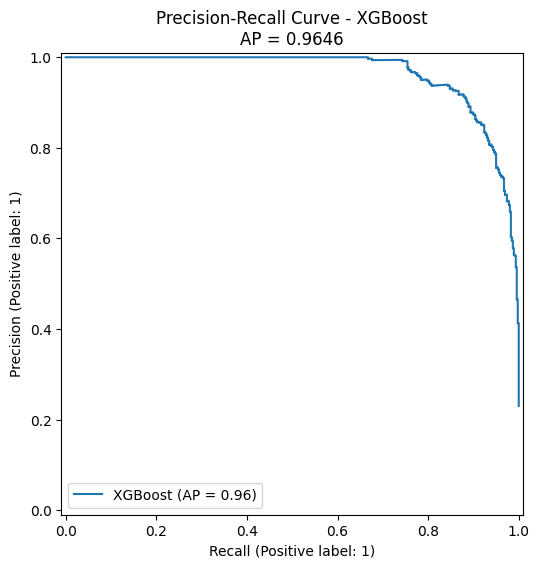

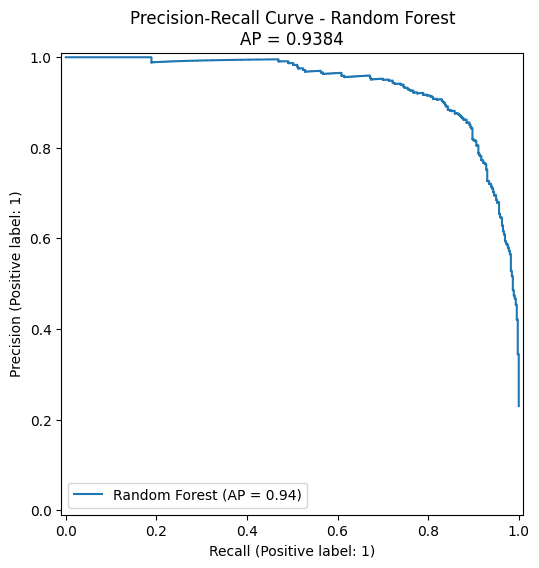


=== Summary (holdout test set) ===


,MCC,Recall,F1,ROC_AUC,PR_AUC
LogisticRegression,0.821545,0.939130,0.862275,0.984417,0.959474
XGB,0.841106,0.923913,0.878099,0.986285,0.964646
RandomForest,0.799222,0.913043,0.845921,0.976913,0.938405



Best model by Test PR-AUC: XGB


In [12]:

# Simple, executable training script:
# - Baseline: Logistic Regression (regularized, balanced)
# - XGBoost-style Gradient Boosting: XGBClassifier
# - Random Forest
# - 5-fold Stratified CV + RandomizedSearchCV
# - Metrics: MCC, F1, ROC-AUC, PR-AUC
#
# NOTE: This assumes you already have:
#   - df (pandas DataFrame)
#   - ordinal_cols, nominal_categorical_cols, numeric_cols defined
#   - (optionally) XGBoost installed: pip install xgboost

# ---------------------------
# Data
# ---------------------------
TARGET = "customer_cancelled"
X = df.drop(columns=[TARGET])
y = df[TARGET].values

# If you want to keep your original train/test split too:
# (CV below will tune on X_train; test set is final holdout evaluation)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# ---------------------------
# Preprocessing (your encoders)
# ---------------------------
ordinal_categories = []
for col in ordinal_cols:
    if col == "traffic_level":
        ordinal_categories.append(["Low", "Medium", "High", "Severe"])
    elif col == "loyalty_tier":
        # Order given: Platinum > Gold > Silver > NA
        # OrdinalEncoder maps increasing integers to increasing category order.
        ordinal_categories.append(["NA", "Silver", "Gold", "Platinum"])
    else:
        raise ValueError(f"Unexpected ordinal feature: {col}")

ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, ordinal_cols),
        ("nominal_cat", onehot_encoder, nominal_categorical_cols),
        ("num", "passthrough", numeric_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ---------------------------
# Metric function for optimization (PR-AUC used as primary)
# ---------------------------
def get_thresholded_metrics(y_true, y_proba, threshold=0.5):
    """
    MCC + F1 require a threshold.
    ROC-AUC + PR-AUC use probabilities.
    """
    y_pred = (y_proba >= threshold).astype(int)
    mcc = matthews_corrcoef(y_true, y_pred)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc = roc_auc_score(y_true, y_proba)
    pr = average_precision_score(y_true, y_proba)
    return {"MCC": mcc, "Recall": recall, "F1": f1, "ROC_AUC": roc, "PR_AUC": pr}


# We'll use PR-AUC as the CV scoring for tuning.
# RandomizedSearchCV in sklearn can take a string scoring.
CV_SCORING = "average_precision"  # PR-AUC


# ---------------------------
# CV strategy
# ---------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


# ---------------------------
# Models + hyperparameter search spaces
# ---------------------------
# Common pipeline prefix
pipe_prefix = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression())  # placeholder; overwritten per model
])

# ---- Baseline Logistic Regression ----
logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", logreg)
])

logreg_param_dist = {
    "clf__C": loguniform(1e-3, 100),
    # penalty fixed to l2 in your baseline; if you want elasticnet/l1, you must change solver.
}

# ---- XGBoost-style Gradient Boosting ----
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", xgb)
])

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_scale_pos_weight = neg / pos

xgb_param_dist = {
    "clf__n_estimators": randint(200, 1200),
    "clf__learning_rate": loguniform(1e-3, 0.3),
    "clf__max_depth": randint(2, 12),
    "clf__min_child_weight": randint(1, 30),
    "clf__subsample": uniform(0.5, 0.5),           # 0.5-1.0
    "clf__colsample_bytree": uniform(0.5, 0.5),    # 0.5-1.0
    "clf__reg_lambda": loguniform(1e-3, 100),
    "clf__reg_alpha": loguniform(1e-4, 10),
    # Important for improving minority-class detection
    "clf__scale_pos_weight": [
        1.0,
        1.5,
        2.0,
        2.5,
        3.0,
        3.35
    ]
}

# ---- Random Forest ----
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", rf)
])

rf_param_dist = {
    "clf__n_estimators": randint(200, 900),
    "clf__max_depth": [None] + list(range(5, 31)),
    "clf__min_samples_split": randint(2, 21),
    "clf__min_samples_leaf": randint(1, 51),
    "clf__max_features": uniform(0.1, 0.9),  # fraction of features
}

# ---------------------------
# Helper: run RandomizedSearchCV, then evaluate on holdout test set
# ---------------------------
# def run_search_and_evaluate(pipe, param_dist, model_name, n_iter=30, threshold=0.5):
#     search = RandomizedSearchCV(
#         estimator=pipe,
#         param_distributions=param_dist,
#         n_iter=n_iter,
#         scoring=CV_SCORING,      # PR-AUC
#         n_jobs=-1,
#         cv=cv,
#         verbose=1,
#         random_state=42
#     )

#     search.fit(X_train, y_train)

#     best_model = search.best_estimator_
#     print(f"\n[{model_name}] Best params: {search.best_params_}")
#     print(f"[{model_name}] Best CV PR-AUC: {search.best_score_:.6f}")

#     # Evaluate on holdout test set
#     y_test_proba = best_model.predict_proba(X_test)[:, 1]
#     metrics = get_thresholded_metrics(y_test, y_test_proba, threshold=threshold)

#     print(f"[{model_name}] Test metrics @ threshold={threshold}:")
#     for k, v in metrics.items():
#         print(f"  - {k}: {v:.6f}")

#     return best_model, metrics, search

def run_search_and_evaluate(
    pipe,
    param_dist,
    model_name,
    n_iter=30,
    threshold=0.44
):
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=CV_SCORING,
        n_jobs=-1,
        cv=cv,
        verbose=1,
        random_state=42
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    print(f"\n[{model_name}] Best params: {search.best_params_}")
    print(f"[{model_name}] Best CV PR-AUC: {search.best_score_:.6f}")

    # Holdout probabilities
    y_test_proba = best_model.predict_proba(X_test)[:, 1]

    # Threshold metrics
    metrics = get_thresholded_metrics(
        y_test,
        y_test_proba,
        threshold=threshold
    )

    print(f"[{model_name}] Test metrics @ threshold={threshold}:")

    for k, v in metrics.items():
        print(f"  - {k}: {v:.6f}")

    return best_model, metrics, search, y_test_proba

# ---------------------------
# Train/tune/evaluate
# ---------------------------
results = {}

# best_lr, m_lr, search_lr = run_search_and_evaluate(
#     logreg_pipe, logreg_param_dist, "LogisticRegression", n_iter=20, threshold=0.5
# )

# best_xgb, m_xgb, search_xgb = run_search_and_evaluate(
#     xgb_pipe, xgb_param_dist, "XGB (Gradient Boosting style)", n_iter=35, threshold=0.5
# )

# best_rf, m_rf, search_rf = run_search_and_evaluate(
#     rf_pipe, rf_param_dist, "RandomForest", n_iter=25, threshold=0.5
# )

best_lr, m_lr, search_lr, proba_lr = run_search_and_evaluate(
    logreg_pipe,
    logreg_param_dist,
    "LogisticRegression",
    n_iter=20,
    threshold=0.44
)

best_xgb, m_xgb, search_xgb, proba_xgb = run_search_and_evaluate(
    xgb_pipe,
    xgb_param_dist,
    "XGBoost",
    n_iter=35,
    threshold=0.44
)

best_rf, m_rf, search_rf, proba_rf = run_search_and_evaluate(
    rf_pipe,
    rf_param_dist,
    "RandomForest",
    n_iter=25,
    threshold=0.44
)


import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(
    y_test,
    proba_lr
)

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Logistic Regression (AP={m_lr['PR_AUC']:.4f})"
)

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    proba_xgb
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost (AP={m_xgb['PR_AUC']:.4f})"
)

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    proba_rf
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (AP={m_rf['PR_AUC']:.4f})"
)

# Baseline = positive class prevalence
baseline = y_test.mean()

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline prevalence ({baseline:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# PRECISION-RECALL CURVE COMPARISON
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(
    y_test,
    proba_lr
)

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Logistic Regression (AP={m_lr['PR_AUC']:.4f})"
)

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    proba_xgb
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost (AP={m_xgb['PR_AUC']:.4f})"
)

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    proba_rf
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (AP={m_rf['PR_AUC']:.4f})"
)

# Baseline = positive class prevalence
baseline = y_test.mean()

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline prevalence ({baseline:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.legend()

plt.tight_layout()
plt.show()

from sklearn.metrics import PrecisionRecallDisplay

# Logistic Regression
fig, ax = plt.subplots(figsize=(7, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    proba_lr,
    name="Logistic Regression",
    ax=ax
)

ax.set_title(
    f"Precision-Recall Curve - Logistic Regression\n"
    f"AP = {m_lr['PR_AUC']:.4f}"
)

plt.show()


# XGBoost
fig, ax = plt.subplots(figsize=(7, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    proba_xgb,
    name="XGBoost",
    ax=ax
)

ax.set_title(
    f"Precision-Recall Curve - XGBoost\n"
    f"AP = {m_xgb['PR_AUC']:.4f}"
)

plt.show()


# Random Forest
fig, ax = plt.subplots(figsize=(7, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    proba_rf,
    name="Random Forest",
    ax=ax
)

ax.set_title(
    f"Precision-Recall Curve - Random Forest\n"
    f"AP = {m_rf['PR_AUC']:.4f}"
)

plt.show()
###########################3333333333

results["LogisticRegression"] = m_lr
results["XGB"] = m_xgb
results["RandomForest"] = m_rf

print("\n=== Summary (holdout test set) ===")
summary = pd.DataFrame(results).T
display(summary)

# ---------------------------
# Optional: best model selection by PR-AUC on test
# ---------------------------
best_name = summary["PR_AUC"].idxmax()
print(f"\nBest model by Test PR-AUC: {best_name}")



#<font color='purple'> **Chapter 11D. Confusion Matrix**


=== Logistic Regression Confusion Matrix ===
Threshold: 0.44
True Positive  (TP): 432
False Negative (FN): 28
False Positive (FP): 110
True Negative  (TN): 1430

=== Classification Metrics ===
Recall:    0.9391
Precision: 0.7970
F1 Score:  0.8623


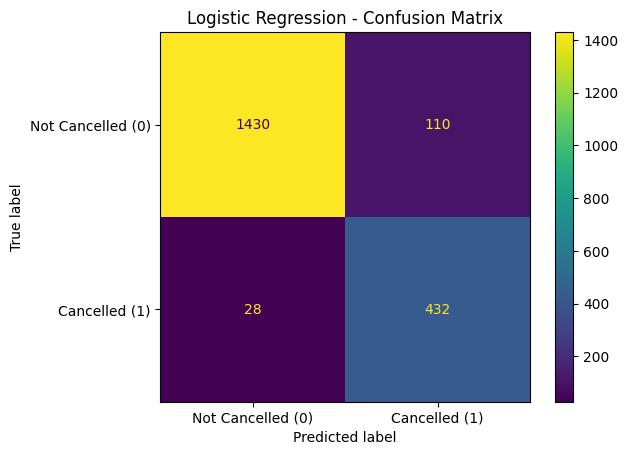


=== XGBoost Confusion Matrix ===
Threshold: 0.44
True Positive  (TP): 425
False Negative (FN): 35
False Positive (FP): 83
True Negative  (TN): 1457

=== Classification Metrics ===
Recall:    0.9239
Precision: 0.8366
F1 Score:  0.8781


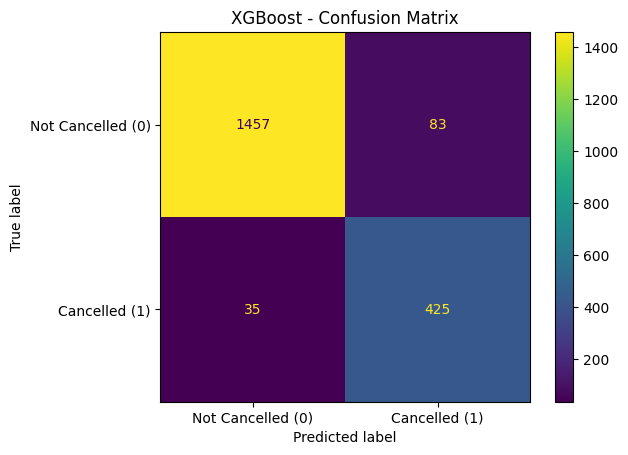


=== Random Forest Confusion Matrix ===
Threshold: 0.44
True Positive  (TP): 420
False Negative (FN): 40
False Positive (FP): 113
True Negative  (TN): 1427

=== Classification Metrics ===
Recall:    0.9130
Precision: 0.7880
F1 Score:  0.8459


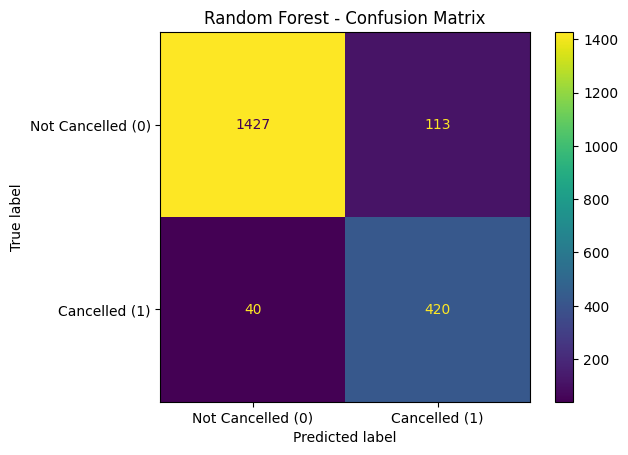

,Threshold,TP,FN,FP,TN,Recall,Precision,F1
Logistic Regression,0.44,432.0,28.0,110.0,1430.0,0.939130,0.797048,0.862275
XGBoost,0.44,425.0,35.0,83.0,1457.0,0.923913,0.836614,0.878099
Random Forest,0.44,420.0,40.0,113.0,1427.0,0.913043,0.787992,0.845921


In [22]:
# ---------------------------
# Confusion Matrix
# ---------------------------

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    precision_score,
    f1_score
)
import matplotlib.pyplot as plt


def show_confusion_matrix(model, X_test, y_test, model_name, threshold=0.5):

    # Get predicted probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # Convert probabilities to class predictions
    y_pred = (y_proba >= threshold).astype(int)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Extract TN, FP, FN, TP
    TN, FP, FN, TP = cm.ravel()

    # --------------------------------------------------------
    # Calculate Recall, Precision and F1
    # Positive class = customer_cancelled = 1
    # --------------------------------------------------------

    recall = recall_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    precision = precision_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print(f"\n=== {model_name} Confusion Matrix ===")
    print(f"Threshold: {threshold}")
    print(f"True Positive  (TP): {TP}")
    print(f"False Negative (FN): {FN}")
    print(f"False Positive (FP): {FP}")
    print(f"True Negative  (TN): {TN}")

    print("\n=== Classification Metrics ===")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Cancelled (0)", "Cancelled (1)"]
    )

    disp.plot(values_format="d")

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # --------------------------------------------------------
    # Return confusion counts + metrics
    # --------------------------------------------------------
    return {
        "Threshold": threshold,
        "TP": TP,
        "FN": FN,
        "FP": FP,
        "TN": TN,
        "Recall": recall,
        "Precision": precision,
        "F1": f1
    }


    # Logistic Regression
cm_lr = show_confusion_matrix(
    best_lr,
    X_test,
    y_test,
    "Logistic Regression",
    threshold=0.44
)

# XGBoost
cm_xgb = show_confusion_matrix(
    best_xgb,
    X_test,
    y_test,
    "XGBoost",
    threshold=0.44
)

# Random Forest
cm_rf = show_confusion_matrix(
    best_rf,
    X_test,
    y_test,
    "Random Forest",
    threshold=0.44
)

confusion_summary = pd.DataFrame({
    "Logistic Regression": cm_lr,
    "XGBoost": cm_xgb,
    "Random Forest": cm_rf
}).T

display(confusion_summary)




#<font color='purple'>**Chapter 13A. XGBoost - Feature Importance**

Number of transformed XGBoost features: 93
Number of mapped features: 93

Top 20 XGBoost Feature Importances (Original Feature Level):


,Original_Feature,Importance
0,supply_demand_ratio,0.1480
1,surge_multiplier,0.1462
2,driver_eta_min,0.0982
3,is_peak_hour,0.0641
4,weather,0.0517
5,traffic_level,0.0359
6,dropoff_zone,0.0358
7,pickup_zone,0.0341
8,customer_segment,0.0341
9,drivers_declined_before_accept,0.0265


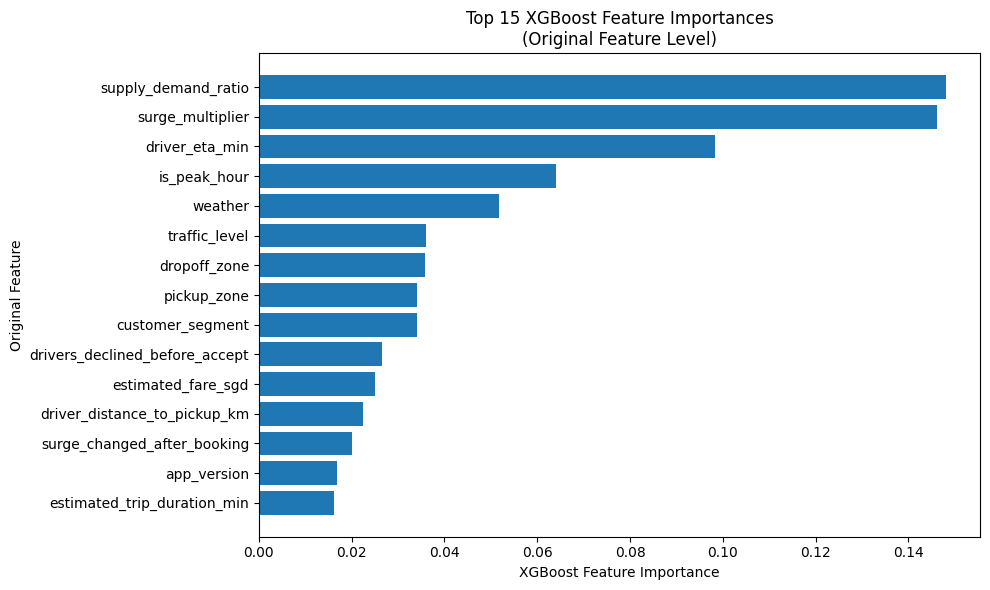

In [15]:
# ============================================================
# 19. XGBOOST FEATURE IMPORTANCE
#     BASED ON ORIGINAL FEATURES
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Get fitted preprocessor and XGBoost model
# ------------------------------------------------------------
final_model = best_xgb
fitted_preprocessor = final_model.named_steps["preprocessor"]
fitted_xgb = final_model.named_steps["clf"]

# ------------------------------------------------------------
# Get XGBoost built-in importance
# ------------------------------------------------------------
xgb_importance = fitted_xgb.feature_importances_

print(
    "Number of transformed XGBoost features:",
    len(xgb_importance)
)

# ------------------------------------------------------------
# Build mapping from transformed features
# back to ORIGINAL features
# ------------------------------------------------------------
original_feature_names = []


# 1. Ordinal features
# OrdinalEncoder creates one output column
# for each original ordinal feature
for col in ordinal_cols:
    original_feature_names.append(col)


# 2. Nominal categorical features
# OneHotEncoder creates multiple output columns
# for each original categorical feature
fitted_ohe = (
    fitted_preprocessor
    .named_transformers_["nominal_cat"]
)

for col, categories in zip(
    nominal_categorical_cols,
    fitted_ohe.categories_
):
    for category in categories:
        original_feature_names.append(col)


# 3. Numerical features
# Passthrough gives one output column
# for each original numerical feature
for col in numeric_cols:
    original_feature_names.append(col)

# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------
print(
    "Number of mapped features:",
    len(original_feature_names)
)

assert len(xgb_importance) == len(original_feature_names), (
    "Mismatch between XGBoost feature importance "
    "and mapped original feature names."
)


# ------------------------------------------------------------
# Create transformed-level table
# ------------------------------------------------------------
feature_importance_detail_df = pd.DataFrame({
    "Original_Feature": original_feature_names,
    "Importance": xgb_importance
})

# ------------------------------------------------------------
# Aggregate one-hot encoded categories
# back to original feature
# ------------------------------------------------------------
# Example:
#
# weather_Clear
# weather_Cloudy
# weather_Rainy
# weather_Heavy Rain
#
# are combined into:
#
# weather
# ------------------------------------------------------------

feature_importance_df = (
    feature_importance_detail_df
    .groupby(
        "Original_Feature",
        as_index=False
    )["Importance"]
    .sum()
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display feature importance
# ------------------------------------------------------------
print(
    "\nTop 20 XGBoost Feature Importances "
    "(Original Feature Level):"
)

display(
    feature_importance_df
    .head(20)
    .round(4)
)

# ============================================================
# PLOT TOP 15 ORIGINAL FEATURE IMPORTANCE
# ============================================================
top_n = 15

top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Original_Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Original Feature")

plt.title(
    "Top 15 XGBoost Feature Importances\n"
    "(Original Feature Level)"
)

plt.tight_layout()
plt.show()



#**Chapter 13B. XGBoost - Permutation Feature Importance**

Permutation importance completed.

Top 20 Permutation Feature Importances:


,Feature,Importance_Mean,Importance_Std
0,driver_eta_min,0.2013,0.0097
1,surge_multiplier,0.0752,0.0043
2,drivers_declined_before_accept,0.0306,0.0036
3,estimated_fare_sgd,0.0179,0.0026
4,traffic_level,0.0119,0.0024
5,weather,0.0098,0.0013
6,surge_changed_after_booking,0.0046,0.0008
7,promo_applied,0.0029,0.0009
8,customer_segment,0.0022,0.0005
9,app_version,0.0020,0.0005


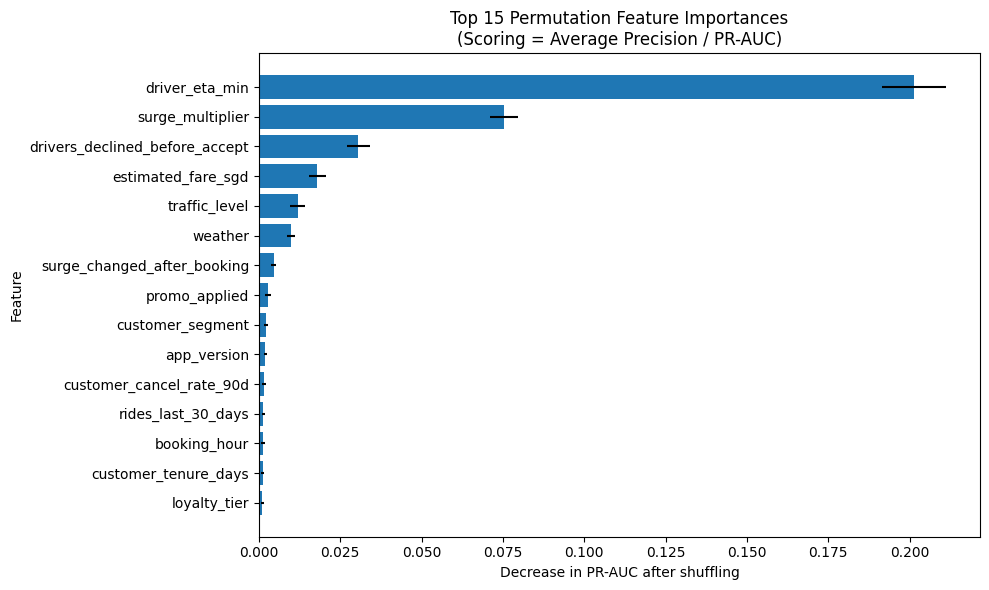

In [16]:
#Since you selected your model based on PR-AUC / Average Precision,
scoring="average_precision"

# ============================================================
# 20. PERMUTATION FEATURE IMPORTANCE
# ============================================================
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    estimator=final_model,
    X=X_test,
    y=y_test,
    scoring=scoring,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

print("Permutation importance completed.")

# ============================================================
# CREATE PERMUTATION IMPORTANCE TABLE
# ============================================================
permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
}).sort_values(
    by="Importance_Mean",
    ascending=False
).reset_index(drop=True)

print("\nTop 20 Permutation Feature Importances:")
display(
    permutation_importance_df.head(20).round(4)
)

# ============================================================
# PLOT TOP 15 PERMUTATION FEATURE IMPORTANCE
# ============================================================
top_n = 15

top_perm = permutation_importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    top_perm["Feature"][::-1],
    top_perm["Importance_Mean"][::-1],
    xerr=top_perm["Importance_Std"][::-1]
)

plt.xlabel("Decrease in PR-AUC after shuffling")
plt.ylabel("Feature")
plt.title(
    "Top 15 Permutation Feature Importances\n"
    "(Scoring = Average Precision / PR-AUC)"
)

plt.tight_layout()
plt.show()



#<font color='purple'>**Chapter  13C. XGBoost - FI vs pFI**

In [17]:
# ============================================================
# 21. MERGE XGBOOST FI + PERMUTATION FEATURE IMPORTANCE
# ============================================================
# Rename columns so the comparison is clearer
xgb_fi_df = feature_importance_df.rename(
    columns={
        "Original_Feature": "Feature",
        "Importance": "XGB_Importance"
    }
)

pfi_df = permutation_importance_df.rename(
    columns={
        "Importance_Mean": "PFI_Mean_Drop",
        "Importance_Std": "PFI_Std"
    }
)

# ------------------------------------------------------------
# Merge both tables using the original feature name
# ------------------------------------------------------------
fi_pfi_comparison_df = pd.merge(
    xgb_fi_df,
    pfi_df,
    on="Feature",
    how="outer"
)

# ------------------------------------------------------------
# Sort by permutation importance
# You can change this to "XGB_Importance" if preferred
# ------------------------------------------------------------
fi_pfi_comparison_df = (
    fi_pfi_comparison_df
    .sort_values(
        by="PFI_Mean_Drop",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Optional ranking columns
# ------------------------------------------------------------
fi_pfi_comparison_df["XGB_Rank"] = (
    fi_pfi_comparison_df["XGB_Importance"]
    .rank(method="min", ascending=False)
)

fi_pfi_comparison_df["PFI_Rank"] = (
    fi_pfi_comparison_df["PFI_Mean_Drop"]
    .rank(method="min", ascending=False)
)

# Reorder columns
fi_pfi_comparison_df = fi_pfi_comparison_df[
    [
        "Feature",
        "XGB_Importance",
        "XGB_Rank",
        "PFI_Mean_Drop",
        "PFI_Std",
        "PFI_Rank"
    ]
]

print("\n==============================================")
print("XGBOOST FI + PERMUTATION FEATURE IMPORTANCE")
print("==============================================")

display(
    fi_pfi_comparison_df.round(4)
)


XGBOOST FI + PERMUTATION FEATURE IMPORTANCE


,Feature,XGB_Importance,XGB_Rank,PFI_Mean_Drop,PFI_Std,PFI_Rank
0,driver_eta_min,0.0982,3.0,0.2013,0.0097,1.0
1,surge_multiplier,0.1462,2.0,0.0752,0.0043,2.0
2,drivers_declined_before_accept,0.0265,10.0,0.0306,0.0036,3.0
3,estimated_fare_sgd,0.0250,11.0,0.0179,0.0026,4.0
4,traffic_level,0.0359,6.0,0.0119,0.0024,5.0
5,weather,0.0517,5.0,0.0098,0.0013,6.0
6,surge_changed_after_booking,0.0201,13.0,0.0046,0.0008,7.0
7,promo_applied,0.0139,19.0,0.0029,0.0009,8.0
8,customer_segment,0.0341,9.0,0.0022,0.0005,9.0
9,app_version,0.0169,14.0,0.0020,0.0005,10.0


#<font color='purple'> **Chapter 13D. Interpret Feature and Permutation Importance**

In [23]:

fi_pfi_comparison_df_preview = fi_pfi_comparison_df

prompt_interpret_imp=f"""

Interpret the results for {fi_pfi_comparison_df_preview}
Explain the interpretation in a way where Rdie Operations Manager aand other stakeholders can understand which
features have high risks for customer cancellation
Also explain the technical how to judge from the numbers
"""
#print('=== Prompt to send ===')
#print(prompt_interpret_imp)

response_interpret_imp = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_interpret_imp
)
print('\n=== LLM response ===')
print(response_interpret_imp.output_text)




=== LLM response ===
Below is an interpretation of your feature-importance output for **predicting (or being associated with) customer cancellation risk**, explained in two layers:

1) **What business/stakeholders should take away (high cancellation risk drivers)**  
2) **How to judge it technically from the numbers**

---

## 1) Stakeholder-friendly interpretation: “What features have high cancellation risk?”

Your table contains three different “importance” views:

- **XGB_Importance / XGB_Rank**: how much the model uses the feature overall (typical tree-based gain/usage signal).
- **PFI_Mean_Drop / PFI_Rank**: how much **prediction performance drops when that feature is permuted/shuffled**. This is the most directly actionable for “risk”.
- **PFI_Std**: variability of that performance drop across permutations/runs (stability).

### The clearest cancellation-risk features (most important + meaningful PFI drop)

These are the features with **largest PFI_Mean_Drop** (meaning the model

#<font color='purple'> **Chapter 14A . Create SHAP Values and Plots**

SHAP calculation completed.
Number of records explained: 2000
Number of transformed features: 93
SHAP values shape: (2000, 93)


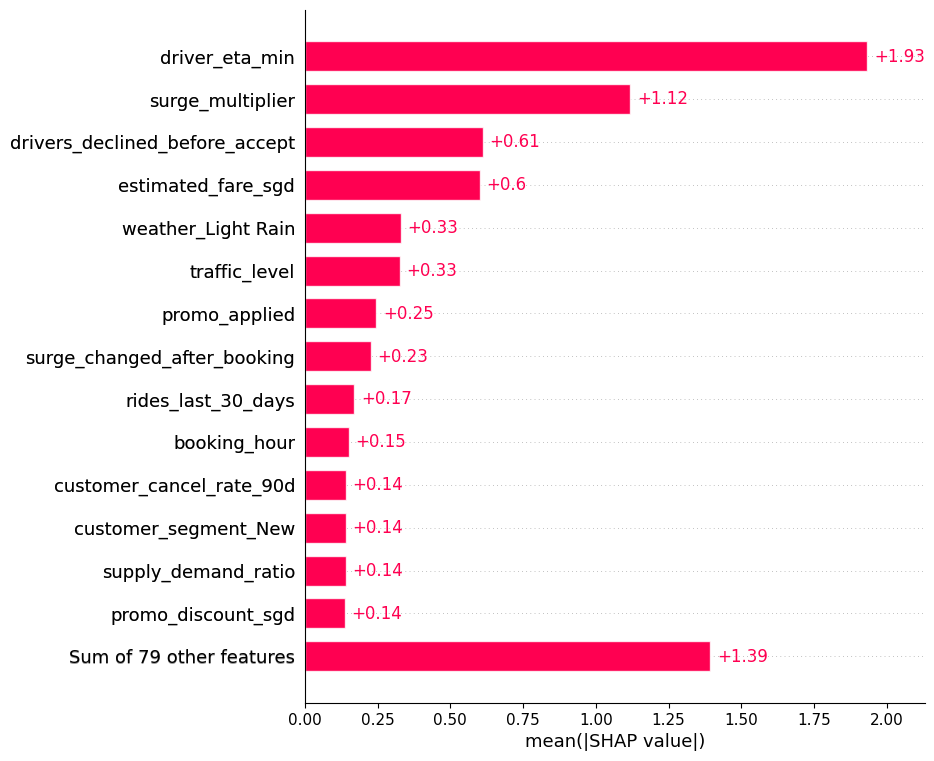

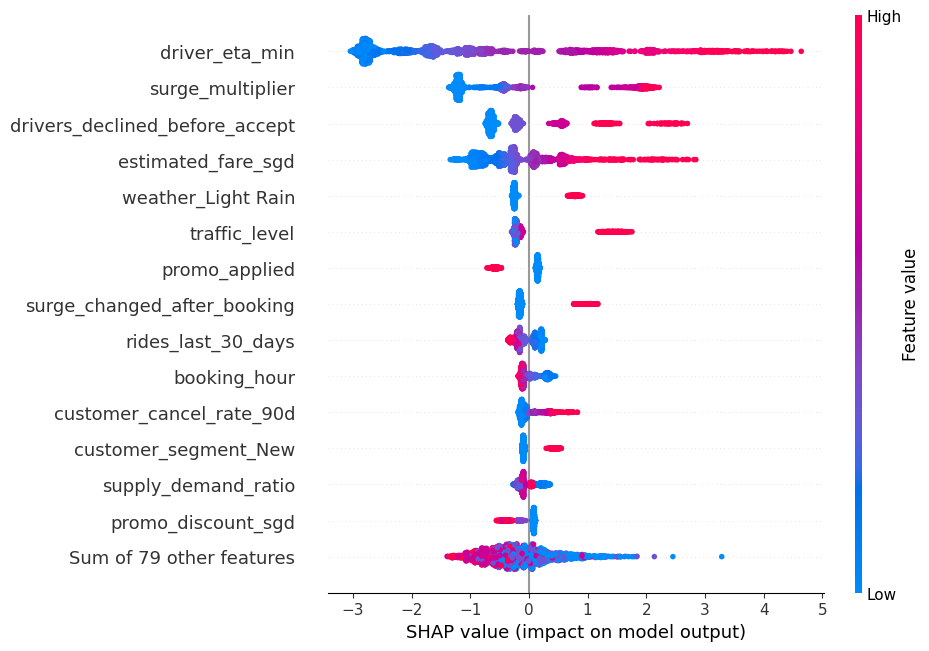

Top 3 SHAP features:
1. driver_eta_min
2. surge_multiplier
3. drivers_declined_before_accept

Dependence Plot: driver_eta_min


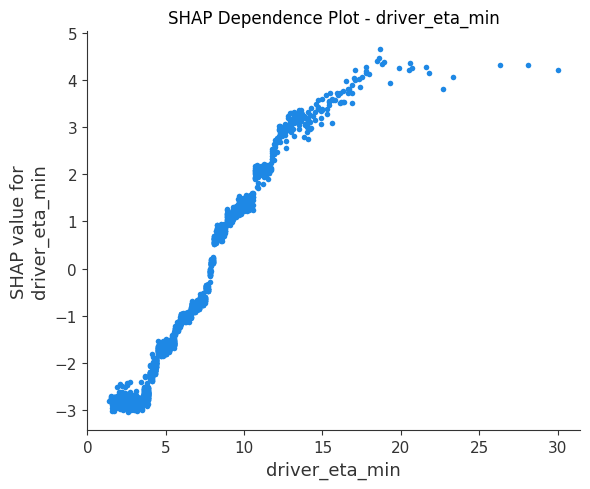


Dependence Plot: surge_multiplier


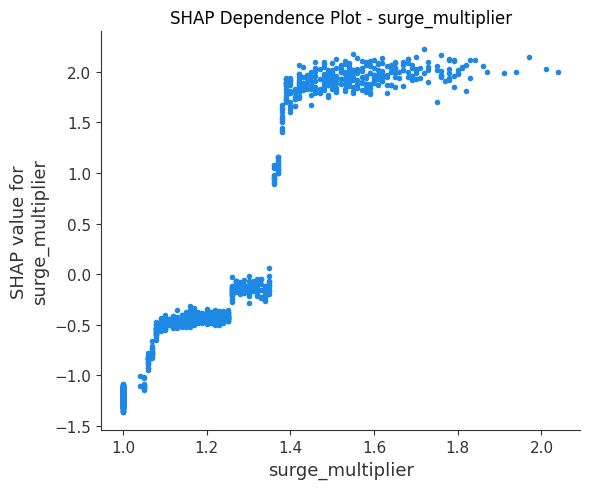


Dependence Plot: drivers_declined_before_accept


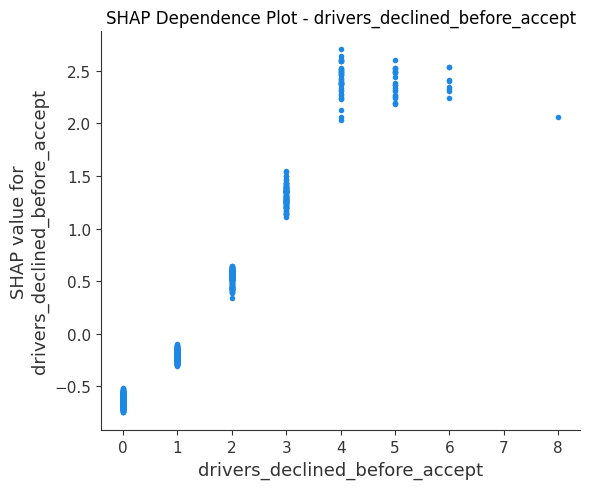


Dependence Plot: promo_applied


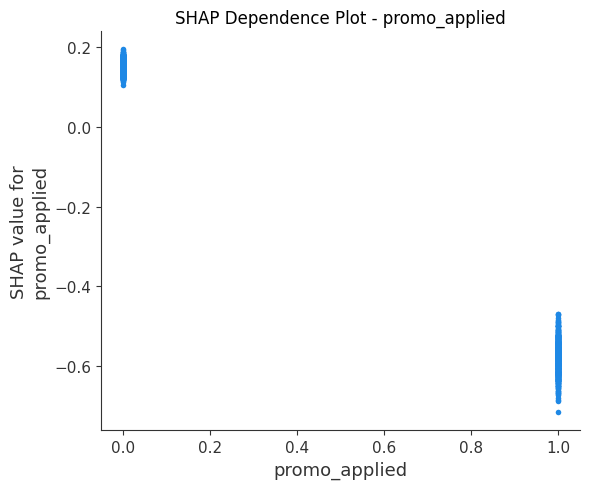

Row number: 986
Original X_test index: 6472
SHAP f(x): 7.9775906
Explaining test observation: 6472


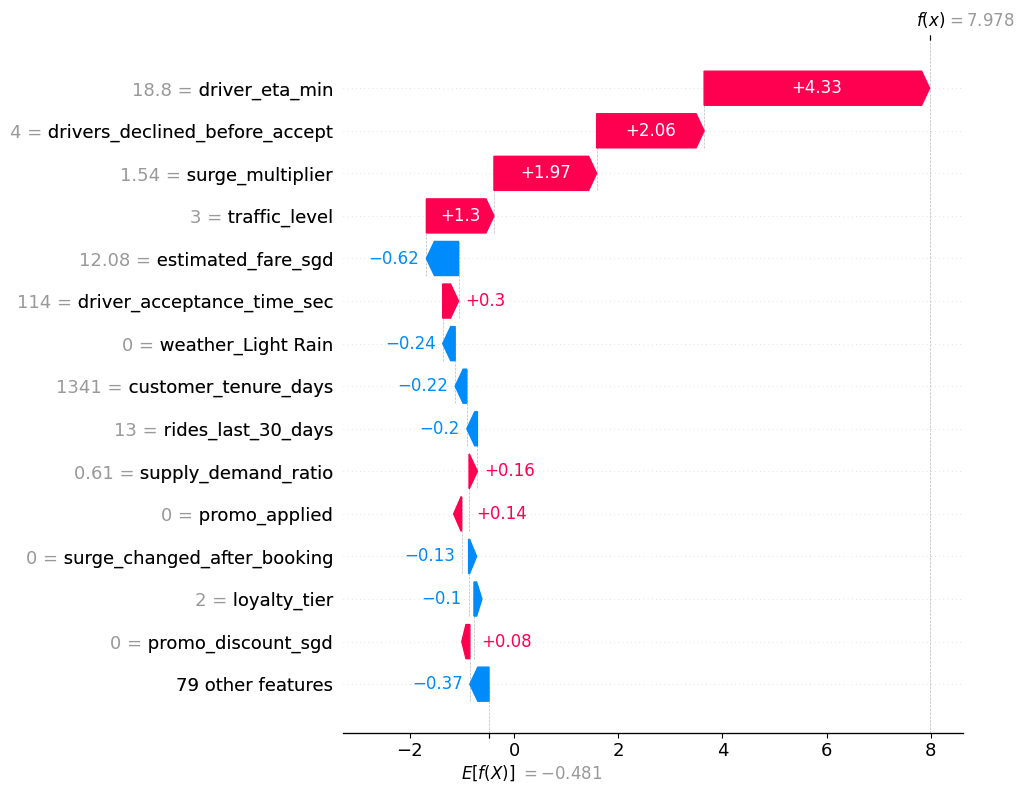

Predicted cancellation probability: 1.000

TOP GLOBAL SHAP FEATURES


,Feature,Mean_Abs_SHAP
0,driver_eta_min,1.9328
1,surge_multiplier,1.1190
2,drivers_declined_before_accept,0.6119
3,estimated_fare_sgd,0.6007
4,weather_Light Rain,0.3303
5,traffic_level,0.3254
6,promo_applied,0.2456
7,surge_changed_after_booking,0.2277
8,rides_last_30_days,0.1704
9,booking_hour,0.1519



TOP LOCAL SHAP FEATURES
Test observation: 8336


,Feature,Value,SHAP_Value,Absolute_SHAP
0,weather_Heavy Rain,1.00,0.8349,0.8349
1,driver_eta_min,7.30,-0.6394,0.6394
2,estimated_fare_sgd,13.39,-0.5142,0.5142
3,drivers_declined_before_accept,1.00,-0.2511,0.2511
4,weather_Light Rain,0.00,-0.2392,0.2392
5,traffic_level,1.00,-0.2286,0.2286
6,supply_demand_ratio,1.11,-0.2179,0.2179
7,surge_changed_after_booking,0.00,-0.1671,0.1671
8,promo_applied,0.00,0.1584,0.1584
9,estimated_trip_duration_min,9.80,-0.1189,0.1189


,Feature,Value,SHAP_Value,Absolute_SHAP,Effect_on_Cancellation
0,weather_Heavy Rain,1.00,0.8349,0.8349,Increases cancellation prediction
1,driver_eta_min,7.30,-0.6394,0.6394,Decreases cancellation prediction
2,estimated_fare_sgd,13.39,-0.5142,0.5142,Decreases cancellation prediction
3,drivers_declined_before_accept,1.00,-0.2511,0.2511,Decreases cancellation prediction
4,weather_Light Rain,0.00,-0.2392,0.2392,Decreases cancellation prediction
5,traffic_level,1.00,-0.2286,0.2286,Decreases cancellation prediction
6,supply_demand_ratio,1.11,-0.2179,0.2179,Decreases cancellation prediction
7,surge_changed_after_booking,0.00,-0.1671,0.1671,Decreases cancellation prediction
8,promo_applied,0.00,0.1584,0.1584,Increases cancellation prediction
9,estimated_trip_duration_min,9.80,-0.1189,0.1189,Decreases cancellation prediction


...

,Feature,Mean_Abs_SHAP
0,driver_eta_min,1.9328
1,surge_multiplier,1.1190
2,drivers_declined_before_accept,0.6119
3,estimated_fare_sgd,0.6007
4,weather_Light Rain,0.3303
5,traffic_level,0.3254
6,promo_applied,0.2456
7,surge_changed_after_booking,0.2277
8,rides_last_30_days,0.1704
9,booking_hour,0.1519



TOP LOCAL SHAP FEATURES - ROW 0
Predicted cancellation probability: 1.000


,Feature,Value,SHAP_Value,Absolute_SHAP,Effect_on_Cancellation
0,weather_Heavy Rain,1.00,0.8349,0.8349,Increases cancellation prediction
1,driver_eta_min,7.30,-0.6394,0.6394,Decreases cancellation prediction
2,estimated_fare_sgd,13.39,-0.5142,0.5142,Decreases cancellation prediction
3,drivers_declined_before_accept,1.00,-0.2511,0.2511,Decreases cancellation prediction
4,weather_Light Rain,0.00,-0.2392,0.2392,Decreases cancellation prediction
5,traffic_level,1.00,-0.2286,0.2286,Decreases cancellation prediction
6,supply_demand_ratio,1.11,-0.2179,0.2179,Decreases cancellation prediction
7,surge_changed_after_booking,0.00,-0.1671,0.1671,Decreases cancellation prediction
8,promo_applied,0.00,0.1584,0.1584,Increases cancellation prediction
9,estimated_trip_duration_min,9.80,-0.1189,0.1189,Decreases cancellation prediction



SHAP EVIDENCE FOR BUSINESS DECISIONS


,Rank,Feature,Mean_Abs_SHAP,Interpretation
0,1,driver_eta_min,1.9328,Important driver of the XGBoost customer cance...
1,2,surge_multiplier,1.1190,Important driver of the XGBoost customer cance...
2,3,drivers_declined_before_accept,0.6119,Important driver of the XGBoost customer cance...
3,4,estimated_fare_sgd,0.6007,Important driver of the XGBoost customer cance...
4,5,weather_Light Rain,0.3303,Important driver of the XGBoost customer cance...
5,6,traffic_level,0.3254,Important driver of the XGBoost customer cance...
6,7,promo_applied,0.2456,Important driver of the XGBoost customer cance...
7,8,surge_changed_after_booking,0.2277,Important driver of the XGBoost customer cance...
8,9,rides_last_30_days,0.1704,Important driver of the XGBoost customer cance...
9,10,booking_hour,0.1519,Important driver of the XGBoost customer cance...


In [27]:
# The tuned XGBoost pipeline is stored in best_xgb, with pipeline steps "preprocessor" and "clf".
# My GridSearchCV returns the best fitted estimator, metrics, and search object,
# and your XGBoost result is stored as best_xgb, m_xgb, search_xgb.

# ============================================================
# 1. CALCULATE SHAP VALUES
# ============================================================
# best_xgb is your fitted XGBoost Pipeline
xgb_pipeline = best_xgb

# Extract the fitted preprocessing step
xgb_preprocessor = xgb_pipeline.named_steps["preprocessor"]

# Extract the fitted XGBoost classifier
xgb_model = xgb_pipeline.named_steps["clf"]

# ------------------------------------------------------------
# Use a sample of test data for SHAP
# Change 500 to len(X_test) if you want the full test set
# ------------------------------------------------------------
n_explain = min(len(X_test), len(X_test))

X_explain = X_test.iloc[:n_explain].copy()

# ------------------------------------------------------------
# Transform using the SAME fitted preprocessor
# ------------------------------------------------------------
X_explain_transformed = xgb_preprocessor.transform(X_explain)

# Convert sparse matrix to dense matrix if necessary
if hasattr(X_explain_transformed, "toarray"):
    X_explain_transformed = X_explain_transformed.toarray()


# Get names after Ordinal Encoding / One-Hot Encoding
feature_names = xgb_preprocessor.get_feature_names_out()


# Put transformed data into a DataFrame
X_shap = pd.DataFrame(
    X_explain_transformed,
    columns=feature_names,
    index=X_explain.index
)

# ------------------------------------------------------------
# Create TreeExplainer and calculate SHAP values
# ------------------------------------------------------------
explainer = shap.TreeExplainer(xgb_model)

shap_raw = explainer.shap_values(X_shap)

# Some SHAP versions may return a list for classifiers
if isinstance(shap_raw, list):
    shap_raw = shap_raw[-1]

shap_raw = np.asarray(shap_raw)


# Expected/base value
base_value = explainer.expected_value

if isinstance(base_value, (list, np.ndarray)):
    base_value = np.asarray(base_value).reshape(-1)[-1]


# Create SHAP Explanation object
# Useful for modern SHAP plotting functions
shap_values = shap.Explanation(
    values=shap_raw,
    base_values=np.repeat(base_value, len(X_shap)),
    data=X_shap.values,
    feature_names=feature_names
)

print("SHAP calculation completed.")
print("Number of records explained:", len(X_shap))
print("Number of transformed features:", len(feature_names))
print("SHAP values shape:", shap_raw.shape)

#Your preprocessing uses ordinal encoding, one-hot encoding and numerical passthrough,
# so obtaining get_feature_names_out() after the fitted transformer is important
# —the XGBoost classifier sees these transformed features, not simply the original X_test columns.

# ============================================================
# 2. GLOBAL SHAP BAR PLOT
# ============================================================
# This tells you which features have the largest overall influence on the model.
# The bar chart tells you how important a feature is, but not whether it increases or decreases cancellation risk.
# Interpretation: Longer bars = greater average influence on XGBoost predictions.

shap.plots.bar(
    shap_values,
    max_display=15
)
plt.show()

# ============================================================
# 3. GLOBAL SHAP BEESWARM PLOT
# ============================================================
# This is generally the most informative global SHAP chart.
# customer_cancelled = 1  -> customer cancelled
# customer_cancelled = 0  -> customer did not cancel
# SHAP > 0 → pushes prediction toward cancellation.
# SHAP < 0 → pushes prediction away from cancellation.
# Red generally represents higher feature values.
# Blue generally represents lower feature values.

shap.plots.beeswarm(
    shap_values,
    max_display=15
)
plt.show()


# ============================================================
# 4. DEPENDENCE PLOTS
#    - TOP 3 SHAP FEATURES
#    - promo_applied
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Mean absolute SHAP for every transformed feature
# ------------------------------------------------------------

mean_abs_shap = np.abs(shap_raw).mean(axis=0)

# ------------------------------------------------------------
# Get indices of Top 3 SHAP features
# ------------------------------------------------------------

top_3_indices = np.argsort(
    mean_abs_shap
)[::-1][:3]

# Get Top 3 feature names
top_3_features = [
    feature_names[i]
    for i in top_3_indices
]

print("Top 3 SHAP features:")
for rank, feature in enumerate(
    top_3_features,
    start=1
):
    print(f"{rank}. {feature}")


# ============================================================
# PLOT TOP 3 FEATURES
# ============================================================

for feature in top_3_features:

    print(
        f"\nDependence Plot: {feature}"
    )

    shap.dependence_plot(
        feature,
        shap_raw,
        X_shap,
        interaction_index=None,
        show=False
    )

    plt.title(
        f"SHAP Dependence Plot - {feature}"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# PLOT promo_applied
# ============================================================

promo_feature = "promo_applied"

if promo_feature in feature_names:

    print(
        f"\nDependence Plot: {promo_feature}"
    )

    shap.dependence_plot(
        promo_feature,
        shap_raw,
        X_shap,
        interaction_index=None,
        show=False
    )

    plt.title(
        "SHAP Dependence Plot - promo_applied"
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        f"\n'{promo_feature}' was not found "
        "in the transformed feature names."
    )

# ============================================================
# 5. LOCAL SHAP WATERFALL PLOT
# ============================================================
# A waterfall plot explains one individual booking.
# Here I use row 0 from the SHAP sample:

# Interpretation:
# Features pushing right / positive increase predicted cancellation risk.
# Features pushing left / negative decrease predicted cancellation risk.
# E[f(X)] is the model's baseline output.
# f(x) is the output for this particular booking.


# SHAP f(x) = base value + sum of SHAP values
fx_all = base_value + shap_raw.sum(axis=1)

target_fx = 8

# Find row position closest to f(x) = 0.99
row_number = np.argmin(
    np.abs(fx_all - target_fx)
)

print("Row number:", row_number)
print("Original X_test index:", X_shap.index[row_number])
print("SHAP f(x):", fx_all[row_number])

#
print("Explaining test observation:", X_shap.index[row_number])

shap.plots.waterfall(
    shap_values[row_number],
    max_display=15
)

plt.show()

# print customer's predicted cancellation probability:#
# Original untransformed booking
original_row = X_explain.iloc[[row_number]]

predicted_probability = xgb_pipeline.predict_proba(
    original_row
)[0, 1]

print(f"Predicted cancellation probability: "f"{predicted_probability:.3f}")

# ============================================================
# 6A. GLOBAL SHAP EVIDENCE TABLE
# ============================================================
global_shap_table = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Abs_SHAP": np.abs(shap_raw).mean(axis=0)
})

global_shap_table = (
    global_shap_table
    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTOP GLOBAL SHAP FEATURES")
display(global_shap_table.head(15).round(4))

# ============================================================
# 6B. LOCAL SHAP EVIDENCE TABLE
# ============================================================
row_number = 0

local_shap_table = pd.DataFrame({
    "Feature": feature_names,
    "Value": X_shap.iloc[row_number].values,
    "SHAP_Value": shap_raw[row_number],
    "Absolute_SHAP": np.abs(shap_raw[row_number])
})

local_shap_table = (
    local_shap_table
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTOP LOCAL SHAP FEATURES")
print("Test observation:",X_shap.index[row_number])

display(local_shap_table.head(15).round(4))

# Add business-friendly direction
local_shap_table["Effect_on_Cancellation"] = np.where(
    local_shap_table["SHAP_Value"] > 0,
    "Increases cancellation prediction",
    "Decreases cancellation prediction"
)

display(local_shap_table.head(15).round(4))

# ============================================================
# 7. MODEL PERFORMANCE + SHAP EVIDENCE
# ============================================================

# ------------------------------------------------------------
# Model predictions on untouched test set
# ------------------------------------------------------------
y_test_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_proba >= 0.50
).astype(int)

# ------------------------------------------------------------
# Calculate model performance
# ------------------------------------------------------------
accuracy = accuracy_score(y_test,y_test_pred)
recall = recall_score(y_test,y_test_pred)
f1 = f1_score(y_test,y_test_pred)
mcc = matthews_corrcoef(y_test,y_test_pred)
roc_auc = roc_auc_score(y_test,y_test_proba)
pr_auc = average_precision_score(y_test,y_test_proba)

# ------------------------------------------------------------
# Performance evidence table
# ------------------------------------------------------------
model_evidence = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [accuracy],
    "Recall": [recall],
    "F1": [f1],
    "MCC": [mcc],
    "ROC_AUC": [roc_auc],
    "PR_AUC": [pr_auc]
})

print("\n==========================================")
print("MODEL PERFORMANCE")
print("==========================================")

display(model_evidence.round(4))

# ------------------------------------------------------------
# Global SHAP evidence
# ------------------------------------------------------------
print("\n==========================================")
print("TOP GLOBAL SHAP FEATURES")
print("==========================================")

display(global_shap_table.head(10).round(4))

# ------------------------------------------------------------
# Local SHAP evidence
# ------------------------------------------------------------
print("\n==========================================")
print(f"TOP LOCAL SHAP FEATURES - ROW {row_number}")
print("==========================================")

print(f"Predicted cancellation probability: "f"{predicted_probability:.3f}")

display(local_shap_table.head(10).round(4))

# ============================================================
# 8. BUSINESS SHAP EVIDENCE TABLE
# ============================================================
# Take top 10 global SHAP features
shap_evidence_table = (
    global_shap_table
    .head(10)
    .copy()
)

# Rank importance
shap_evidence_table["Rank"] = (
    np.arange(1, len(shap_evidence_table) + 1)
)

# Add interpretation
shap_evidence_table["Interpretation"] = (
    "Important driver of the XGBoost "
    "customer cancellation prediction"
)

# Reorder columns
shap_evidence_table = shap_evidence_table[
    [
        "Rank",
        "Feature",
        "Mean_Abs_SHAP",
        "Interpretation"
    ]
]

print("\n==========================================")
print("SHAP EVIDENCE FOR BUSINESS DECISIONS")
print("==========================================")

display(shap_evidence_table.round(4))




#<font color='purple'>**Chapter 15. TEST WITH LIVE PRODUCTION DATA**

LIVE BOOKING


,booking_hour,day_of_week,month,is_weekend,is_peak_hour,is_late_night,public_holiday,pickup_zone,dropoff_zone,airport_trip,...,driver_eta_min,weather,traffic_level,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,app_version,network_quality
8336,23,Friday,6,0,0,1,0,Queenstown,Punggol,0,...,10,Light Rain,High,1.3,0,0,0,13.39,One version behind,Good


Missing columns: set()
Extra columns: set()
✓ Live booking structure matches training data.

LIVE CANCELLATION RISK
Predicted cancellation probability: 88.38%
Risk classification: HIGH RISK
Operating threshold: 0.40

TRANSFORMED LIVE BOOKING


,traffic_level,loyalty_tier,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,pickup_zone_Ang Mo Kio,...,nearby_driver_count,drivers_declined_before_accept,driver_acceptance_time_sec,driver_distance_to_pickup_km,driver_eta_min,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd
0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,33.0,1.74,10.0,1.3,0.0,0.0,0.0,13.39



✓ Live SHAP calculation completed.


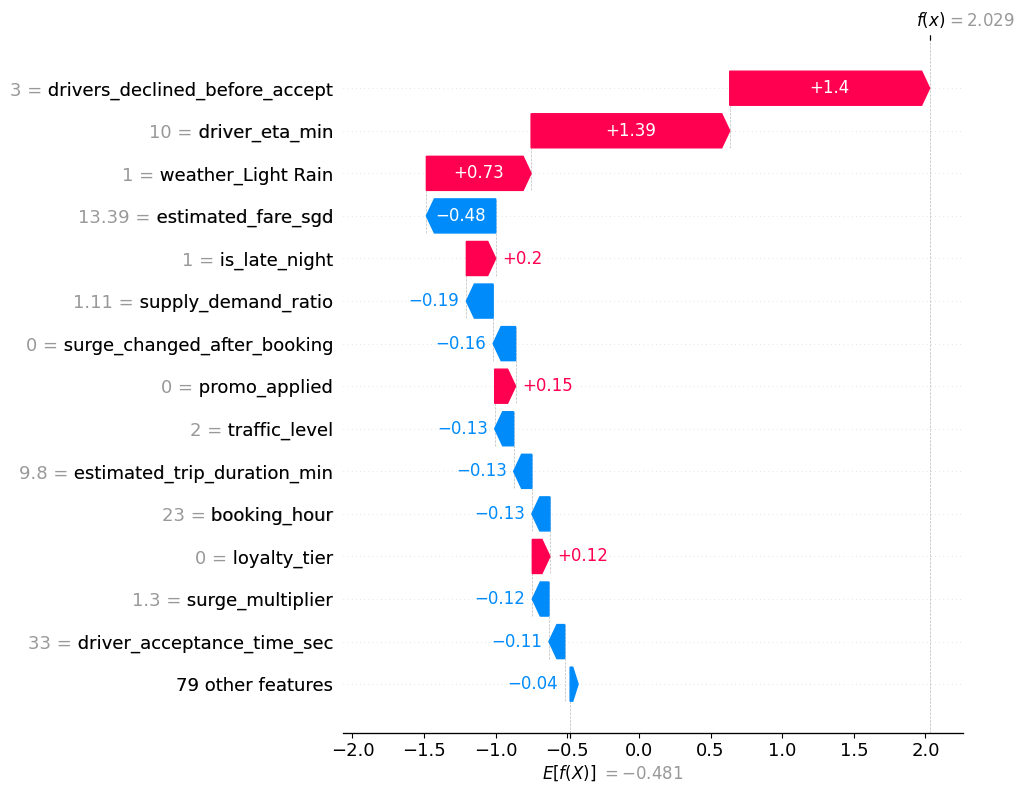


Predicted cancellation probability: 88.38%

TOP LIVE BOOKING RISK DRIVERS


,Feature,Value,SHAP_Value,Absolute_SHAP,Effect_on_Cancellation
0,drivers_declined_before_accept,3.00,1.3955,1.3955,Increases cancellation prediction
1,driver_eta_min,10.00,1.3865,1.3865,Increases cancellation prediction
2,weather_Light Rain,1.00,0.7311,0.7311,Increases cancellation prediction
3,estimated_fare_sgd,13.39,-0.4841,0.4841,Decreases cancellation prediction
4,is_late_night,1.00,0.2049,0.2049,Increases cancellation prediction
5,supply_demand_ratio,1.11,-0.1868,0.1868,Decreases cancellation prediction
6,surge_changed_after_booking,0.00,-0.1568,0.1568,Decreases cancellation prediction
7,promo_applied,0.00,0.1460,0.1460,Increases cancellation prediction
8,traffic_level,2.00,-0.1323,0.1323,Decreases cancellation prediction
9,estimated_trip_duration_min,9.80,-0.1270,0.1270,Decreases cancellation prediction


In [19]:
# ============================================================
# 1. CREATE A LIVE / NEW BOOKING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Start with one valid booking so all required columns exist
live_booking = X_test.iloc[[0]].copy()

# ------------------------------------------------------------
# Replace values with your LIVE / USE-CASE values
# ------------------------------------------------------------

live_booking["driver_eta_min"] = 10
live_booking["surge_multiplier"] = 1.3
live_booking["drivers_declined_before_accept"] = 3
live_booking["traffic_level"] = "High"
live_booking["weather"] = "Light Rain"
live_booking["promo_applied"] = 0
live_booking["is_late_night"] = 1
live_booking["booking_hour"] = 23

print("======================================")
print("LIVE BOOKING")
print("======================================")

display(live_booking)

# ============================================================
# 2. VALIDATE LIVE BOOKING COLUMNS
# ============================================================

missing_columns = set(X_train.columns) - set(live_booking.columns)
extra_columns = set(live_booking.columns) - set(X_train.columns)

print("Missing columns:", missing_columns)
print("Extra columns:", extra_columns)

if len(missing_columns) == 0 and len(extra_columns) == 0:
    print("✓ Live booking structure matches training data.")
else:
    print("✗ Check live booking columns.")


# Make sure column order is exactly the same
live_booking = live_booking[X_train.columns]

# ============================================================
# 3. PREDICT CANCELLATION RISK
# ============================================================

live_probability = best_xgb.predict_proba(
    live_booking
)[:, 1][0]

# Selected operating threshold
threshold = 0.4

live_prediction = int(
    live_probability >= threshold
)

print("\n======================================")
print("LIVE CANCELLATION RISK")
print("======================================")

print(
    f"Predicted cancellation probability: "
    f"{live_probability:.2%}"
)

print(
    "Risk classification:",
    "HIGH RISK"
    if live_prediction == 1
    else "LOW RISK"
)

print(
    f"Operating threshold: "
    f"{threshold:.2f}"
)


# ============================================================
# 4. GET FITTED MODEL COMPONENTS
# ============================================================
live_preprocessor = (
    best_xgb.named_steps["preprocessor"]
)

live_xgb_model = (
    best_xgb.named_steps["clf"]
)

# ============================================================
# 5. TRANSFORM LIVE BOOKING
# ============================================================
live_transformed = live_preprocessor.transform(
    live_booking
)

if hasattr(live_transformed, "toarray"):
    live_transformed = live_transformed.toarray()


live_feature_names = (
    live_preprocessor.get_feature_names_out()
)


live_shap_df = pd.DataFrame(
    live_transformed,
    columns=live_feature_names
)

print("\n======================================")
print("TRANSFORMED LIVE BOOKING")
print("======================================")

display(live_shap_df)


# ============================================================
# 6. CALCULATE LIVE SHAP VALUES
# ============================================================

live_explainer = shap.TreeExplainer(
    live_xgb_model
)

live_shap_raw = live_explainer.shap_values(
    live_shap_df
)

# Some SHAP versions return a list
if isinstance(live_shap_raw, list):
    live_shap_raw = live_shap_raw[-1]

live_shap_raw = np.asarray(
    live_shap_raw
)

# ------------------------------------------------------------
# Base value
# ------------------------------------------------------------
live_base_value = live_explainer.expected_value

if isinstance(
    live_base_value,
    (list, np.ndarray)
):
    live_base_value = (
        np.asarray(live_base_value)
        .reshape(-1)[-1]
    )


# ------------------------------------------------------------
# Create SHAP Explanation object
# ------------------------------------------------------------

live_shap_values = shap.Explanation(
    values=live_shap_raw,
    base_values=np.repeat(
        live_base_value,
        len(live_shap_df)
    ),
    data=live_shap_df.values,
    feature_names=live_feature_names
)

print("\n✓ Live SHAP calculation completed.")

# ============================================================
# 7. LIVE BOOKING WATERFALL PLOT
# ============================================================
shap.plots.waterfall(
    live_shap_values[0],
    max_display=15
)

plt.show()

print(
    f"\nPredicted cancellation probability: "
    f"{live_probability:.2%}"
)

# ============================================================
# 8. LIVE BOOKING SHAP EVIDENCE TABLE
# ============================================================
live_shap_table = pd.DataFrame({
    "Feature": live_feature_names,
    "Value": live_shap_df.iloc[0].values,
    "SHAP_Value": live_shap_raw[0],
    "Absolute_SHAP": np.abs(
        live_shap_raw[0]
    )
})

live_shap_table[
    "Effect_on_Cancellation"
] = np.where(
    live_shap_table["SHAP_Value"] > 0,
    "Increases cancellation prediction",
    "Decreases cancellation prediction"
)

live_shap_table = (
    live_shap_table
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n======================================")
print("TOP LIVE BOOKING RISK DRIVERS")
print("======================================")

display(
    live_shap_table
    .head(15)
    .round(4)
)

#**Chapter 16. Cross-Validate Feature Rankings (Stability Test)**

In [20]:
# ============================================================
# CV FEATURE RANKING – PERTURBATION ROBUSTNESS
# Spearman Rank Correlation:
# Clean PFI ranking vs Noisy PFI ranking
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr


# ============================================================
# 1. SETTINGS
# ============================================================

# Use your final tuned XGBoost pipeline
model_for_stability = best_xgb

# Same CV design used in modelling
cv_stability = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Keep consistent with your primary model-selection metric
SCORING = "average_precision"

# Number of PFI repeats
N_REPEATS = 5

# Noise strength:
# 0.05 = noise equal to 5% of each feature's standard deviation
NOISE_LEVEL = 0.05

RANDOM_STATE = 42


# ============================================================
# 2. IDENTIFY FEATURES THAT CAN RECEIVE NUMERIC NOISE
# ============================================================

# Only perturb genuinely continuous numeric variables.
# Binary 0/1 flags are left unchanged.
continuous_numeric_cols = [
    col for col in numeric_cols
    if col in X.columns
    and X[col].nunique(dropna=True) > 2
]

print("Continuous numeric features to perturb:")
print(continuous_numeric_cols)

# ============================================================
# 3. FUNCTION TO ADD SMALL CONTROLLED NOISE
# ============================================================

def create_noisy_data(
    X_original,
    reference_data,
    numeric_features,
    noise_level=0.05,
    random_state=42
):
    """
    Adds small Gaussian noise to continuous numeric features.

    Noise SD =
    noise_level × training-fold feature SD

    Example:
    noise_level = 0.05 means 5% of the feature's SD.
    """

    rng = np.random.default_rng(random_state)

    X_noisy = X_original.copy()

    for col in numeric_features:

        # Use TRAINING-fold SD so validation data
        # does not determine the perturbation scale.
        feature_std = reference_data[col].std()

        if pd.isna(feature_std) or feature_std == 0:
            continue

        noise = rng.normal(
            loc=0,
            scale=noise_level * feature_std,
            size=len(X_noisy)
        )

        X_noisy[col] = X_noisy[col].astype(float) + noise

    return X_noisy

# ============================================================
# 4. 5-FOLD PERTURBATION ROBUSTNESS TEST
# ============================================================

fold_results = []

clean_importance_folds = []
noisy_importance_folds = []

for fold, (train_idx, val_idx) in enumerate(
    cv_stability.split(X, y),
    start=1
):

    print(f"\nRunning Fold {fold}...")

    # --------------------------------------------------------
    # Split fold
    # --------------------------------------------------------

    X_fold_train = X.iloc[train_idx].copy()
    X_fold_val = X.iloc[val_idx].copy()

    y_fold_train = np.asarray(y)[train_idx]
    y_fold_val = np.asarray(y)[val_idx]


    # --------------------------------------------------------
    # Fit a fresh copy of the tuned XGBoost pipeline
    # --------------------------------------------------------

    fold_model = clone(model_for_stability)

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )


    # --------------------------------------------------------
    # PFI ON CLEAN VALIDATION DATA
    # --------------------------------------------------------

    clean_pfi = permutation_importance(
        estimator=fold_model,
        X=X_fold_val,
        y=y_fold_val,
        scoring=SCORING,
        n_repeats=N_REPEATS,
        random_state=RANDOM_STATE + fold,
        n_jobs=-1
    )

    clean_df = pd.DataFrame({
        "Feature": X_fold_val.columns,
        "Clean_Importance": clean_pfi.importances_mean
    })


    # --------------------------------------------------------
    # CREATE NOISY VERSION OF SAME VALIDATION DATA
    # --------------------------------------------------------

    X_fold_val_noisy = create_noisy_data(
        X_original=X_fold_val,
        reference_data=X_fold_train,
        numeric_features=continuous_numeric_cols,
        noise_level=NOISE_LEVEL,
        random_state=RANDOM_STATE + fold
    )


    # --------------------------------------------------------
    # PFI ON NOISY VALIDATION DATA
    # --------------------------------------------------------

    noisy_pfi = permutation_importance(
        estimator=fold_model,
        X=X_fold_val_noisy,
        y=y_fold_val,
        scoring=SCORING,
        n_repeats=N_REPEATS,
        random_state=RANDOM_STATE + 100 + fold,
        n_jobs=-1
    )

    noisy_df = pd.DataFrame({
        "Feature": X_fold_val.columns,
        "Noisy_Importance": noisy_pfi.importances_mean
    })


    # --------------------------------------------------------
    # MERGE CLEAN + NOISY IMPORTANCE
    # --------------------------------------------------------

    fold_df = pd.merge(
        clean_df,
        noisy_df,
        on="Feature"
    )


    # --------------------------------------------------------
    # CONVERT IMPORTANCE TO RANKS
    # Rank 1 = most important
    # --------------------------------------------------------

    fold_df["Clean_Rank"] = (
        fold_df["Clean_Importance"]
        .rank(
            method="average",
            ascending=False
        )
    )

    fold_df["Noisy_Rank"] = (
        fold_df["Noisy_Importance"]
        .rank(
            method="average",
            ascending=False
        )
    )


    # --------------------------------------------------------
    # SPEARMAN RANK CORRELATION
    # --------------------------------------------------------

    rho, p_value = spearmanr(
        fold_df["Clean_Rank"],
        fold_df["Noisy_Rank"]
    )


    fold_results.append({
        "Fold": fold,
        "Spearman_Rho": rho,
        "P_Value": p_value
    })


    clean_importance_folds.append(
        clean_df
        .set_index("Feature")["Clean_Importance"]
    )

    noisy_importance_folds.append(
        noisy_df
        .set_index("Feature")["Noisy_Importance"]
    )

    print(
        f"Fold {fold} Spearman rho: "
        f"{rho:.4f}"
    )



# ============================================================
# 5. SPEARMAN STABILITY RESULTS
# ============================================================

stability_results_df = pd.DataFrame(
    fold_results
)

print("\n==========================================")
print("CV FEATURE RANKING – PERTURBATION ROBUSTNESS")
print("==========================================")

display(
    stability_results_df.round(4)
)


mean_rho = stability_results_df[
    "Spearman_Rho"
].mean()

std_rho = stability_results_df[
    "Spearman_Rho"
].std()

print(
    f"\nMean Spearman Rank Correlation: "
    f"{mean_rho:.4f}"
)

print(
    f"Std of Spearman Correlation: "
    f"{std_rho:.4f}"
)


# ============================================================
# 6. AGGREGATE FEATURE IMPORTANCE ACROSS CV FOLDS
# ============================================================

clean_cv_df = pd.concat(
    clean_importance_folds,
    axis=1
)

noisy_cv_df = pd.concat(
    noisy_importance_folds,
    axis=1
)


mean_clean_importance = clean_cv_df.mean(axis=1)

mean_noisy_importance = noisy_cv_df.mean(axis=1)


feature_stability_df = pd.DataFrame({
    "Feature": mean_clean_importance.index,
    "Clean_PFI": mean_clean_importance.values,
    "Noisy_PFI": mean_noisy_importance.values
})


feature_stability_df["Clean_Rank"] = (
    feature_stability_df["Clean_PFI"]
    .rank(
        method="average",
        ascending=False
    )
)

feature_stability_df["Noisy_Rank"] = (
    feature_stability_df["Noisy_PFI"]
    .rank(
        method="average",
        ascending=False
    )
)


feature_stability_df["Rank_Change"] = (
    feature_stability_df["Noisy_Rank"]
    -
    feature_stability_df["Clean_Rank"]
).abs()


feature_stability_df = (
    feature_stability_df
    .sort_values(
        "Clean_Rank"
    )
    .reset_index(drop=True)
)


print("\n==========================================")
print("CLEAN vs NOISY FEATURE RANKING")
print("==========================================")

display(
    feature_stability_df
    .head(15)
    .round(4)
)


# ============================================================
# 7. OVERALL SPEARMAN RANK COEFFICIENT
# ============================================================

overall_rho, overall_p = spearmanr(
    feature_stability_df["Clean_Rank"],
    feature_stability_df["Noisy_Rank"]
)

print("\n==========================================")
print("OVERALL FEATURE-RANKING STABILITY")
print("==========================================")

print(
    f"Spearman Rank Coefficient: "
    f"{overall_rho:.4f}"
)

print(
    f"P-value: "
    f"{overall_p:.6f}"
)

# ============================================================
# 8. AUTOMATIC INTERPRETATION
# ============================================================

if overall_rho >= 0.90:
    interpretation = (
        "Very strong feature-ranking stability. "
        "The model identifies almost the same important "
        "features after small input perturbations."
    )

elif overall_rho >= 0.80:
    interpretation = (
        "Strong feature-ranking stability. "
        "Most important features retain similar rankings "
        "after perturbation."
    )

elif overall_rho >= 0.60:
    interpretation = (
        "Moderate feature-ranking stability. "
        "The overall ranking is reasonably consistent, "
        "although some features change position."
    )

else:
    interpretation = (
        "Weak feature-ranking stability. "
        "Feature importance changes substantially "
        "after small perturbations and should be reviewed."
    )


print("\nInterpretation:")
print(interpretation)



Continuous numeric features to perturb:
['booking_hour', 'month', 'distance_km', 'estimated_trip_duration_min', 'customer_tenure_days', 'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d', 'previous_customer_cancellations', 'avg_previous_wait_time_min', 'customer_rating', 'driver_rating', 'active_driver_supply_zone', 'booking_demand_zone', 'supply_demand_ratio', 'nearby_driver_count', 'drivers_declined_before_accept', 'driver_acceptance_time_sec', 'driver_distance_to_pickup_km', 'driver_eta_min', 'surge_multiplier', 'promo_discount_sgd', 'estimated_fare_sgd']

Running Fold 1...
Fold 1 Spearman rho: 0.8587

Running Fold 2...
Fold 2 Spearman rho: 0.8333

Running Fold 3...
Fold 3 Spearman rho: 0.9493

Running Fold 4...
Fold 4 Spearman rho: 0.9163

Running Fold 5...
Fold 5 Spearman rho: 0.8741

CV FEATURE RANKING – PERTURBATION ROBUSTNESS


,Fold,Spearman_Rho,P_Value
0,1,0.8587,0.0
1,2,0.8333,0.0
2,3,0.9493,0.0
3,4,0.9163,0.0
4,5,0.8741,0.0



Mean Spearman Rank Correlation: 0.8863
Std of Spearman Correlation: 0.0463

CLEAN vs NOISY FEATURE RANKING


,Feature,Clean_PFI,Noisy_PFI,Clean_Rank,Noisy_Rank,Rank_Change
0,driver_eta_min,0.2108,0.2194,1.0,1.0,0.0
1,surge_multiplier,0.0841,0.0951,2.0,2.0,0.0
2,drivers_declined_before_accept,0.0347,0.0305,3.0,3.0,0.0
3,estimated_fare_sgd,0.0187,0.0205,4.0,4.0,0.0
4,weather,0.0114,0.0110,5.0,6.0,1.0
5,traffic_level,0.0105,0.0119,6.0,5.0,1.0
6,surge_changed_after_booking,0.0056,0.0059,7.0,7.0,0.0
7,promo_applied,0.0030,0.0035,8.0,8.0,0.0
8,customer_segment,0.0019,0.0016,9.0,10.0,1.0
9,promo_discount_sgd,0.0019,0.0016,10.0,9.0,1.0



OVERALL FEATURE-RANKING STABILITY
Spearman Rank Coefficient: 0.8956
P-value: 0.000000

Interpretation:
Strong feature-ranking stability. Most important features retain similar rankings after perturbation.


#<font color = 'red'>**Chapter 18. Create Plots and make interpretations**

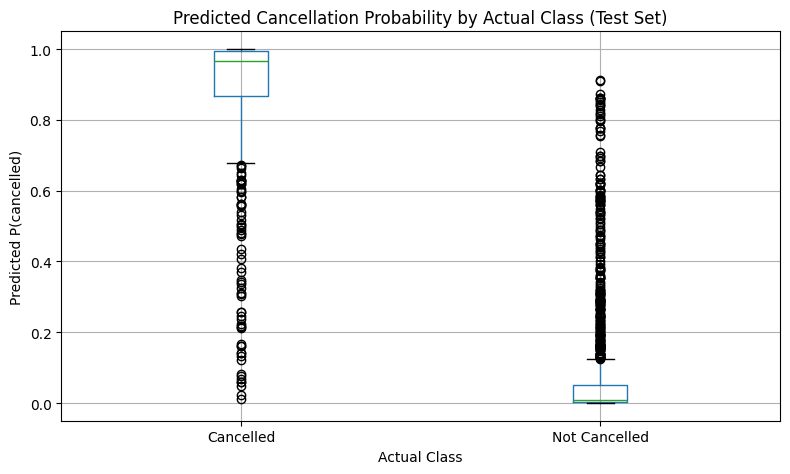

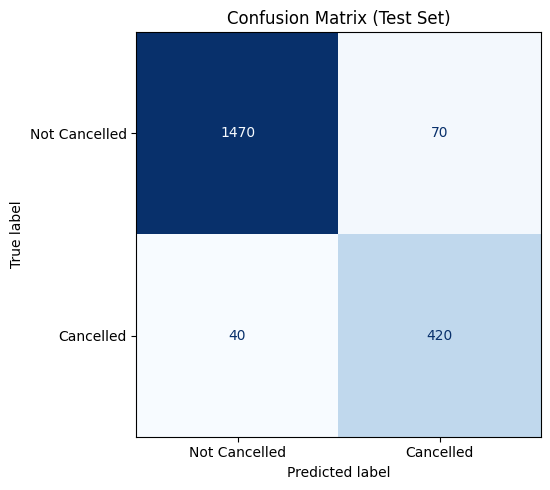

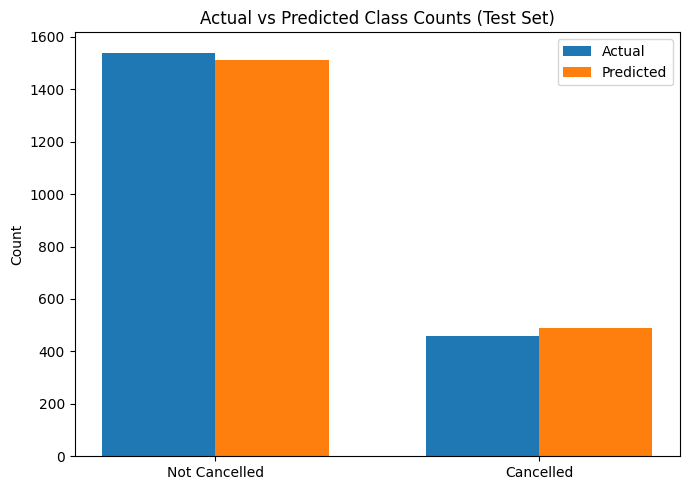

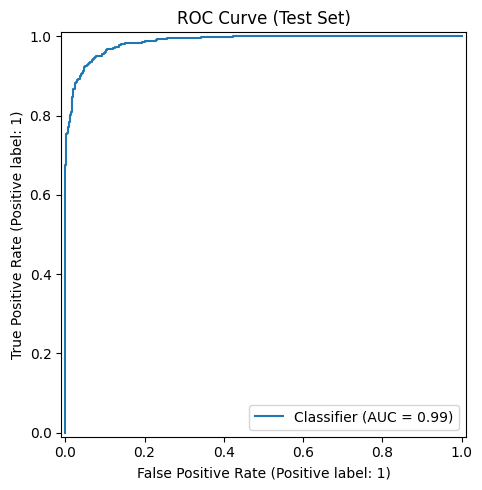

ROC-AUC (Test): 0.9863


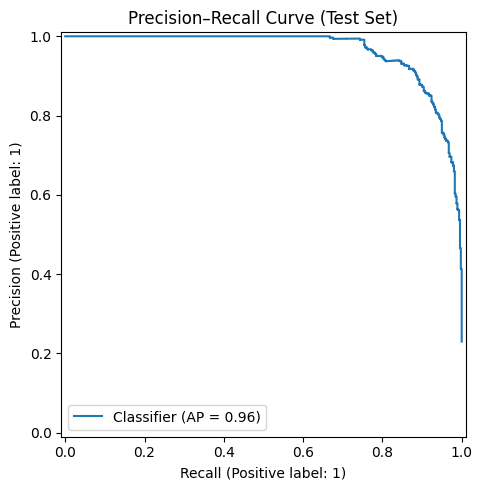

Average Precision (Test): 0.9646

Concise model interpretation:
- The model detects cancellations by ranking customers by P(cancelled); a higher ROC-AUC and Average Precision indicate better separation between cancelled and not-cancelled customers.
- Precision (TP / (TP + FP)) means: among customers predicted to cancel, what fraction truly cancel. High precision reduces the number of 'false alarm' interventions.
- Recall (TP / (TP + FN)) means: among truly cancelled customers, what fraction are caught by the model. Higher recall reduces missed cancellations.
- Based on the test confusion matrix: FP represent unnecessary outreach, while FN represent missed cancellations. If missing cancellations is more costly than extra outreach, you would generally prefer higher recall; if outreach cost is high, you would prefer higher precision.
- Limitations: results come from a single train/test split plus cross-validation summary; performance may vary with threshold choice and data changes. Also, 

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score, average_precision_score

# -------------------------
# 12. Boxplot: predicted cancellation probability by actual class
# -------------------------
# Use the test set for plotting
fig, ax = plt.subplots(figsize=(8, 5))
test_df_plot = pd.DataFrame({
    "actual_cancelled": y_test,
    "predicted_proba_cancelled": y_test_proba
})

# Map classes to labels
test_df_plot["actual_label"] = test_df_plot["actual_cancelled"].map({
    0: "Not Cancelled",
    1: "Cancelled"
})

# Boxplot
test_df_plot.boxplot(
    column="predicted_proba_cancelled",
    by="actual_label",
    ax=ax,
    grid=True
)
ax.set_title("Predicted Cancellation Probability by Actual Class (Test Set)")
ax.set_xlabel("Actual Class")
ax.set_ylabel("Predicted P(cancelled)")
plt.suptitle("")  # remove automatic pandas boxplot suptitle
plt.tight_layout()
plt.show()

# -------------------------
# 13. Confusion matrix plot
# -------------------------
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Cancelled", "Cancelled"]
)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

# -------------------------
# 14. Actual vs predicted class-count bar chart
# -------------------------
actual_counts = pd.Series(y_test).value_counts().reindex([0, 1], fill_value=0)
pred_counts = pd.Series(y_test_pred).value_counts().reindex([0, 1], fill_value=0)

labels = ["Not Cancelled", "Cancelled"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, actual_counts.values, width=width, label="Actual")
ax.bar(x + width/2, pred_counts.values, width=width, label="Predicted")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Count")
ax.set_title("Actual vs Predicted Class Counts (Test Set)")
ax.legend()
plt.tight_layout()
plt.show()

# -------------------------
# 15. ROC curve with ROC-AUC value
# -------------------------
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    ax=ax
)
ax.set_title("ROC Curve (Test Set)")
plt.tight_layout()
plt.show()

roc_auc_value = roc_auc_score(y_test, y_test_proba)
print(f"ROC-AUC (Test): {roc_auc_value:.4f}")

# -------------------------
# 16. Precision–Recall curve with Average Precision value
# -------------------------
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba,
    ax=ax
)
ax.set_title("Precision–Recall Curve (Test Set)")
plt.tight_layout()
plt.show()

avg_prec_value = average_precision_score(y_test, y_test_proba)
print(f"Average Precision (Test): {avg_prec_value:.4f}")

# -------------------------
# 17. Concise model interpretation
# -------------------------
print("\nConcise model interpretation:")
print(
    "- The model detects cancellations by ranking customers by P(cancelled); a higher ROC-AUC and Average Precision "
    "indicate better separation between cancelled and not-cancelled customers."
)
print(
    "- Precision (TP / (TP + FP)) means: among customers predicted to cancel, what fraction truly cancel. "
    "High precision reduces the number of \'false alarm\' interventions."
)
print(
    "- Recall (TP / (TP + FN)) means: among truly cancelled customers, what fraction are caught by the model. "
    "Higher recall reduces missed cancellations."
)
print(
    "- Based on the test confusion matrix: FP represent unnecessary outreach, while FN represent missed cancellations. "
    "If missing cancellations is more costly than extra outreach, you would generally prefer higher recall; "
    "if outreach cost is high, you would prefer higher precision."
)
print(
    "- Limitations: results come from a single train/test split plus cross-validation summary; performance may vary "
    "with threshold choice and data changes. Also, Logistic Regression assumes a linear relationship in the learned "
    "feature space, which may not capture complex patterns fully."
)

#**Chapter 19. Ask Prompt to recommend suitable models for comparison**

In [ ]:
df=cleaned2_df

prompt_suggest = f"""
You are an expert machine learning data scientist specialising in binary classification models.

The pandas DataFrame is named `df`.

=========================
TARGET
=========================
Target column:
customer_cancelled

Target values:
- 0 = Customer did not cancel
- 1 = Customer cancelled

=========================
DATASET PROFILE
=========================
{payload_text}

The dataset has already undergone preprocessing.

Assume the following preprocessing has been completed:
- Missing values have been handled.
- Identifier-like columns have been removed.
- Datetime columns have been removed or transformed into useful features.
- Known target leakage features have been removed.

Use ONLY the information contained in the Dataset Profile.

Do NOT assume:
- additional columns
- hidden relationships
- unknown distributions
- feature importance
- correlations
- missing values
- class imbalance beyond what is explicitly provided

If information cannot be determined from the Dataset Profile, explicitly state that it cannot be determined.

=========================
BUSINESS CONTEXT
=========================

Business Problem

Grab Ride Operations Manager has observed a high rate of customer cancellations before trip commencement.

Business Objective

Develop a machine learning model that predicts the probability that a customer will cancel a booking before trip commencement.

Business Goal

Reduce customer cancellations through proactive operational interventions while minimising unnecessary incentive costs.

Dataset Context

Each row represents one Grab booking.

Approximately 23% of bookings were cancelled before trip commencement.

The dataset contains customer information, booking details, driver availability, pricing, weather, traffic conditions and booking outcomes.

=========================
TASK
=========================

Provide recommendations based ONLY on the Dataset Profile and Business Context.

Justify every recommendation using BOTH:
- dataset characteristics
- business objective

Avoid generic machine learning advice.

Present answers using clear tables whenever appropriate.

====================================================
1. RECOMMEND SUITABLE MODELS
====================================================

Recommend ONLY the three strongest classification models for this problem.

For each model provide:

- Model name
- Why it is suitable
- Why it is appropriate for this dataset
- Advantages
- Limitations
- Whether it is suitable as a baseline model
- Whether it is suitable as a production model

====================================================
2. HYPERPARAMETERS
====================================================

For each recommended model list the most important hyperparameters.

For each hyperparameter provide:

- Parameter name
- Recommended starting value
- Recommended tuning range
- Why it is important
- Whether it mainly improves
    - generalisation
    - reduces overfitting
    - improves prediction performance
    - training efficiency

Recommend an appropriate hyperparameter tuning method.

Examples may include:
- RandomizedSearchCV
- GridSearchCV
- Bayesian Optimisation

Explain why your recommendation is appropriate.

====================================================
3. CROSS-VALIDATION
====================================================

Recommend an appropriate cross-validation strategy.

Explain:

- Recommended method
- Number of folds
- Whether stratification should be used
- Why it is suitable
- How it improves model reliability
- How it reduces overfitting risk

====================================================
4. EVALUATION METRICS
====================================================

Recommend suitable evaluation metrics for this business problem.

For each metric explain:

- What it measures
- Why it is appropriate
- Whether higher or lower is better
- Strengths
- Weaknesses
- When it should be prioritised

Separate metrics into:

Model discrimination
Examples:
- ROC-AUC
- PR-AUC

Classification metrics
Examples:
- Precision
- Recall
- F1-score
- MCC
- Confusion Matrix

Probability metrics
Examples:
- Log Loss
- Brier Score

Business metrics

Explain how each metric relates to reducing customer cancellations while avoiding excessive intervention costs.

====================================================
5. THRESHOLD OPTIMISATION
====================================================

Recommend how the classification probability threshold should be selected.

Discuss:

- Why 0.50 may not be optimal
- Precision vs Recall trade-off
- False Positive vs False Negative trade-offs
- Business implications
- Recommended approach for this problem

====================================================
6. PROBABILITY CALIBRATION
====================================================

Because the objective is to predict cancellation probability rather than only the class label, recommend whether probability calibration should be performed.

Discuss:

- Calibration Curve
- Brier Score
- Platt Scaling
- Isotonic Regression

Explain why calibration is important for operational decision-making.

====================================================
7. EXPLORATORY DATA ANALYSIS (EDA)
====================================================

Recommend useful EDA before modelling.

For each plot explain:

- What it shows
- Why it is useful
- What modelling insight it may provide

Include suitable plots for:

- Target distribution
- Numerical features
- Categorical features
- Correlation analysis
- Missing values (if applicable)
- Class imbalance
- Feature distributions
- Outlier detection

====================================================
8. MODEL EVALUATION PLOTS
====================================================

Recommend useful plots after training.

For each plot explain:

- What it shows
- How it evaluates classifier performance
- Why it is useful for the business problem

Examples include:

- ROC Curve
- Precision-Recall Curve
- Confusion Matrix
- Calibration Curve
- Lift Chart
- Gain Chart
- Probability Distribution
- Feature Importance
- SHAP Summary Plot
- Partial Dependence Plot
- Permutation Importance

====================================================
9. MODEL INTERPRETABILITY
====================================================

Recommend appropriate explainability techniques.

Discuss:

- Feature Importance
- Permutation Importance
- SHAP
- Logistic Regression coefficients (if applicable)

Explain:

- when each method should be used
- strengths
- limitations
- suitability for communicating results to business stakeholders

====================================================
10. RECOMMENDED MODELLING WORKFLOW
====================================================

Recommend an end-to-end modelling workflow.

Include:

1. Data preprocessing
2. Baseline model
3. Candidate models
4. Cross-validation
5. Hyperparameter tuning
6. Probability calibration
7. Threshold optimisation
8. Final model selection
9. Business evaluation
10. Deployment recommendation

Conclude by recommending the single best modelling strategy for this project and justify your recommendation using only the Dataset Profile and Business Context.
"""



##print('=== Prompt to send ===')
##print(prompt_testing)

response_suggest = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_suggest
)
print('\n=== LLM response ===')
print(response_suggest.output_text)



=== LLM response ===
Below are recommendations **based only on the Dataset Profile + Business Context**. Where the profile does not contain enough information (e.g., exact encoding/“already preprocessed” details), I explicitly say so.

---

## 1) RECOMMEND SUITABLE MODELS (top 3)

### Summary table
| Rank | Model name | Why it is suitable | Why appropriate for this dataset | Advantages | Limitations | Baseline? | Production? |
|---:|---|---|---|---|---|---|---|
| 1 | **Gradient Boosting (LightGBM / XGBoost style) for binary classification** | Captures non-linear effects and interactions across mixed feature types | Profile shows many categorical features (day_of_week, zones, vehicle_type, payment_method, weather, traffic_level, app_version, network_quality, etc.) and engineered numeric variables; cancellation rate is ~**23%**, so probabilistic ranking matters | Strong discrimination; handles non-linearities; works well with tabular data; often competitive on AUC/PR-AUC | Needs careful

In [ ]:
df=cleaned2_df

prompt_codes = f"""

I have used below code to create baseline model of Logistic Regression. df, X, y, preprocessor are already defined. XGBoost is installed
Based on {response_suggest}, generate simple, executable python code to train baseline model, Gradient Boosting (XGBoost style) model and Random Forest model,
using the suggested CROSS-VALIDATION STRATEGY, Hyperparameter tuning
Evaluation metrics are MCC (Matthews Correlation Coefficient),F1-score,ROC-AUC,PR-AUC.


TARGET = "customer_cancelled"
X = df.drop(columns=[TARGET])
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
ordinal_categories = []
for col in ordinal_cols:
    if col == "traffic_level":
        ordinal_categories.append(["Low", "Medium", "High", "Severe"])
    elif col == "loyalty_tier":
        # Order given: Platinum > Gold > Silver > NA
        # OrdinalEncoder maps increasing integers to increasing category order.
        ordinal_categories.append(["NA", "Silver", "Gold", "Platinum"])
    else:
        raise ValueError(f"Unexpected ordinal feature: {col}")

ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# One-hot for nominal categoricals
onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True  # works in recent sklearn
)

preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, ordinal_cols),
        ("nominal_cat", onehot_encoder, nominal_categorical_cols),
        ("num", "passthrough", numeric_cols),
    ],
    remainder="drop"
)
preprocessor



"""

response_codes = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_codes
)
print('\n=== LLM response ===')
print(response_codes.output_text)


=== LLM response ===
```python
# Simple, executable training script:
# - Baseline: Logistic Regression (regularized, balanced)
# - XGBoost-style Gradient Boosting: XGBClassifier
# - Random Forest
# - 5-fold Stratified CV + RandomizedSearchCV
# - Metrics: MCC, F1, ROC-AUC, PR-AUC
#
# NOTE: This assumes you already have:
#   - df (pandas DataFrame)
#   - ordinal_cols, nominal_categorical_cols, numeric_cols defined
#   - (optionally) XGBoost installed: pip install xgboost

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    matthews_corrcoef,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

from scipy.stats import loguniform, rand

In [ ]:

prompt_code_without_RSC = f"""

generate codes exactly the same as below but without RandomizedSearchCV

# ---------------------------
# Data
# ---------------------------
TARGET = "customer_cancelled"
X = df.drop(columns=[TARGET])
y = df[TARGET].values

# If you want to keep your original train/test split too:
# (CV below will tune on X_train; test set is final holdout evaluation)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# ---------------------------
# Preprocessing (your encoders)
# ---------------------------
ordinal_categories = []
for col in ordinal_cols:
    if col == "traffic_level":
        ordinal_categories.append(["Low", "Medium", "High", "Severe"])
    elif col == "loyalty_tier":
        # Order given: Platinum > Gold > Silver > NA
        # OrdinalEncoder maps increasing integers to increasing category order.
        ordinal_categories.append(["NA", "Silver", "Gold", "Platinum"])
    else:
        raise ValueError(f"Unexpected ordinal feature: {col}")

ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, ordinal_cols),
        ("nominal_cat", onehot_encoder, nominal_categorical_cols),
        ("num", "passthrough", numeric_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ---------------------------
# Metric function for optimization (PR-AUC used as primary)
# ---------------------------
def get_thresholded_metrics(y_true, y_proba, threshold=0.5):
    ##
    ## MCC + F1 require a threshold.
    ##ROC-AUC + PR-AUC use probabilities.
    ##
    y_pred = (y_proba >= threshold).astype(int)
    mcc = matthews_corrcoef(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc = roc_auc_score(y_true, y_proba)
    pr = average_precision_score(y_true, y_proba)
    return "MCC": mcc, "F1": f1, "ROC_AUC": roc, "PR_AUC": pr


# We'll use PR-AUC as the CV scoring for tuning.
# RandomizedSearchCV in sklearn can take a string scoring.
CV_SCORING = "average_precision"  # PR-AUC


# ---------------------------
# CV strategy
# ---------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# ---------------------------
# Models + hyperparameter search spaces
# ---------------------------
# Common pipeline prefix
pipe_prefix = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression())  # placeholder; overwritten per model
])

# ---- Baseline Logistic Regression ----
logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", logreg)
])

logreg_param_dist = {
    "clf__C": loguniform(1e-3, 100),
    # penalty fixed to l2 in your baseline; if you want elasticnet/l1, you must change solver.
}

# ---- XGBoost-style Gradient Boosting ----
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", xgb)
])

xgb_param_dist = {
    "clf__n_estimators": randint(200, 1200),
    "clf__learning_rate": loguniform(1e-3, 0.3),
    "clf__max_depth": randint(2, 12),
    "clf__min_child_weight": randint(1, 30),
    "clf__subsample": uniform(0.5, 0.5),           # 0.5-1.0
    "clf__colsample_bytree": uniform(0.5, 0.5),    # 0.5-1.0
    "clf__reg_lambda": loguniform(1e-3, 100),
    "clf__reg_alpha": loguniform(1e-4, 10),
}

# ---- Random Forest ----
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", rf)
])

rf_param_dist = {
    "clf__n_estimators": randint(200, 900),
    "clf__max_depth": [None] + list(range(5, 31)),
    "clf__min_samples_split": randint(2, 21),
    "clf__min_samples_leaf": randint(1, 51),
    "clf__max_features": uniform(0.1, 0.9),  # fraction of features
}

# ---------------------------
# Helper: run RandomizedSearchCV, then evaluate on holdout test set
# ---------------------------
def run_search_and_evaluate(pipe, param_dist, model_name, n_iter=30, threshold=0.5):
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=CV_SCORING,      # PR-AUC
        n_jobs=-1,
        cv=cv,
        verbose=1,
        random_state=42
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    print(f"\n[{model_name}] Best params: {search.best_params_}")
    print(f"[{model_name}] Best CV PR-AUC: {search.best_score_:.6f}")

    # Evaluate on holdout test set
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    metrics = get_thresholded_metrics(y_test, y_test_proba, threshold=threshold)

    print(f"[{model_name}] Test metrics @ threshold={threshold}:")
    for k, v in metrics.items():
        print(f"  - {k}: {v:.6f}")

    return best_model, metrics, search


# ---------------------------
# Train/tune/evaluate
# ---------------------------


best_lr, m_lr, search_lr = run_search_and_evaluate(
    logreg_pipe, logreg_param_dist, "LogisticRegression", n_iter=20, threshold=0.5
)

best_xgb, m_xgb, search_xgb = run_search_and_evaluate(
    xgb_pipe, xgb_param_dist, "XGB (Gradient Boosting style)", n_iter=35, threshold=0.5
)

best_rf, m_rf, search_rf = run_search_and_evaluate(
    rf_pipe, rf_param_dist, "RandomForest", n_iter=25, threshold=0.5
)

results["LogisticRegression"] = m_lr
results["XGB"] = m_xgb
results["RandomForest"] = m_rf

print("\n=== Summary (holdout test set) ===")
summary = pd.DataFrame(results).T
print(summary)

# ---------------------------
# Optional: best model selection by PR-AUC on test
# ---------------------------
best_name = summary["PR_AUC"].idxmax()
print(f"\nBest model by Test PR-AUC: {best_name}")

"""
response_code_without_RSC = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_code_without_RSC
)
print('\n=== LLM response ===')
print(response_code_without_RSC.output_text)


ValueError: Invalid format specifier ' loguniform(1e-3, 100),
    # penalty fixed to l2 in your baseline; if you want elasticnet/l1, you must change solver.
' for object of type 'str'

In [ ]:
target = "customer_cancelled"

X = df.drop(columns=[target])
y = df[target]

print(X.shape)
print(y.value_counts(normalize=True))

(10000, 42)
customer_cancelled
0    0.77
1    0.23
Name: proportion, dtype: float64


In [ ]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

corr_df = df[numeric_cols.tolist() + [target]].corr()[target] \
    .drop(target) \
    .sort_values(key=abs, ascending=False) \
    .reset_index()

corr_df.columns = ["Feature", "Correlation with customer_cancelled"]

corr_df.head(50)

,Feature,Correlation with customer_cancelled
0,surge_multiplier,0.697512
1,driver_eta_min,0.641218
2,is_peak_hour,0.567279
3,supply_demand_ratio,-0.542120
4,drivers_declined_before_accept,0.523173
5,driver_distance_to_pickup_km,0.480110
6,booking_demand_zone,0.469453
7,active_driver_supply_zone,-0.441864
8,driver_acceptance_time_sec,0.369772
9,estimated_fare_sgd,0.336150


In [ ]:
#Option 1: Cramér's V

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()

    phi2 = chi2 / n
    r, k = confusion.shape

    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

target = "customer_cancelled"

cat_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

cramers_results = []

for col in cat_cols:
    score = cramers_v(df[col], df[target])

    cramers_results.append({
        "Feature": col,
        "Cramers_V": score
    })

cramers_df = (
    pd.DataFrame(cramers_results)
      .sort_values("Cramers_V", ascending=False)
)

display(cramers_df)

,Feature,Cramers_V
8,traffic_level,0.423727
7,weather,0.241832
1,pickup_zone,0.101002
5,customer_segment,0.090539
6,loyalty_tier,0.066523
2,dropoff_zone,0.030594
9,app_version,0.029902
10,network_quality,0.023780
3,vehicle_type,0.023367
0,day_of_week,0.001085


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['booking_hour', 'is_weekend',
                                                   'is_peak_hour',
                                                   'is_late_night',
                                                   'public_holiday',
                                                   'airport_trip', 'cbd_trip',
                                                   'distance_km',
                                                   'estimated_trip_duration_min',
                                                   'customer_tenure_days',
                                                   'rides_last_7_days',...
                                                   'estimated_fare_sgd']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['pickup_zone',
                                                   'pickup_zone_type',
                                                   'dropoff_zone',
                                                   'dropoff_zone_type',
                                                   'vehicle_type',
                                                   'customer_segment',
                                                   'loyalty_tier', 'weather',
                                                   'traffic_level'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
import numpy as np

feature_names = log_model.named_steps["preprocess"].get_feature_names_out()
coefficients = log_model.named_steps["model"].coef_[0]

log_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values("Abs_Coefficient", ascending=False)

log_coef_df.head(60)

,Feature,Coefficient,Abs_Coefficient
23,num__driver_eta_min,2.606577,2.606577
95,cat__traffic_level_Severe,1.635297,1.635297
24,num__surge_multiplier,1.626065,1.626065
81,cat__customer_segment_New,1.483262,1.483262
80,cat__customer_segment_High Value,-1.292730,1.292730
20,num__drivers_declined_before_accept,1.215007,1.215007
88,cat__weather_Clear,-0.977738,0.977738
89,cat__weather_Cloudy,-0.900515,0.900515
94,cat__traffic_level_Medium,-0.823730,0.823730
83,cat__customer_segment_Regular,-0.773012,0.773012


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['booking_hour', 'is_weekend',
                                                   'is_peak_hour',
                                                   'is_late_night',
                                                   'public_holiday',
                                                   'airport_trip', 'cbd_trip',
                                                   'distance_km',
                                                   'estimated_trip_duration_min',
                                                   'customer_tenure_days',
                                                   'rides_last_7_days',...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['pickup_zone',
                                                   'pickup_zone_type',
                                                   'dropoff_zone',
                                                   'dropoff_zone_type',
                                                   'vehicle_type',
                                                   'customer_segment',
                                                   'loyalty_tier', 'weather',
                                                   'traffic_level'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['booking_hour', 'is_weekend',
                                                   'is_peak_hour',
                                                   'is_late_night',
                                                   'public_holiday',
                                                   'airport_trip', 'cbd_trip',
                                                   'distance_km',
                                                   'estimated_trip_duration_min',
                                                   'customer_tenure_days',
                                                   'rides_last_7_days',...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['pickup_zone',
                                                   'pickup_zone_type',
                                                   'dropoff_zone',
                                                   'dropoff_zone_type',
                                                   'vehicle_type',
                                                   'customer_segment',
                                                   'loyalty_tier', 'weather',
                                                   'traffic_level'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

print("XGBoost model trained.")

XGBoost model trained.


In [ ]:
#Checking the shape of shap values
print("X_shap shape:", X_shap.shape)
print("Type of shap_values:", type(shap_values))

if isinstance(shap_values, list):
    print("shap_values[0] shape:", shap_values[0].shape)
    print("shap_values[1] shape:", shap_values[1].shape)
else:
    print("shap_values shape:", shap_values.shape)
print(type(X_shap))
print(type(X_shap_df))
print(X_shap.shape)
print(X_shap_df.shape)

X_shap shape: (1000, 96)
Type of shap_values: <class 'numpy.ndarray'>
shap_values shape: (1000, 96, 2)
<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>
(1000, 96)
(1000, 96)


In [ ]:
print("rf_importance_df" in globals())

False


In [ ]:
import pandas as pd

# Get transformed feature names after preprocessing
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

# Get Random Forest feature importances
rf_importances = rf_model.named_steps["model"].feature_importances_

# Create DataFrame
rf_importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "RF_Importance": rf_importances
    })
    .sort_values("RF_Importance", ascending=False)
    .reset_index(drop=True)
)

display(rf_importance_df.head(15))

,Feature,RF_Importance
0,num__surge_multiplier,0.181055
1,num__driver_eta_min,0.155915
2,num__supply_demand_ratio,0.105829
3,num__driver_distance_to_pickup_km,0.072124
4,num__is_peak_hour,0.058860
5,num__active_driver_supply_zone,0.050850
6,num__booking_demand_zone,0.042234
7,num__drivers_declined_before_accept,0.033944
8,num__estimated_fare_sgd,0.029123
9,num__driver_acceptance_time_sec,0.027687


In [ ]:
top_corr = corr_df.head(15)
top_log = log_coef_df.head(15)
top_rf = rf_importance_df.head(15)

print("Top Numeric Correlations")
display(top_corr)

print("Top Logistic Regression Coefficients")
display(top_log)

print("Top Random Forest Importances")
display(top_rf)

Top Numeric Correlations


,Feature,Correlation with customer_cancelled
0,surge_multiplier,0.697512
1,driver_eta_min,0.641218
2,is_peak_hour,0.567279
3,supply_demand_ratio,-0.542120
4,drivers_declined_before_accept,0.523173
5,driver_distance_to_pickup_km,0.480110
6,booking_demand_zone,0.469453
7,active_driver_supply_zone,-0.441864
8,driver_acceptance_time_sec,0.369772
9,estimated_fare_sgd,0.336150


Top Logistic Regression Coefficients


,Feature,Coefficient,Abs_Coefficient
23,num__driver_eta_min,2.606577,2.606577
95,cat__traffic_level_Severe,1.635297,1.635297
24,num__surge_multiplier,1.626065,1.626065
81,cat__customer_segment_New,1.483262,1.483262
80,cat__customer_segment_High Value,-1.292730,1.292730
20,num__drivers_declined_before_accept,1.215007,1.215007
88,cat__weather_Clear,-0.977738,0.977738
89,cat__weather_Cloudy,-0.900515,0.900515
94,cat__traffic_level_Medium,-0.823730,0.823730
83,cat__customer_segment_Regular,-0.773012,0.773012


Top Random Forest Importances


,Feature,RF_Importance
0,num__surge_multiplier,0.181055
1,num__driver_eta_min,0.155915
2,num__supply_demand_ratio,0.105829
3,num__driver_distance_to_pickup_km,0.072124
4,num__is_peak_hour,0.058860
5,num__active_driver_supply_zone,0.050850
6,num__booking_demand_zone,0.042234
7,num__drivers_declined_before_accept,0.033944
8,num__estimated_fare_sgd,0.029123
9,num__driver_acceptance_time_sec,0.027687


In [ ]:
from sklearn.metrics import classification_report

# Evaluate Logistic Regression Model
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96      1540
           1       0.81      0.93      0.87       460

    accuracy                           0.93      2000
   macro avg       0.89      0.93      0.91      2000
weighted avg       0.94      0.93      0.94      2000



In [ ]:
# Evaluate Random Forest Model
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      1540
           1       0.85      0.85      0.85       460

    accuracy                           0.93      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.93      0.93      0.93      2000



In [ ]:
# Evaluate XGBoost Model
y_pred_rf = xgb_model.predict(X_test)
print("XGBoost Report:")
print(classification_report(y_test, y_pred_rf))

XGBoost Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1540
           1       0.89      0.85      0.87       460

    accuracy                           0.94      2000
   macro avg       0.93      0.91      0.92      2000
weighted avg       0.94      0.94      0.94      2000



Recommended RandomizedSearchCV

Randomised search is usually more practical than Grid Search because XGBoost has many parameters and combinations.


In [ ]:

import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedShuffleSplit
)

# ---------------------------------------------------------
# 1. Calculate class imbalance from the training data
# ---------------------------------------------------------
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative records:", negative_count)
print("Positive records:", positive_count)
print("Suggested scale_pos_weight:", round(scale_pos_weight, 3))


# ---------------------------------------------------------
# 2. Create the XGBoost pipeline
# ---------------------------------------------------------
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),

    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])


# ---------------------------------------------------------
# 3. Define parameter distributions
#
# Pipeline parameters must begin with "model__"
# ---------------------------------------------------------
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500, 700, 1000],

    "model__learning_rate": [
        0.01, 0.03, 0.05, 0.08, 0.1, 0.2
    ],

    "model__max_depth": [2, 3, 4, 5, 6, 8, 10],

    "model__min_child_weight": [1, 2, 3, 5, 7, 10],

    "model__gamma": [0, 0.05, 0.1, 0.2, 0.5, 1],

    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],

    "model__colsample_bytree": [
        0.6, 0.7, 0.8, 0.9, 1.0
    ],

    "model__reg_alpha": [0, 0.001, 0.01, 0.1, 0.5, 1],

    "model__reg_lambda": [0.5, 1, 2, 5, 10],

    # Compare no extra positive-class weighting with several weights
    "model__scale_pos_weight": [
        1,
        scale_pos_weight * 0.5,
        scale_pos_weight,
        scale_pos_weight * 1.5
    ]
}


# ---------------------------------------------------------
# 4. Stratified cross-validation
# ---------------------------------------------------------
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=42
)


# ---------------------------------------------------------
# 5. Run RandomizedSearchCV
#
# scoring="average_precision" is suitable when the positive
# cancellation class is less common.
# ---------------------------------------------------------
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

xgb_search.fit(X_train, y_train)


# ---------------------------------------------------------
# 6. Retrieve the best model
# ---------------------------------------------------------
best_xgb_model = xgb_search.best_estimator_

print("\nBest cross-validation Average Precision:")
print(round(xgb_search.best_score_, 4))

print("\nBest parameters:")
for parameter, value in xgb_search.best_params_.items():
    print(f"{parameter}: {value}")

Negative records: 6160
Positive records: 1840
Suggested scale_pos_weight: 3.348
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best cross-validation Average Precision:
0.9514

Best parameters:
model__subsample: 0.9
model__scale_pos_weight: 1.673913043478261
model__reg_lambda: 10
model__reg_alpha: 0.001
model__n_estimators: 500
model__min_child_weight: 3
model__max_depth: 2
model__learning_rate: 0.1
model__gamma: 0.1
model__colsample_bytree: 0.6


Evaluate the tuned model on the untouched test set

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Class predictions
y_test_pred = best_xgb_model.predict(X_test)

# Probability that customer_cancelled = 1
y_test_proba = best_xgb_model.predict_proba(X_test)[:, 1]

tuned_xgb_results = pd.DataFrame([{
    "model": "Tuned XGBoost",
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision": precision_score(
        y_test, y_test_pred, zero_division=0
    ),
    "recall": recall_score(
        y_test, y_test_pred, zero_division=0
    ),
    "f1_score": f1_score(
        y_test, y_test_pred, zero_division=0
    ),
    "roc_auc": roc_auc_score(y_test, y_test_proba),
    "average_precision": average_precision_score(
        y_test, y_test_proba
    )
}])

display(tuned_xgb_results.round(4))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Not Cancelled", "Cancelled"],
        zero_division=0
    )
)

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

,model,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,Tuned XGBoost,0.9465,0.8732,0.8978,0.8853,0.9856,0.9627



Classification report:
               precision    recall  f1-score   support

Not Cancelled       0.97      0.96      0.97      1540
    Cancelled       0.87      0.90      0.89       460

     accuracy                           0.95      2000
    macro avg       0.92      0.93      0.93      2000
 weighted avg       0.95      0.95      0.95      2000


Confusion matrix:
[[1480   60]
 [  47  413]]


- Inspect whether the tuned model is overfitting
- A noticeably higher training score than validation score may suggest overfitting.

In [ ]:
cv_results = pd.DataFrame(xgb_search.cv_results_)

best_index = xgb_search.best_index_

best_train_ap = cv_results.loc[
    best_index, "mean_train_score"
]

best_validation_ap = cv_results.loc[
    best_index, "mean_test_score"
]

train_validation_gap = best_train_ap - best_validation_ap

print("CV train Average Precision:",
      round(best_train_ap, 4))

print("CV validation Average Precision:",
      round(best_validation_ap, 4))

print("Train-validation gap:",
      round(train_validation_gap, 4))

CV train Average Precision: 0.9812
CV validation Average Precision: 0.9514
Train-validation gap: 0.0298


#**Chapter XX. Fine Tun on XGB - 5min**

In [ ]:
# ============================================================
# XGBOOST ONLY
# RandomizedSearchCV + 5-Fold Stratified CV
# Primary metric: PR-AUC
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    matthews_corrcoef,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier


# ============================================================
# 1. DEFINE X AND y
# ============================================================

TARGET = "customer_cancelled"

X = df.drop(columns=[TARGET])
y = df[TARGET].values


# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)


# ============================================================
# 3. PREPROCESSING
# ============================================================

ordinal_categories = []

for col in ordinal_cols:

    if col == "traffic_level":
        ordinal_categories.append(
            ["Low", "Medium", "High", "Severe"]
        )

    elif col == "loyalty_tier":
        ordinal_categories.append(
            ["NA", "Silver", "Gold", "Platinum"]
        )

    else:
        raise ValueError(
            f"Unexpected ordinal feature: {col}"
        )


ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)


onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "ord",
            ordinal_encoder,
            ordinal_cols
        ),

        (
            "nominal_cat",
            onehot_encoder,
            nominal_categorical_cols
        ),

        (
            "num",
            "passthrough",
            numeric_cols
        )
    ],

    remainder="drop",
    verbose_feature_names_out=False
)


# ============================================================
# 4. XGBOOST MODEL
# ============================================================

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


xgb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", xgb)
    ]
)


# ============================================================
# 5. RANDOMIZED SEARCH PARAMETER SPACE
# ============================================================
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_scale_pos_weight = neg / pos

xgb_param_dist = {

    "clf__n_estimators":
        randint(200, 1200),

    "clf__learning_rate":
        loguniform(1e-3,0.3),

    "clf__max_depth":
        randint(2, 12),

    "clf__min_child_weight":
        randint(1, 30),

    "clf__subsample":
        uniform(0.5, 0.5),

    "clf__colsample_bytree":
        uniform(0.5, 0.5),

    "clf__reg_lambda":
        loguniform(1e-3, 100),

    "clf__reg_alpha":
        loguniform(1e-4, 10),

    # Important for improving minority-class detection
    "clf__scale_pos_weight": [
        1.0,
        1.5,
        2.0,
        2.5,
        3.0,
        3.35
    ]
}


# ============================================================
# 6. 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ============================================================
# 7. RANDOMIZEDSEARCHCV
#
# 35 parameter combinations
# × 5 CV folds
# = 175 CV model fits
# ============================================================

search_xgb = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_param_dist,

    n_iter=35,

    # Primary model-selection metric
    scoring="average_precision",

    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,

    # Refit best model on all X_train
    refit=True
)


# ============================================================
# 8. RUN RANDOMIZED SEARCH
# ============================================================

search_xgb.fit(
    X_train,
    y_train
)


# ============================================================
# 9. GET BEST XGBOOST MODEL
# ============================================================

best_xgb = search_xgb.best_estimator_

# Store as your final model
final_model_RSCV = best_xgb


print("\n==========================================")
print("BEST XGBOOST MODEL")
print("==========================================")

print(
    f"\nBest CV PR-AUC: "
    f"{search_xgb.best_score_:.4f}"
)

print("\nBest Parameters:")

for parameter, value in search_xgb.best_params_.items():
    print(
        f"{parameter}: {value}"
    )


# ============================================================
# 10. PREDICT ON HOLDOUT TEST SET
# ============================================================

y_test_proba = final_model_RSCV.predict_proba(
    X_test
)[:, 1]


# Classification threshold
threshold = 0.44

y_test_pred = (
    y_test_proba >= threshold
).astype(int)


# ============================================================
# 11. TEST-SET METRICS
# ============================================================

mcc = matthews_corrcoef(
    y_test,
    y_test_pred
)

recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

pr_auc = average_precision_score(
    y_test,
    y_test_proba
)


# ============================================================
# 12. RESULTS TABLE
# ============================================================

xgb_results = pd.DataFrame({
    "Model": [
        "XGBoost - RandomizedSearchCV"
    ],

    "Threshold": [
        threshold
    ],

    "Best_CV_PR_AUC": [
        search_xgb.best_score_
    ],

    "Test_PR_AUC": [
        pr_auc
    ],

    "ROC_AUC": [
        roc_auc
    ],

    "MCC": [
        mcc
    ],

    "Recall": [
        recall
    ],

    "Precision": [
        precision
    ],

    "F1": [
        f1
    ]
})


print(
    "\n=========================================="
)
print(
    "FINAL XGBOOST PERFORMANCE"
)
print(
    "=========================================="
)

display(
    xgb_results.round(4)
)

Fitting 5 folds for each of 35 candidates, totalling 175 fits

BEST XGBOOST MODEL

Best CV PR-AUC: 0.9547

Best Parameters:
clf__colsample_bytree: 0.5597971229691509
clf__learning_rate: 0.058451252572625234
clf__max_depth: 2
clf__min_child_weight: 5
clf__n_estimators: 417
clf__reg_alpha: 0.0015132984900630335
clf__reg_lambda: 0.019069601332062702
clf__scale_pos_weight: 2.0
clf__subsample: 0.7613664146909971

FINAL XGBOOST PERFORMANCE


,Model,Threshold,Best_CV_PR_AUC,Test_PR_AUC,ROC_AUC,MCC,Recall,Precision,F1
0,XGBoost - RandomizedSearchCV,0.44,0.9547,0.9646,0.9863,0.8411,0.9239,0.8366,0.8781
